In [1]:
import numpy as np
import pandas as pd
import pyarrow
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import kaleido
from pandas import DataFrame

In [2]:
# set chart style preferences
plt.style.use('default')
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'Verdana'
blue_hex = '#1A6EBD'
orange_hex = '#E07B00'
purple_hex = '#5B4EA8'
criminality_palette = ['#4A4A4A', '#787878', '#A8A8A8']
gender_palette = ['#607D8B', '#A8863A', '#8A8A8A']

## DATA LOADING

In [3]:
df_arrests: pd.DataFrame = pd.read_parquet('/Users/leahmayotte/Documents/education/umass/capstone/2_data/cleaned/arrests_cleaned.parquet')
df_detainers: pd.DataFrame  = pd.read_parquet('/Users/leahmayotte/Documents/education/umass/capstone/2_data/cleaned/detainers_cleaned.parquet')
df_detentions: pd.DataFrame = pd.read_parquet('/Users/leahmayotte/Documents/education/umass/capstone/2_data/cleaned/detention_stays_cleaned.parquet')

print(f"    - {len(df_arrests):,} arrests")
print(f"    - {len(df_detainers):,} detainers")
print(f"    - {len(df_detentions):,} detentions")

    - 362,202 arrests
    - 329,483 detainers
    - 671,750 detentions


## EXPLORATORY ANALYSIS

### --- TIME ANALYSIS ---

#### Initial Time Calculations

In [4]:
# count arrests per year
arrests_per_year: DataFrame= df_arrests.groupby('apprehension_year').size()
print(arrests_per_year)
print()
# count detainers per year
detainers_per_year: DataFrame = df_detainers.groupby('detainer_year').size()
print(detainers_per_year)
print()
# count detention stays per year
detentions_per_year: DataFrame = df_detentions.groupby('stay_year').size()
print(detentions_per_year)
print()

apprehension_year
2023     38590
2024    107878
2025    215734
dtype: int64

detainer_year
2023     35041
2024    131235
2025    163207
dtype: int64

stay_year
2004         1
2011         1
2014         5
2015         1
2016         1
2017         3
2018         7
2019        24
2020        37
2021        92
2022       983
2023    119338
2024    279903
2025    271354
dtype: int64



In [5]:
# the output for detention stays per year had entries going back to 2004
# adjusting to only include entries from 2023 and later
print(detentions_per_year.index)

detentions_per_year: DataFrame = df_detentions.groupby('stay_year').size()
detentions_per_year: DataFrame = detentions_per_year[detentions_per_year.index >= 2023]
print(detentions_per_year)

Index([2004, 2011, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023,
       2024, 2025],
      dtype='int32', name='stay_year')
stay_year
2023    119338
2024    279903
2025    271354
dtype: int64


#### LINE CHART | Arrests Per Year (Not used)

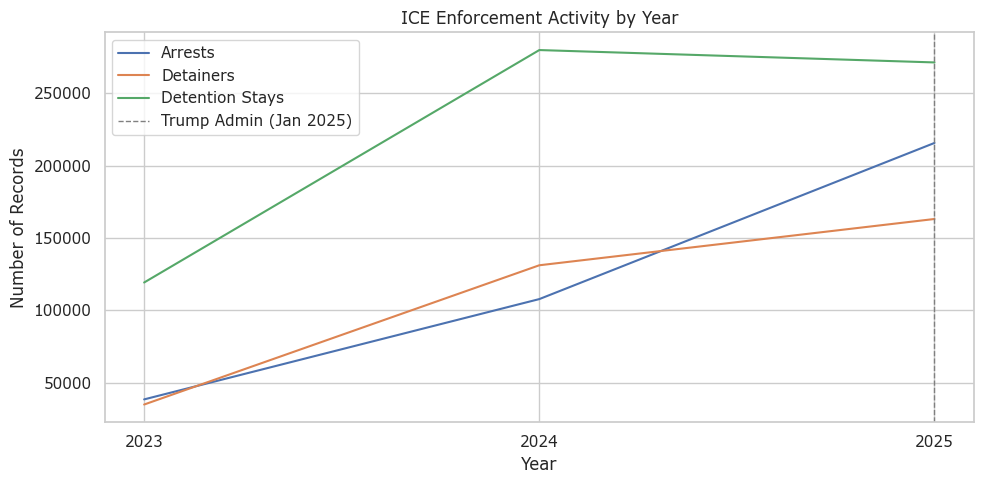

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    x=arrests_per_year.index,
    y=arrests_per_year.values,
    label='Arrests',
    ax=ax
)

sns.lineplot(
    x=detainers_per_year.index,
    y=detainers_per_year.values,
    label='Detainers',
    ax=ax
)

sns.lineplot(
    x=detentions_per_year.index,
    y=detentions_per_year.values,
    label='Detention Stays',
    ax=ax
)
# create administration change reference line
ax.axvline(x=2025, color='gray', linestyle='--', linewidth=1, label='Trump Admin (Jan 2025)')

ax.set_title('ICE Enforcement Activity by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Records')

ax.legend()
ax.set_xticks([2023, 2024, 2025])


plt.tight_layout()
plt.show()

In [7]:
# the previous chart is misleading - reworking for monthly granularity

arrests_per_month: DataFrame = df_arrests.groupby(df_arrests['apprehension_date'].dt.to_period('M')).size().reset_index(name='count')
detainers_per_month: DataFrame = df_detainers.groupby(df_detainers['detainer_prepare_date'].dt.to_period('M')).size().reset_index(name='count')
detentions_per_month: DataFrame = df_detentions.groupby(df_detentions['stay_book_in_date_time'].dt.to_period('M')).size().reset_index(name='count')

# reapply the filter for any detention records before 2023
detentions_per_month: DataFrame = detentions_per_month[detentions_per_month['stay_book_in_date_time'] >= '2023-01']

# convert back to datetime
arrests_per_month['date']: DataFrame = arrests_per_month['apprehension_date'].dt.to_timestamp()
detainers_per_month['date']: DataFrame = detainers_per_month['detainer_prepare_date'].dt.to_timestamp()
detentions_per_month['date']: DataFrame = detentions_per_month['stay_book_in_date_time'].dt.to_timestamp()

print(arrests_per_month.head())


  apprehension_date  count       date
0           2023-09  10316 2023-09-01
1           2023-10   9831 2023-10-01
2           2023-11   8747 2023-11-01
3           2023-12   9696 2023-12-01
4           2024-01   8341 2024-01-01


#### LINE CHART: Arrests Per Month (Date range not fixed)

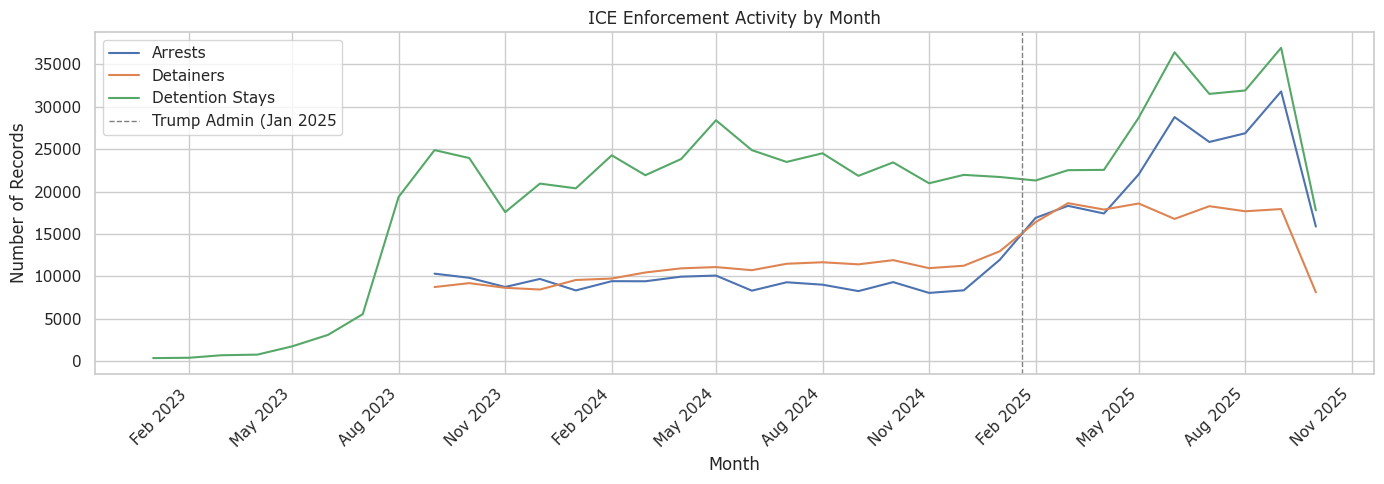

In [8]:
fig, ax = plt.subplots(figsize=(14,5))

sns.lineplot(
    data=arrests_per_month,
    x='date',
    y='count',
    label='Arrests',
    ax=ax
)

sns.lineplot(
    data=detainers_per_month,
    x='date',
    y='count',
    label='Detainers',
    ax=ax
)

sns.lineplot(
    data=detentions_per_month,
    x='date',
    y='count',
    label='Detention Stays'
)

# create administration change reference line
ax.axvline(x=pd.Timestamp('2025-01-20'), color='gray', linestyle='--', linewidth=1, label='Trump Admin (Jan 2025')

# Format x-axis as readable month/year labels
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

ax.set_title('ICE Enforcement Activity by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Records')
ax.legend()

plt.tight_layout()
plt.show()

#### LINE CHARTS: Arrests per Month (Timeframe Corrected)

In [9]:
# chart identified a discrepancy in the date range for the datasets
# running code to determine each table's date range

print(f'Arrests date range:     {df_arrests['apprehension_date'].min()} -> {df_arrests['apprehension_date'].max()}')
print(f'Detainers date range:    {df_detainers['detainer_prepare_date'].min()} -> {df_detainers['detainer_prepare_date'].max()}')
print(f'Detentions date range:    {df_detentions['stay_book_in_date_time'].min()} -> {df_detentions['stay_book_in_date_time'].max()}')
# data needs to be trimmed to maintain consistency in analysis

Arrests date range:     2023-09-01 00:00:00 -> 2025-10-16 00:00:00
Detainers date range:    2023-09-01 00:00:00 -> 2025-10-15 00:00:00
Detentions date range:    2004-12-05 22:30:00 -> 2025-10-16 00:28:00


In [10]:
# re-defining monthly data to include exactly 2 years of data

arrests_per_month: DataFrame = arrests_per_month[arrests_per_month['date'] <= '2025-09-30']
detainers_per_month: DataFrame = detainers_per_month[detainers_per_month['date'] <= '2025-09-30']
detentions_per_month: DataFrame = detentions_per_month[(detentions_per_month['date'] >= '2023-09-01') & (detentions_per_month['date'] <= '2025-09-30')]

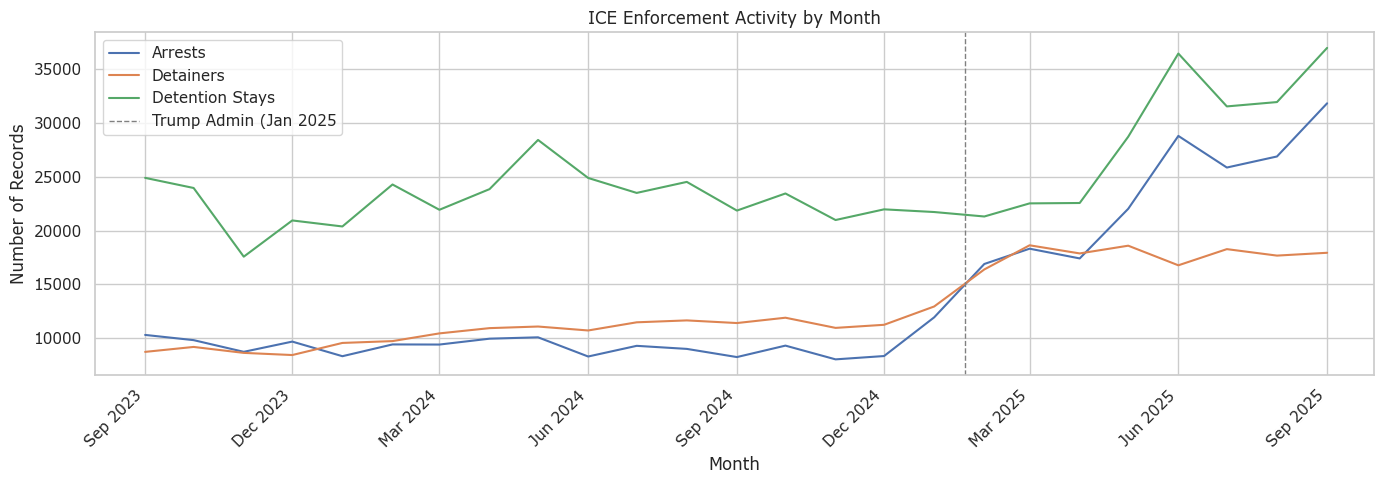

In [11]:
# re-running the chart with the updated date range

fig, ax = plt.subplots(figsize=(14,5))

sns.lineplot(
    data=arrests_per_month,
    x='date',
    y='count',
    label='Arrests',
    ax=ax
)

sns.lineplot(
    data=detainers_per_month,
    x='date',
    y='count',
    label='Detainers',
    ax=ax
)

sns.lineplot(
    data=detentions_per_month,
    x='date',
    y='count',
    label='Detention Stays'
)

# create administration change reference line
ax.axvline(x=pd.Timestamp('2025-01-20'), color='gray', linestyle='--', linewidth=1, label='Trump Admin (Jan 2025')

# Format x-axis as readable month/year labels
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[9, 12, 3, 6]))
plt.xticks(rotation=45, ha='right')
# adjusting month labels to reflect September data with a slight buffer
ax.set_xlim(pd.Timestamp('2023-08-01'), pd.Timestamp('2025-09-30'))

ax.set_title('ICE Enforcement Activity by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Records')
ax.legend()

plt.tight_layout()
plt.show()

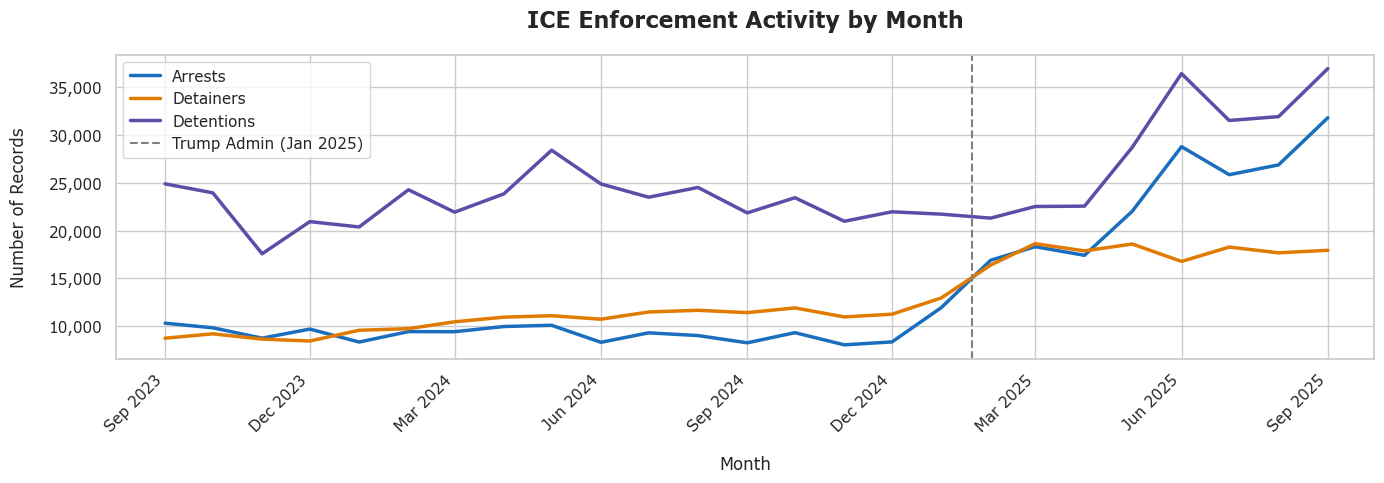

In [12]:
# adjusting formatting to make the chart 'prettier' and easier to read
# (adjusting colors to avoid red and green, thicker lines, adjusted title placement, style, and padding
# added global font formatting to the top of the file

fig, ax = plt.subplots(figsize=(14,5))

sns.lineplot(
    data=arrests_per_month,
    x='date',
    y='count',
    label='Arrests',
    color='#1A6EBD', # adjust color
    linewidth=2.5, # adjust line width
    ax=ax
)

sns.lineplot(
    data=detainers_per_month,
    x='date',
    y='count',
    label='Detainers',
    color='#E07B00',
    linewidth=2.5,
    ax=ax
)

sns.lineplot(
    data=detentions_per_month,
    x='date',
    y='count',
    label='Detentions',
    color='#5B4EA8',
    linewidth=2.5,
    ax=ax
)

# reference line at inauguration day
ax.axvline(x=pd.Timestamp('2025-01-20'), color='gray', linestyle='--', linewidth=1.5, label='Trump Admin (Jan 2025)')

# formatting x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[9, 12, 3, 6])) # manually display starting with Sept.
plt.xticks(rotation=45, ha='right')
ax.set_xlim(pd.Timestamp('2023-08-01'), pd.Timestamp('2025-09-30'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}')) # add comma to y-axis numbers  # noqa

ax.set_title('ICE Enforcement Activity by Month', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', labelpad=15)
ax.set_ylabel('Number of Records', labelpad=15)
ax.legend()

plt.tight_layout()
plt.show()

In [13]:
# setting inauguration day for reference
transition_date: Timestamp = pd.Timestamp('2025-01-20')

# splitting datasets into pre and post presidential transition
arrests_pre = arrests_per_month[arrests_per_month['date'] < transition_date]
arrests_post = arrests_per_month[arrests_per_month['date'] > transition_date]

detainers_pre = detainers_per_month[detainers_per_month['date'] < transition_date]
detainers_post = detainers_per_month[detainers_per_month['date'] > transition_date]

detentions_pre = detentions_per_month[detentions_per_month['date'] < transition_date]
detentions_post = detentions_per_month[detentions_per_month['date'] > transition_date]

# create a new summary table
summary: DataFrame = pd.DataFrame({
    'Metric' : ['Arrests', 'Detainers', 'Detentions'],
    'Average Monthly (Pre-Transition)' : [
        arrests_pre['count'].mean().round(0),
        detainers_pre['count'].mean().round(0),
        detentions_pre['count'].mean().round(0)
    ],
    'Average Monthly (Post-Transition)' : [
        arrests_post['count'].mean().round(0),
        detainers_post['count'].mean().round(0),
        detentions_post['count'].mean().round(0)
    ]
})

# calculation percentages change between pre/post
# (post - pre) / pre * 100
summary['Percentage Change'] = ((summary['Average Monthly (Post-Transition)'] - summary['Average Monthly (Pre-Transition)']) / summary['Average Monthly (Pre-Transition)'] * 100).round(1)

print(summary.to_string(index=False))

    Metric  Average Monthly (Pre-Transition)  Average Monthly (Post-Transition)  Percentage Change
   Arrests                            9319.0                            23490.0              152.1
 Detainers                           10543.0                            17768.0               68.5
Detentions                           22880.0                            28982.0               26.7


#### BAR CHART: Average ICE Activity Pre-Post Trump

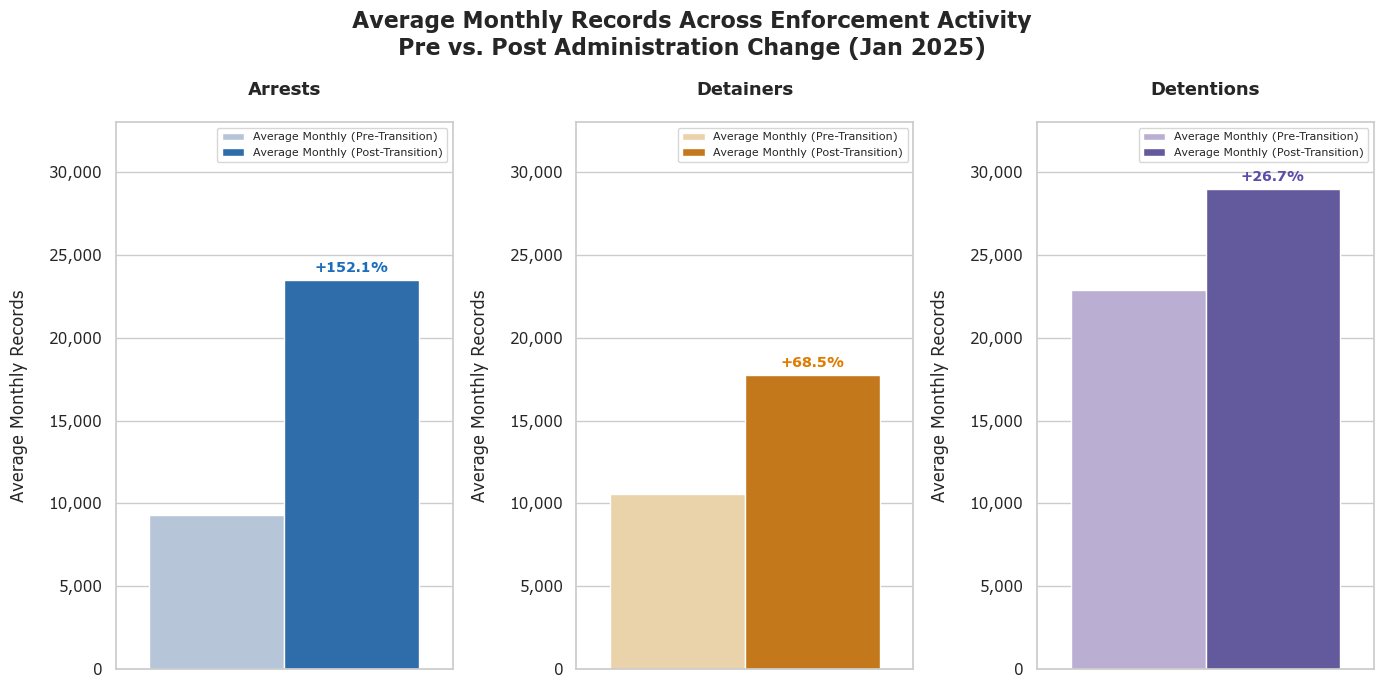

In [106]:
# filter summary_long into one DataFrame per metric
arrests_monthly: DataFrame = summary_long[summary_long['Metric'] == 'Arrests']
detainers_monthly: DataFrame = summary_long[summary_long['Metric'] == 'Detainers']
detentions_monthly: DataFrame = summary_long[summary_long['Metric'] == 'Detentions']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 7))

# arrests
sns.barplot(
    data=arrests_monthly,
    x='Metric',
    y='Average Monthly Records',
    hue='Period',
    palette=['#B0C4DE', '#1A6EBD'],
    ax=ax1
)
ax1.text(0.2, heights[0] + 300, f'+{pct_labels[0]}%', ha='center', va='bottom',
         fontsize=10, fontweight='bold', color='#1A6EBD')
ax1.set_title('Arrests',
              fontsize=13, fontweight='semibold', pad=20)
ax1.set_xlabel('', labelpad=15)
ax1.set_ylabel('Average Monthly Records', labelpad=15)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.set_ylim(0, 33000)
ax1.set_xticklabels([])
ax1.legend(fontsize=8)

# detainers
sns.barplot(
    data=detainers_monthly,
    x='Metric',
    y='Average Monthly Records',
    hue='Period',
    palette=['#F5D5A0', '#E07B00'],
    ax=ax2
)
ax2.text(0.2, heights[1] + 300, f'+{pct_labels[1]}%', ha='center', va='bottom',
         fontsize=10, fontweight='bold', color='#E07B00')
ax2.set_title('Detainers',
              fontsize=13, fontweight='semibold', pad=20)
ax2.set_xlabel('', labelpad=15)
ax2.set_ylabel('Average Monthly Records', labelpad=15)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.set_ylim(0, 33000)
ax2.set_xticklabels([])
ax2.legend(fontsize=8)

# detentions
sns.barplot(
    data=detentions_monthly,
    x='Metric',
    y='Average Monthly Records',
    hue='Period',
    palette=['#B8A9D9', '#5B4EA8'],
    ax=ax3
)
ax3.text(0.2, heights[2] + 300, f'+{pct_labels[2]}%', ha='center', va='bottom',
         fontsize=10, fontweight='bold', color='#5B4EA8')
ax3.set_title('Detentions',
              fontsize=13, fontweight='semibold', pad=20)
ax3.set_xlabel('', labelpad=15)
ax3.set_ylabel('Average Monthly Records', labelpad=15)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax3.set_ylim(0, 33000)
ax3.set_xticklabels([])
ax3.legend(fontsize=8)

plt.suptitle('Average Monthly Records Across Enforcement Activity\nPre vs. Post Administration Change (Jan 2025)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### --- GEOGRAPHIC ANALYSIS ---

#### Citizenship Countries Analysis

In [15]:
# top 10 citizenship countries for each dataset

arrests_top_countries: DataFrame = (df_arrests['citizenship_country'].value_counts().head(10))
detainers_top_countries: DataFrame = (df_detainers['citizenship_country'].value_counts().head(10))
detentions_top_countries: DataFrame = (df_detentions['citizenship_country'].value_counts().head(10))

print('ARRESTS')
print('----------')
print(arrests_top_countries)
print()
print('DETAINERS')
print('----------')
print(detainers_top_countries)
print()
print('DETENTIONS')
print('----------')
print(detentions_top_countries)

ARRESTS
----------
citizenship_country
MEXICO                137406
GUATEMALA              46926
HONDURAS               40294
VENEZUELA              21349
NICARAGUA              17796
EL SALVADOR            16701
COLOMBIA               12878
ECUADOR                12045
CUBA                    8827
DOMINICAN REPUBLIC      6144
Name: count, dtype: int64

DETAINERS
----------
citizenship_country
MEXICO                137554
GUATEMALA              38162
HONDURAS               36691
EL SALVADOR            17530
VENEZUELA              17475
COLOMBIA               11192
NICARAGUA               9701
CUBA                    7687
ECUADOR                 7582
DOMINICAN REPUBLIC      5780
Name: count, dtype: int64

DETENTIONS
----------
citizenship_country
MEXICO                195623
GUATEMALA              85907
HONDURAS               69316
VENEZUELA              46124
ECUADOR                38889
COLOMBIA               37542
EL SALVADOR            28382
NICARAGUA              20025
INDIA       

#### HORIZONTAL BAR CHART: Top 10 Citizenship Countries

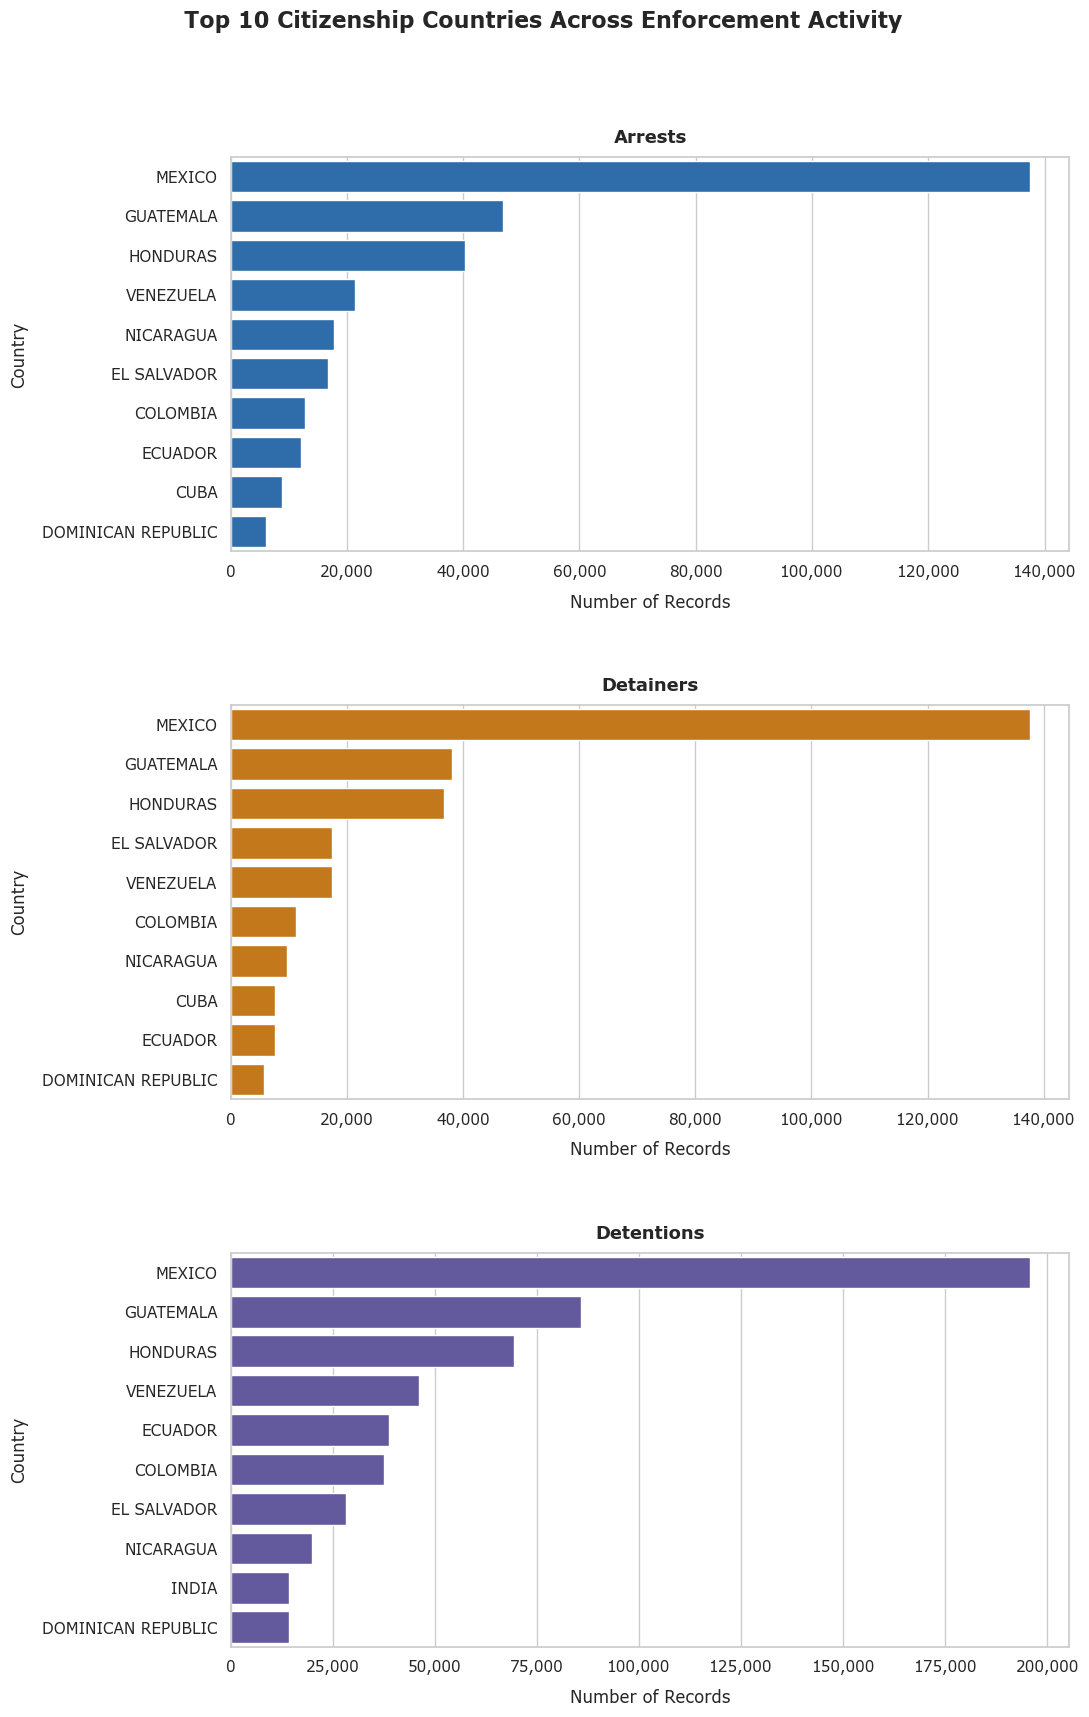

In [72]:
# creating a horizontal bar chart for each table to visualize this information

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 18))

# Arrests
sns.barplot(
    x=arrests_top_countries.values,
    y=arrests_top_countries.index,
    ax=ax1,
    color='#1A6EBD'
)

ax1.set_title('Arrests', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Number of Records', labelpad=10)
ax1.set_ylabel('Country', labelpad=10)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # noqa

# Detainers
sns.barplot(
    x=detainers_top_countries.values,
    y=detainers_top_countries.index,
    ax=ax2,
    color='#E07B00'
)

ax2.set_title('Detainers', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Number of Records', labelpad=10)
ax2.set_ylabel('Country', labelpad=10)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # noqa

# Detentions
sns.barplot(
    x=detentions_top_countries.values,
    y=detentions_top_countries.index,
    ax=ax3,
    color='#5B4EA8'
)

ax3.set_title('Detentions', fontsize=13, fontweight='bold', pad=10)
ax3.set_xlabel('Number of Records', labelpad=10)
ax3.set_ylabel('Country', labelpad=10)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # noqa

plt.suptitle('Top 10 Citizenship Countries Across Enforcement Activity', fontsize=16, fontweight='bold')
plt.tight_layout(pad=4.0)
plt.show()

#### MAP CHART: Records Volume by State

In [17]:
# understanding volume of records by state
# try to identify state column in the detentions table
print(df_detentions.columns.tolist())
print(df_detentions['detention_facility_code_first'].value_counts().head(20))
# unable to find usable column - will continue analysis on arrests and detainers only

['stay_ID', 'n_stints', 'stay_book_in_date_time', 'stay_book_out_date_time', 'detention_release_reason', 'stay_release_reason', 'gender', 'marital_status', 'birth_year', 'ethnicity', 'entry_status', 'felon', 'bond_posted_date', 'bond_posted_amount', 'case_status', 'case_category', 'final_order_yes_no', 'final_order_date', 'case_threat_level', 'book_in_criminality', 'final_charge', 'departed_date', 'departure_country', 'initial_bond_set_amount', 'citizenship_country', 'final_program', 'most_serious_conviction_code', 'msc_charge', 'unique_identifier', 'n_stays', 'detention_facility_first', 'detention_facility_code_first', 'book_out_date_time_first', 'detention_facility_longest', 'detention_facility_code_longest', 'book_in_date_time_longest', 'book_out_date_time_longest', 'detention_facility_last', 'detention_facility_code_last', 'book_in_date_time_last', 'book_out_date_time_last', 'criminality_clean', 'detention_length_days', 'age', 'stay_year', 'stay_month']
detention_facility_code_firs

In [18]:
# top states
arrests_per_state: DataFrame = df_arrests['apprehension_state'].value_counts()
detainers_per_state: DataFrame = df_detainers['facility_state'].value_counts()

with pd.option_context('display.max_rows', None):
    print('ARRESTS')
    print('----------')
    print(arrests_per_state)
    print()
    print('DETAINERS')
    print('----------')
    print(detainers_per_state)

ARRESTS
----------
apprehension_state
TEXAS                             76431
FLORIDA                           29708
CALIFORNIA                        24811
NEW YORK                          13749
GEORGIA                           10918
NEW JERSEY                         9268
TENNESSEE                          8665
VIRGINIA                           8577
ARIZONA                            8372
LOUISIANA                          6766
PENNSYLVANIA                       6444
MASSACHUSETTS                      6311
ALABAMA                            5647
OKLAHOMA                           5460
ILLINOIS                           5317
NORTH CAROLINA                     5282
INDIANA                            5030
MARYLAND                           4901
SOUTH CAROLINA                     4672
COLORADO                           4663
UTAH                               4424
KENTUCKY                           4298
ARKANSAS                           3860
OHIO                               3695
MI

In [19]:
# converting state names to abbreviations for use in plotly
# this was copy/pasted to save time
state_abbreviations: dict = {
    'ALABAMA': 'AL', 'ALASKA': 'AK', 'ARIZONA': 'AZ', 'ARKANSAS': 'AR',
    'CALIFORNIA': 'CA', 'COLORADO': 'CO', 'CONNECTICUT': 'CT', 'DELAWARE': 'DE',
    'FLORIDA': 'FL', 'GEORGIA': 'GA', 'HAWAII': 'HI', 'IDAHO': 'ID',
    'ILLINOIS': 'IL', 'INDIANA': 'IN', 'IOWA': 'IA', 'KANSAS': 'KS',
    'KENTUCKY': 'KY', 'LOUISIANA': 'LA', 'MAINE': 'ME', 'MARYLAND': 'MD',
    'MASSACHUSETTS': 'MA', 'MICHIGAN': 'MI', 'MINNESOTA': 'MN', 'MISSISSIPPI': 'MS',
    'MISSOURI': 'MO', 'MONTANA': 'MT', 'NEBRASKA': 'NE', 'NEVADA': 'NV',
    'NEW HAMPSHIRE': 'NH', 'NEW JERSEY': 'NJ', 'NEW MEXICO': 'NM', 'NEW YORK': 'NY',
    'NORTH CAROLINA': 'NC', 'NORTH DAKOTA': 'ND', 'OHIO': 'OH', 'OKLAHOMA': 'OK',
    'OREGON': 'OR', 'PENNSYLVANIA': 'PA', 'RHODE ISLAND': 'RI', 'SOUTH CAROLINA': 'SC',
    'SOUTH DAKOTA': 'SD', 'TENNESSEE': 'TN', 'TEXAS': 'TX', 'UTAH': 'UT',
    'VERMONT': 'VT', 'VIRGINIA': 'VA', 'WASHINGTON': 'WA', 'WEST VIRGINIA': 'WV',
    'WISCONSIN': 'WI', 'WYOMING': 'WY', 'DISTRICT OF COLUMBIA': 'DC'
}

# need to filter to show only US states (remove territories, armed forces, and foreign locations)
arrests_per_state: DataFrame = (df_arrests[df_arrests['apprehension_state']
                    .isin(state_abbreviations)]
                    ['apprehension_state']
                    .map(state_abbreviations)
                     .value_counts())

detainers_per_state: DataFrame = (df_detainers[df_detainers['facility_state']
                      .isin(state_abbreviations)]
                      ['facility_state']
                      .map(state_abbreviations)
                      .value_counts())

print('ARRESTS')
print(arrests_per_state.head())
print()
print('DETAINERS')
print(detainers_per_state.head())

ARRESTS
apprehension_state
TX    76431
FL    29708
CA    24811
NY    13749
GA    10918
Name: count, dtype: int64

DETAINERS
facility_state
TX    62178
CA    61387
FL    29767
NY    14536
GA    13518
Name: count, dtype: int64


In [20]:
# create two maps, one for arrests and one for detainers
# this plot was created with the assistance of claude

# need to conver the series to a dataframe for plotly
df_arrests_state = arrests_per_state.reset_index()
df_arrests_state.columns = ['state', 'count']

df_detainers_state = detainers_per_state.reset_index()
df_detainers_state.columns = ['state', 'count']

# arrests map

fig_arrests = px.choropleth(
    df_arrests_state,
    locations='state',
    locationmode='USA-states',
    color='count',
    scope='usa',
    color_continuous_scale='Purples',
    title='ICE Arrests by State (Sep 2023 - Sep 2025)',
)

fig_arrests.update_layout(
    paper_bgcolor='white',
    geo_bgcolor='white',
    title_font_color='black',
    title_font_weight='bold',
    coloraxis_colorbar_tickfont=dict(color='black')
)

fig_arrests.update_geos(
    showlakes=False,
    showrivers=False,
    showcoastlines=True,
    coastlinecolor='#5b5b5b'
)

fig_arrests.show()

fig_detainers = px.choropleth(
    df_detainers_state,
    locations='state',
    locationmode='USA-states',
    color='count',
    scope='usa',
    color_continuous_scale='Oranges',
    title='ICE Detainers by State (Sep 2023 - Sep 2025)'
)
fig_detainers.update_layout(
    paper_bgcolor='white',
    geo_bgcolor='white',
    title_font_color='black',
    title_font_weight='bold',
    coloraxis_colorbar_tickfont=dict(color='black')
)

fig_detainers.update_geos(
    showlakes=False,
    showrivers=False,
    showcoastlines=True,
    coastlinecolor='#5b5b5b'
)

fig_detainers.show()

##### map export

In [21]:
# export maps as .png and .html

# fig_arrests.write_image('/Users/leahmayotte/Documents/education/umass/capstone/4_visualizations/ice_arrests_by_state.png')
# fig_detainers.write_image('/Users/leahmayotte/Documents/education/umass/capstone/4_visualizations/ice_detainers_by_state.png')
#
# fig_arrests.write_html('/Users/leahmayotte/Documents/education/umass/capstone/4_visualizations/ice_arrests_by_state.html')
# fig_detainers.write_html('/Users/leahmayotte/Documents/education/umass/capstone/4_visualizations/ice_detainers_by_state.html')

#### MAP CHART: Arrests Pre-Post Trump

In [22]:
# create additional maps for arrests only that demonstrate changes pre-post Trump

from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Filter arrests by pre-post transition and valid states
arrests_pre_state = (df_arrests[
    (df_arrests['apprehension_date'] >= '2023-09-01') &
    (df_arrests['apprehension_date'] < '2025-01-20') &
    (df_arrests['apprehension_state'].isin(state_abbreviations))
]['apprehension_state']
.map(state_abbreviations)
.value_counts()
.reset_index())
arrests_pre_state.columns = ['state', 'count']

arrests_post_state = (df_arrests[
    (df_arrests['apprehension_date'] >= '2025-01-20') &
    (df_arrests['apprehension_date'] <= '2025-09-30') &
    (df_arrests['apprehension_state'].isin(state_abbreviations))
]['apprehension_state']
.map(state_abbreviations)
.value_counts()
.reset_index())
arrests_post_state.columns = ['state', 'count']

# Shared color scale maximum across both maps
max_val = max(arrests_pre_state['count'].max(), arrests_post_state['count'].max())

# Create side-by-side subplots
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['Pre-Transition (Sep 2023 - Jan 2025)', 'Post-Transition (Jan 2025 - Sep 2025)'],
    specs=[[{'type': 'choropleth'}], [{'type': 'choropleth'}]]
)

# Pre-transition map (no colorbar — shared with post)
fig.add_trace(
    go.Choropleth(
        locations=arrests_pre_state['state'],
        z=arrests_pre_state['count'],
        locationmode='USA-states',
        colorscale='Blues',
        zmin=0,
        zmax=max_val,
        showscale=False,
        name='Pre-Transition',
        hovertemplate='<b>%{location}</b><br>Arrests: %{z:,.0f}<extra></extra>'
    ),
    row=1, col=1
)

# Post-transition map (shows the shared colorbar)
fig.add_trace(
    go.Choropleth(
        locations=arrests_post_state['state'],
        z=arrests_post_state['count'],
        locationmode='USA-states',
        colorscale='Blues',
        zmin=0,
        zmax=max_val,
        name='Post-Transition',
        hovertemplate='<b>%{location}</b><br>Arrests: %{z:,.0f}<extra></extra>',
        colorbar=dict(
            tickfont=dict(color='black'),
            title=dict(text='Count', font=dict(color='black'))
        )
    ),
    row=2, col=1
)

fig.update_layout(
    title_text='ICE Arrests by State: Pre vs. Post Administration Change (Jan 2025)',
    title_font_color='black',
    paper_bgcolor='white',
    height=800,
    geo=dict(scope='usa', showlakes=False, showrivers=False,
             showcoastlines=True, coastlinecolor='gray', bgcolor='white'),
    geo2=dict(scope='usa', showlakes=False, showrivers=False,
              showcoastlines=True, coastlinecolor='gray', bgcolor='white')
)

fig.update_annotations(font=dict(color='black'))

fig.show()


##### Export Maps

In [23]:
# # export maps as .png and .html
# fig.write_image('/Users/leahmayotte/Documents/education/umass/capstone/4_visualizations/ice_arrests_by_state_pre_post.png')
# fig.write_html('/Users/leahmayotte/Documents/education/umass/capstone/4_visualizations/ice_arrests_by_state_pre_post.html')

#### HORIZONTAL BAR CHART: Percentage Change in Arrests by State Pre-Post Trump

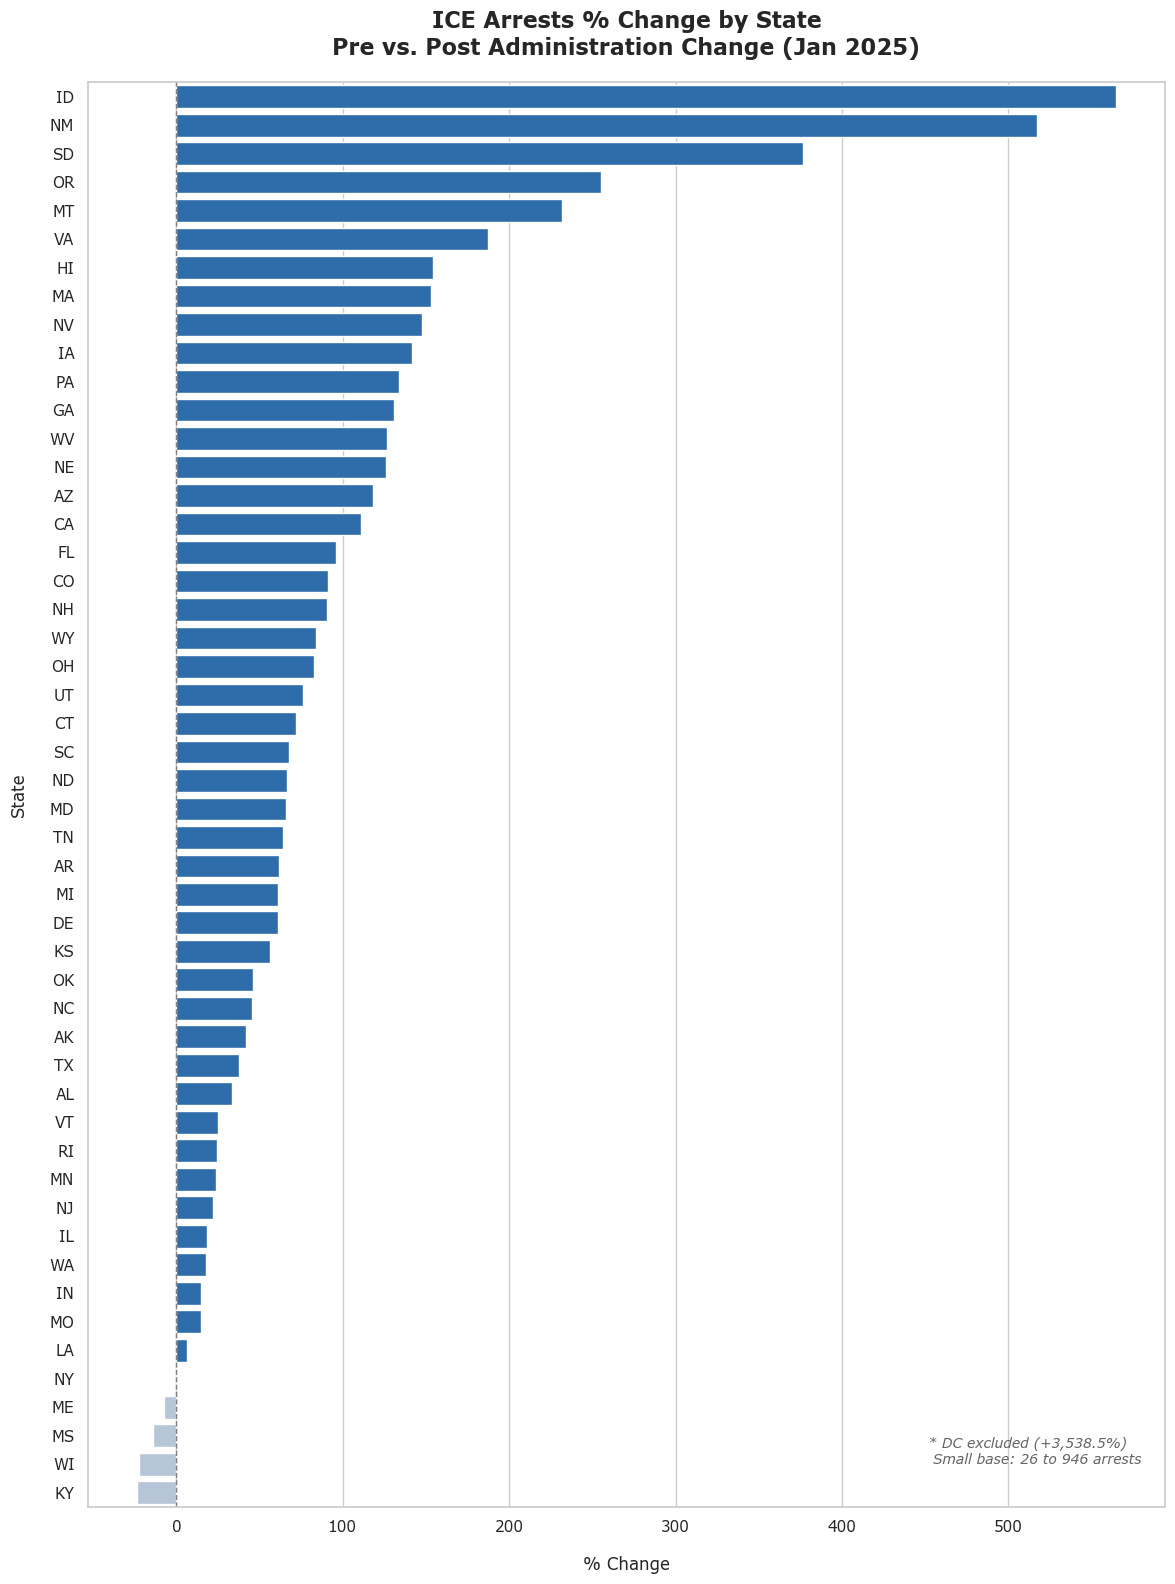

In [24]:
# create a bar chart to show the percentage changes in arrests by state pre-post Trump

# convert state_comparison with numeric values for plotting
state_comparison_plot = arrests_pre_state.merge(
    arrests_post_state,
    on='state',
    suffixes=('_pre', '_post')
)
state_comparison_plot.columns = ['State', 'Pre-Transition', 'Post-Transition']
state_comparison_plot['% Change'] = ((state_comparison_plot['Post-Transition'] - state_comparison_plot['Pre-Transition']) / state_comparison_plot['Pre-Transition'] * 100).round(1)
state_comparison_plot = state_comparison_plot.sort_values('% Change', ascending=False)

# create the chart
state_comparison_plot_filtered = state_comparison_plot[state_comparison_plot['State'] != 'DC']

fig, ax = plt.subplots(figsize=(12, 16))

sns.barplot(
    data=state_comparison_plot_filtered,
    x='% Change',
    y='State',
    hue='State',
    palette=['#1A6EBD' if x >= 0 else '#B0C4DE' for x in state_comparison_plot_filtered['% Change']],
    ax=ax
)

ax.axvline(x=0, color='gray', linewidth=1, linestyle='--')
ax.set_title('ICE Arrests % Change by State\nPre vs. Post Administration Change (Jan 2025)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('% Change', labelpad=15)
ax.set_ylabel('State', labelpad=15)

# Note DC separately
ax.annotate('* DC excluded (+3,538.5%)\n Small base: 26 to 946 arrests',
            xy=(0.78, 0.03), xycoords='axes fraction',
            fontsize=10, fontstyle='italic', color='#636363')

plt.tight_layout()
plt.show()

### --- AGE ANALYSIS ---

#### Age Distribution Analysis

In [25]:
# count records in various age brackets for the arrests table
print(f'-------ARRESTS-------\n Age Bracket Details')
age_arrests_1_10 = df_arrests[(df_arrests['age'] >= 1) & (df_arrests['age'] <= 10)]
age_pct_1_10 = len(age_arrests_1_10) / len(df_arrests) * 100
print(f'Arrests ages 1-10: {len(age_arrests_1_10):,}')
print(f'Percentage of total records: {age_pct_1_10:.2f}%')
print()
age_arrests_11_18 = df_arrests[(df_arrests['age'] >= 11) & (df_arrests['age'] <= 18)]
age_pct_11_18 = len(age_arrests_11_18) / len(df_arrests) * 100
print(f'Arrests ages 11-18: {len(age_arrests_11_18):,}')
print(f'Percentage of total records: {age_pct_11_18:.2f}%')
print()
age_arrests_19_30 = df_arrests[(df_arrests['age'] >= 19) & (df_arrests['age'] <= 30)]
age_pct_19_30 = len(age_arrests_19_30) / len(df_arrests) * 100
print(f'Arrests ages 19-30: {len(age_arrests_19_30):,}')
print(f'Percentage of total records: {age_pct_19_30:.2f}%')
print()
age_arrests_31_40 = df_arrests[(df_arrests['age'] >= 31) & (df_arrests['age'] <= 40)]
age_pct_31_40 = len(age_arrests_31_40) / len(df_arrests) * 100
print(f'Arrests ages 31-40: {len(age_arrests_31_40):,}')
print(f'Percentage of total records: {age_pct_31_40:.2f}%')
print()
age_arrests_41_50 = df_arrests[(df_arrests['age'] >= 41) & (df_arrests['age'] <= 50)]
age_pct_41_50 = len(age_arrests_41_50) / len(df_arrests) * 100
print(f'Arrests ages 41-50: {len(age_arrests_41_50):,}')
print(f'Percentage of total records: {age_pct_41_50:.2f}%')
print()
age_arrests_51_60 = df_arrests[(df_arrests['age'] >= 51) & (df_arrests['age'] <= 60)]
age_pct_51_60 = len(age_arrests_51_60) / len(df_arrests) * 100
print(f'Arrests ages 51-60: {len(age_arrests_51_60):,}')
print(f'Percentage of total records: {age_pct_51_60:.2f}%')
print()
age_arrests_61_70 = df_arrests[(df_arrests['age'] >= 61) & (df_arrests['age'] <= 70)]
age_pct_61_70 = len(age_arrests_61_70) / len(df_arrests) * 100
print(f'Arrests ages 61-70: {len(age_arrests_61_70):,}')
print(f'Percentage of total records: {age_pct_61_70:.2f}%')
print()
age_arrests_71_80 = df_arrests[(df_arrests['age'] >= 71) & (df_arrests['age'] <= 80)]
age_pct_71_80 = len(age_arrests_71_80) / len(df_arrests) * 100
print(f'Arrests ages 71-80: {len(age_arrests_71_80):,}')
print(f'Percentage of total records: {age_pct_71_80:.2f}%')
print()
age_arrests_81_90 = df_arrests[(df_arrests['age'] >= 81) & (df_arrests['age'] <= 90)]
age_pct_81_90 = len(age_arrests_81_90) / len(df_arrests) * 100
print(f'Arrests ages 81-90: {len(age_arrests_81_90):,}')
print(f'Percentage of total records: {age_pct_81_90:.2f}%')
print()
age_arrests_91_100 = df_arrests[(df_arrests['age'] >= 91) & (df_arrests['age'] <= 100)]
age_pct_91_100 = len(age_arrests_91_100) / len(df_arrests) * 100
print(f'Arrests ages 91-100: {len(age_arrests_91_100):,}')
print(f'Percentage of total records: {age_pct_91_100:.2f}%')
print()
age_arrests_over_100 = df_arrests[df_arrests['age'] > 100]
age_pct_over_100 = len(age_arrests_over_100) / len(df_arrests) * 100
print(f'Arrests ages over 100: {len(age_arrests_over_100):,}')
print(f'Percentage of total records: {age_pct_over_100:.2f}%')


-------ARRESTS-------
 Age Bracket Details
Arrests ages 1-10: 4,152
Percentage of total records: 1.15%

Arrests ages 11-18: 5,109
Percentage of total records: 1.41%

Arrests ages 19-30: 112,910
Percentage of total records: 31.17%

Arrests ages 31-40: 123,132
Percentage of total records: 34.00%

Arrests ages 41-50: 79,431
Percentage of total records: 21.93%

Arrests ages 51-60: 29,846
Percentage of total records: 8.24%

Arrests ages 61-70: 6,711
Percentage of total records: 1.85%

Arrests ages 71-80: 859
Percentage of total records: 0.24%

Arrests ages 81-90: 49
Percentage of total records: 0.01%

Arrests ages 91-100: 2
Percentage of total records: 0.00%

Arrests ages over 100: 0
Percentage of total records: 0.00%


In [26]:
# doing the same calculations for detainers
print(f'-------DETAINERS-------\n Age Bracket Details')
age_detainers_1_10 = df_detainers[(df_detainers['age'] >= 1) & (df_detainers['age'] <= 10)]
age_pct_detainers_1_10 = len(age_detainers_1_10) / len(df_detainers) * 100
print(f'Detainers ages 1-10: {len(age_detainers_1_10):,}')
print(f'Percentage of total records: {age_pct_detainers_1_10:.2f}%')
print()
age_detainers_11_18 = df_detainers[(df_detainers['age'] >= 11) & (df_detainers['age'] <= 18)]
age_pct_detainers_11_18 = len(age_detainers_11_18) / len(df_detainers) * 100
print(f'Detainers ages 11-18: {len(age_detainers_11_18):,}')
print(f'Percentage of total records: {age_pct_detainers_11_18:.2f}%')
print()
age_detainers_19_30 = df_detainers[(df_detainers['age'] >= 19) & (df_detainers['age'] <= 30)]
age_pct_detainers_19_30 = len(age_detainers_19_30) / len(df_detainers) * 100
print(f'Detainers ages 19-30: {len(age_detainers_19_30):,}')
print(f'Percentage of total records: {age_pct_detainers_19_30:.2f}%')
print()
age_detainers_31_40 = df_detainers[(df_detainers['age'] >= 31) & (df_detainers['age'] <= 40)]
age_pct_detainers_31_40 = len(age_detainers_31_40) / len(df_detainers) * 100
print(f'Detainers ages 31-40: {len(age_detainers_31_40):,}')
print(f'Percentage of total records: {age_pct_detainers_31_40:.2f}%')
print()
age_detainers_41_50 = df_detainers[(df_detainers['age'] >= 41) & (df_detainers['age'] <= 50)]
age_pct_detainers_41_50 = len(age_detainers_41_50) / len(df_detainers) * 100
print(f'Detainers ages 41-50: {len(age_detainers_41_50):,}')
print(f'Percentage of total records: {age_pct_detainers_41_50:.2f}%')
print()
age_detainers_51_60 = df_detainers[(df_detainers['age'] >= 51) & (df_detainers['age'] <= 60)]
age_pct_detainers_51_60 = len(age_detainers_51_60) / len(df_detainers) * 100
print(f'Detainers ages 51-60: {len(age_detainers_51_60):,}')
print(f'Percentage of total records: {age_pct_detainers_51_60:.2f}%')
print()
age_detainers_61_70 = df_detainers[(df_detainers['age'] >= 61) & (df_detainers['age'] <= 70)]
age_pct_detainers_61_70 = len(age_detainers_61_70) / len(df_detainers) * 100
print(f'Detainers ages 61-70: {len(age_detainers_61_70):,}')
print(f'Percentage of total records: {age_pct_detainers_61_70:.2f}%')
print()
age_detainers_71_80 = df_detainers[(df_detainers['age'] >= 71) & (df_detainers['age'] <= 80)]
age_pct_detainers_71_80 = len(age_detainers_71_80) / len(df_detainers) * 100
print(f'Detainers ages 71-80: {len(age_detainers_71_80):,}')
print(f'Percentage of total records: {age_pct_detainers_71_80:.2f}%')
print()
age_detainers_81_90 = df_detainers[(df_detainers['age'] >= 81) & (df_detainers['age'] <= 90)]
age_pct_detainers_81_90 = len(age_detainers_81_90) / len(df_detainers) * 100
print(f'Detainers ages 81-90: {len(age_detainers_81_90):,}')
print(f'Percentage of total records: {age_pct_detainers_81_90:.2f}%')
print()
age_detainers_91_100 = df_detainers[(df_detainers['age'] >= 91) & (df_detainers['age'] <= 100)]
age_pct_detainers_91_100 = len(age_detainers_91_100) / len(df_detainers) * 100
print(f'Detainers ages 91-100: {len(age_detainers_91_100):,}')
print(f'Percentage of total records: {age_pct_detainers_91_100:.2f}%')
print()
age_detainers_over_100 = df_detainers[df_detainers['age'] > 100]
age_pct_detainers_over_100 = len(age_detainers_over_100) / len(df_detainers) * 100
print(f'Detainers ages over 100: {len(age_detainers_over_100):,}')
print(f'Percentage of total records: {age_pct_detainers_over_100:.2f}%')

-------DETAINERS-------
 Age Bracket Details
Detainers ages 1-10: 2
Percentage of total records: 0.00%

Detainers ages 11-18: 391
Percentage of total records: 0.12%

Detainers ages 19-30: 106,255
Percentage of total records: 32.25%

Detainers ages 31-40: 118,157
Percentage of total records: 35.86%

Detainers ages 41-50: 72,669
Percentage of total records: 22.06%

Detainers ages 51-60: 25,555
Percentage of total records: 7.76%

Detainers ages 61-70: 5,641
Percentage of total records: 1.71%

Detainers ages 71-80: 757
Percentage of total records: 0.23%

Detainers ages 81-90: 41
Percentage of total records: 0.01%

Detainers ages 91-100: 2
Percentage of total records: 0.00%

Detainers ages over 100: 3
Percentage of total records: 0.00%


In [27]:
# doing the same for detentions

# Detentions
print(f'-------DETENTIONS-------\n Age Bracket Details')
age_detentions_1_10 = df_detentions[(df_detentions['age'] >= 1) & (df_detentions['age'] <= 10)]
age_pct_detentions_1_10 = len(age_detentions_1_10) / len(df_detentions) * 100
print(f'Detentions ages 1-10: {len(age_detentions_1_10):,}')
print(f'Percentage of total records: {age_pct_detentions_1_10:.2f}%')
print()
age_detentions_11_18 = df_detentions[(df_detentions['age'] >= 11) & (df_detentions['age'] <= 18)]
age_pct_detentions_11_18 = len(age_detentions_11_18) / len(df_detentions) * 100
print(f'Detentions ages 11-18: {len(age_detentions_11_18):,}')
print(f'Percentage of total records: {age_pct_detentions_11_18:.2f}%')
print()
age_detentions_19_30 = df_detentions[(df_detentions['age'] >= 19) & (df_detentions['age'] <= 30)]
age_pct_detentions_19_30 = len(age_detentions_19_30) / len(df_detentions) * 100
print(f'Detentions ages 19-30: {len(age_detentions_19_30):,}')
print(f'Percentage of total records: {age_pct_detentions_19_30:.2f}%')
print()
age_detentions_31_40 = df_detentions[(df_detentions['age'] >= 31) & (df_detentions['age'] <= 40)]
age_pct_detentions_31_40 = len(age_detentions_31_40) / len(df_detentions) * 100
print(f'Detentions ages 31-40: {len(age_detentions_31_40):,}')
print(f'Percentage of total records: {age_pct_detentions_31_40:.2f}%')
print()
age_detentions_41_50 = df_detentions[(df_detentions['age'] >= 41) & (df_detentions['age'] <= 50)]
age_pct_detentions_41_50 = len(age_detentions_41_50) / len(df_detentions) * 100
print(f'Detentions ages 41-50: {len(age_detentions_41_50):,}')
print(f'Percentage of total records: {age_pct_detentions_41_50:.2f}%')
print()
age_detentions_51_60 = df_detentions[(df_detentions['age'] >= 51) & (df_detentions['age'] <= 60)]
age_pct_detentions_51_60 = len(age_detentions_51_60) / len(df_detentions) * 100
print(f'Detentions ages 51-60: {len(age_detentions_51_60):,}')
print(f'Percentage of total records: {age_pct_detentions_51_60:.2f}%')
print()
age_detentions_61_70 = df_detentions[(df_detentions['age'] >= 61) & (df_detentions['age'] <= 70)]
age_pct_detentions_61_70 = len(age_detentions_61_70) / len(df_detentions) * 100
print(f'Detentions ages 61-70: {len(age_detentions_61_70):,}')
print(f'Percentage of total records: {age_pct_detentions_61_70:.2f}%')
print()
age_detentions_71_80 = df_detentions[(df_detentions['age'] >= 71) & (df_detentions['age'] <= 80)]
age_pct_detentions_71_80 = len(age_detentions_71_80) / len(df_detentions) * 100
print(f'Detentions ages 71-80: {len(age_detentions_71_80):,}')
print(f'Percentage of total records: {age_pct_detentions_71_80:.2f}%')
print()
age_detentions_81_90 = df_detentions[(df_detentions['age'] >= 81) & (df_detentions['age'] <= 90)]
age_pct_detentions_81_90 = len(age_detentions_81_90) / len(df_detentions) * 100
print(f'Detentions ages 81-90: {len(age_detentions_81_90):,}')
print(f'Percentage of total records: {age_pct_detentions_81_90:.2f}%')
print()
age_detentions_91_100 = df_detentions[(df_detentions['age'] >= 91) & (df_detentions['age'] <= 100)]
age_pct_detentions_91_100 = len(age_detentions_91_100) / len(df_detentions) * 100
print(f'Detentions ages 91-100: {len(age_detentions_91_100):,}')
print(f'Percentage of total records: {age_pct_detentions_91_100:.2f}%')
print()
age_detentions_over_100 = df_detentions[df_detentions['age'] > 100]
age_pct_detentions_over_100 = len(age_detentions_over_100) / len(df_detentions) * 100
print(f'Detentions ages over 100: {len(age_detentions_over_100):,}')
print(f'Percentage of total records: {age_pct_detentions_over_100:.2f}%')


-------DETENTIONS-------
 Age Bracket Details
Detentions ages 1-10: 5,338
Percentage of total records: 0.79%

Detentions ages 11-18: 6,369
Percentage of total records: 0.95%

Detentions ages 19-30: 247,821
Percentage of total records: 36.89%

Detentions ages 31-40: 221,463
Percentage of total records: 32.97%

Detentions ages 41-50: 130,631
Percentage of total records: 19.45%

Detentions ages 51-60: 48,540
Percentage of total records: 7.23%

Detentions ages 61-70: 10,437
Percentage of total records: 1.55%

Detentions ages 71-80: 1,089
Percentage of total records: 0.16%

Detentions ages 81-90: 59
Percentage of total records: 0.01%

Detentions ages 91-100: 3
Percentage of total records: 0.00%

Detentions ages over 100: 0
Percentage of total records: 0.00%


#### PIE CHART: Age Distributions Across Enforcement Activity (Not Used)

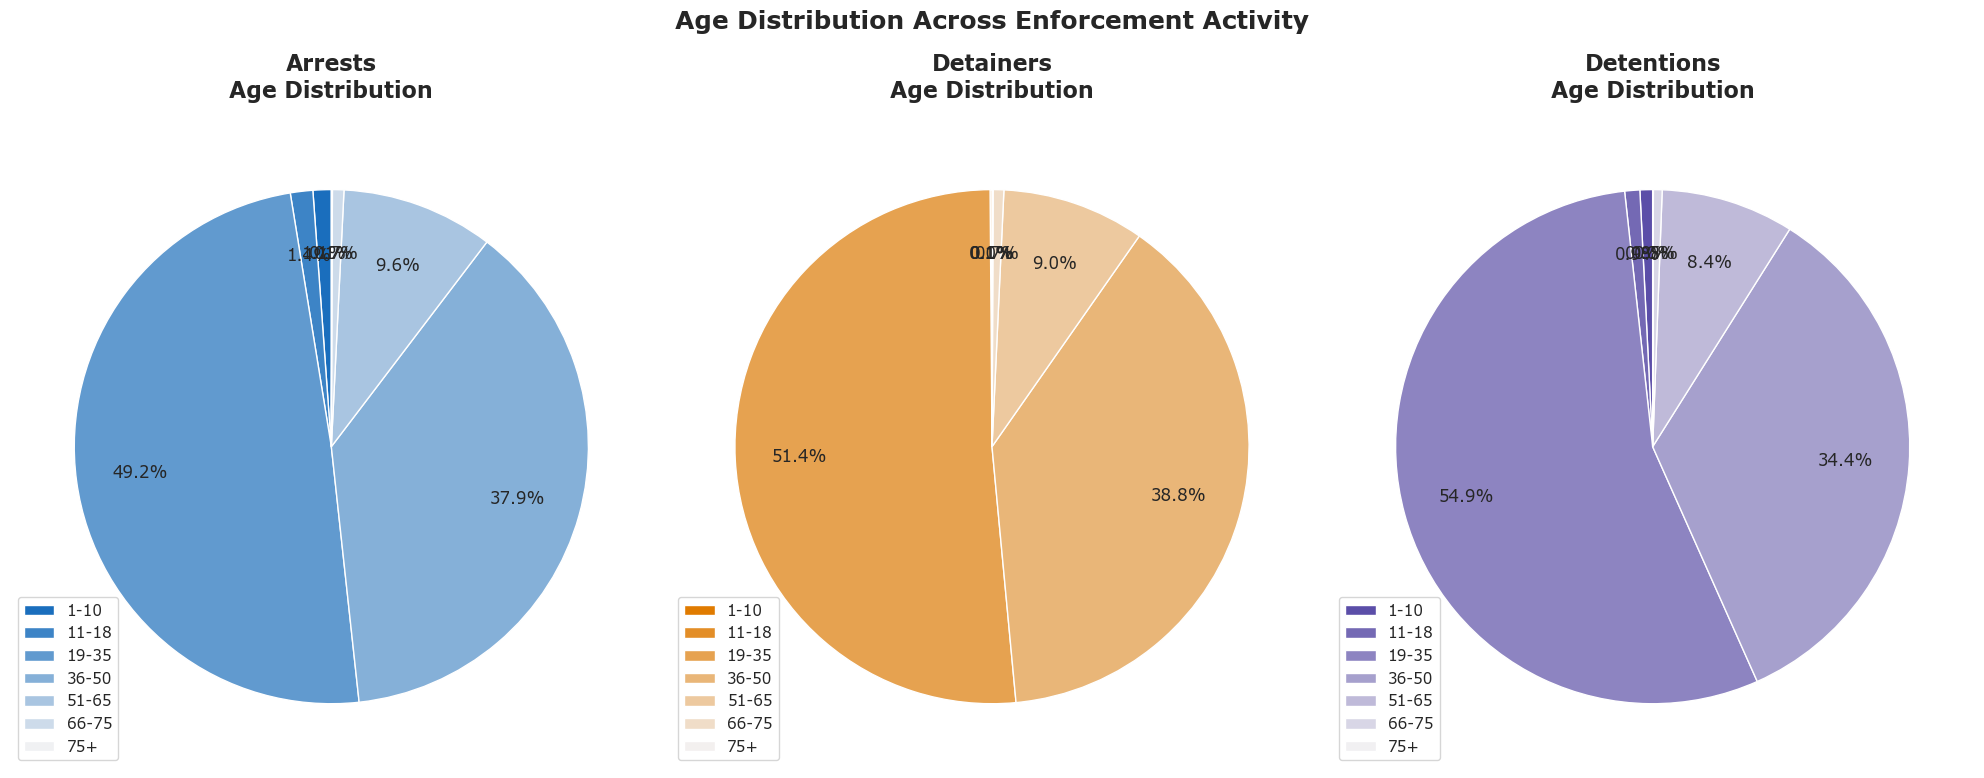

In [28]:
# create a pie chart to demonstrate age brackets

# define age buckets for chart
# Arrests
arrests_pie_1_10 = len(df_arrests[(df_arrests['age'] >= 1) & (df_arrests['age'] <= 10)])
arrests_pie_11_18 = len(df_arrests[(df_arrests['age'] >= 11) & (df_arrests['age'] <= 18)])
arrests_pie_19_35 = len(df_arrests[(df_arrests['age'] >= 19) & (df_arrests['age'] <= 35)])
arrests_pie_36_50 = len(df_arrests[(df_arrests['age'] >= 36) & (df_arrests['age'] <= 50)])
arrests_pie_51_65 = len(df_arrests[(df_arrests['age'] >= 51) & (df_arrests['age'] <= 65)])
arrests_pie_66_75 = len(df_arrests[(df_arrests['age'] >= 66) & (df_arrests['age'] <= 75)])
arrests_pie_75_plus = len(df_arrests[df_arrests['age'] > 75])

# Detainers
detainers_pie_1_10 = len(df_detainers[(df_detainers['age'] >= 1) & (df_detainers['age'] <= 10)])
detainers_pie_11_18 = len(df_detainers[(df_detainers['age'] >= 11) & (df_detainers['age'] <= 18)])
detainers_pie_19_35 = len(df_detainers[(df_detainers['age'] >= 19) & (df_detainers['age'] <= 35)])
detainers_pie_36_50 = len(df_detainers[(df_detainers['age'] >= 36) & (df_detainers['age'] <= 50)])
detainers_pie_51_65 = len(df_detainers[(df_detainers['age'] >= 51) & (df_detainers['age'] <= 65)])
detainers_pie_66_75 = len(df_detainers[(df_detainers['age'] >= 66) & (df_detainers['age'] <= 75)])
detainers_pie_75_plus = len(df_detainers[df_detainers['age'] > 75])

# Detentions
detentions_pie_1_10 = len(df_detentions[(df_detentions['age'] >= 1) & (df_detentions['age'] <= 10)])
detentions_pie_11_18 = len(df_detentions[(df_detentions['age'] >= 11) & (df_detentions['age'] <= 18)])
detentions_pie_19_35 = len(df_detentions[(df_detentions['age'] >= 19) & (df_detentions['age'] <= 35)])
detentions_pie_36_50 = len(df_detentions[(df_detentions['age'] >= 36) & (df_detentions['age'] <= 50)])
detentions_pie_51_65 = len(df_detentions[(df_detentions['age'] >= 51) & (df_detentions['age'] <= 65)])
detentions_pie_66_75 = len(df_detentions[(df_detentions['age'] >= 66) & (df_detentions['age'] <= 75)])
detentions_pie_75_plus = len(df_detentions[df_detentions['age'] > 75])

# create the chart
age_pie_labels: list[str] = ['1-10', '11-18', '19-35', '36-50', '51-65', '66-75', '75+']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8))

ax1.pie(
    [arrests_pie_1_10, arrests_pie_11_18, arrests_pie_19_35, arrests_pie_36_50, arrests_pie_51_65, arrests_pie_66_75, arrests_pie_75_plus],
    autopct='%1.1f%%',
    pctdistance=0.75,
    colors=sns.light_palette('#1A6EBD', n_colors=7, reverse=True),
    startangle=90,
)

ax1.legend(age_pie_labels, loc='lower left')
ax1.set_title('Arrests\nAge Distribution', fontsize=16, fontweight='bold', pad=20)

ax2.pie(
    [detainers_pie_1_10, detainers_pie_11_18, detainers_pie_19_35, detainers_pie_36_50, detainers_pie_51_65, detainers_pie_66_75, detainers_pie_75_plus],
    autopct='%1.1f%%',
    pctdistance=0.75,
    colors=sns.light_palette('#E07B00', n_colors=7, reverse=True),
    startangle=90
)

ax2.legend(age_pie_labels, loc='lower left')
ax2.set_title('Detainers\nAge Distribution', fontsize=16, fontweight='bold', pad=20)

ax3.pie(
    [detentions_pie_1_10, detentions_pie_11_18, detentions_pie_19_35, detentions_pie_36_50, detentions_pie_51_65, detentions_pie_66_75, detentions_pie_75_plus],
    autopct='%1.1f%%',
    pctdistance=0.75,
    colors=sns.light_palette('#5B4EA8', n_colors=7, reverse=True),
    startangle=90
)

ax3.legend(age_pie_labels, loc='lower left')
ax3.set_title('Detentions\nAge Distribution', fontsize=16, fontweight='bold', pad=20)

plt.suptitle('Age Distribution Across Enforcement Activity', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### BAR CHART: Age Distributions Across Enforcement Activity

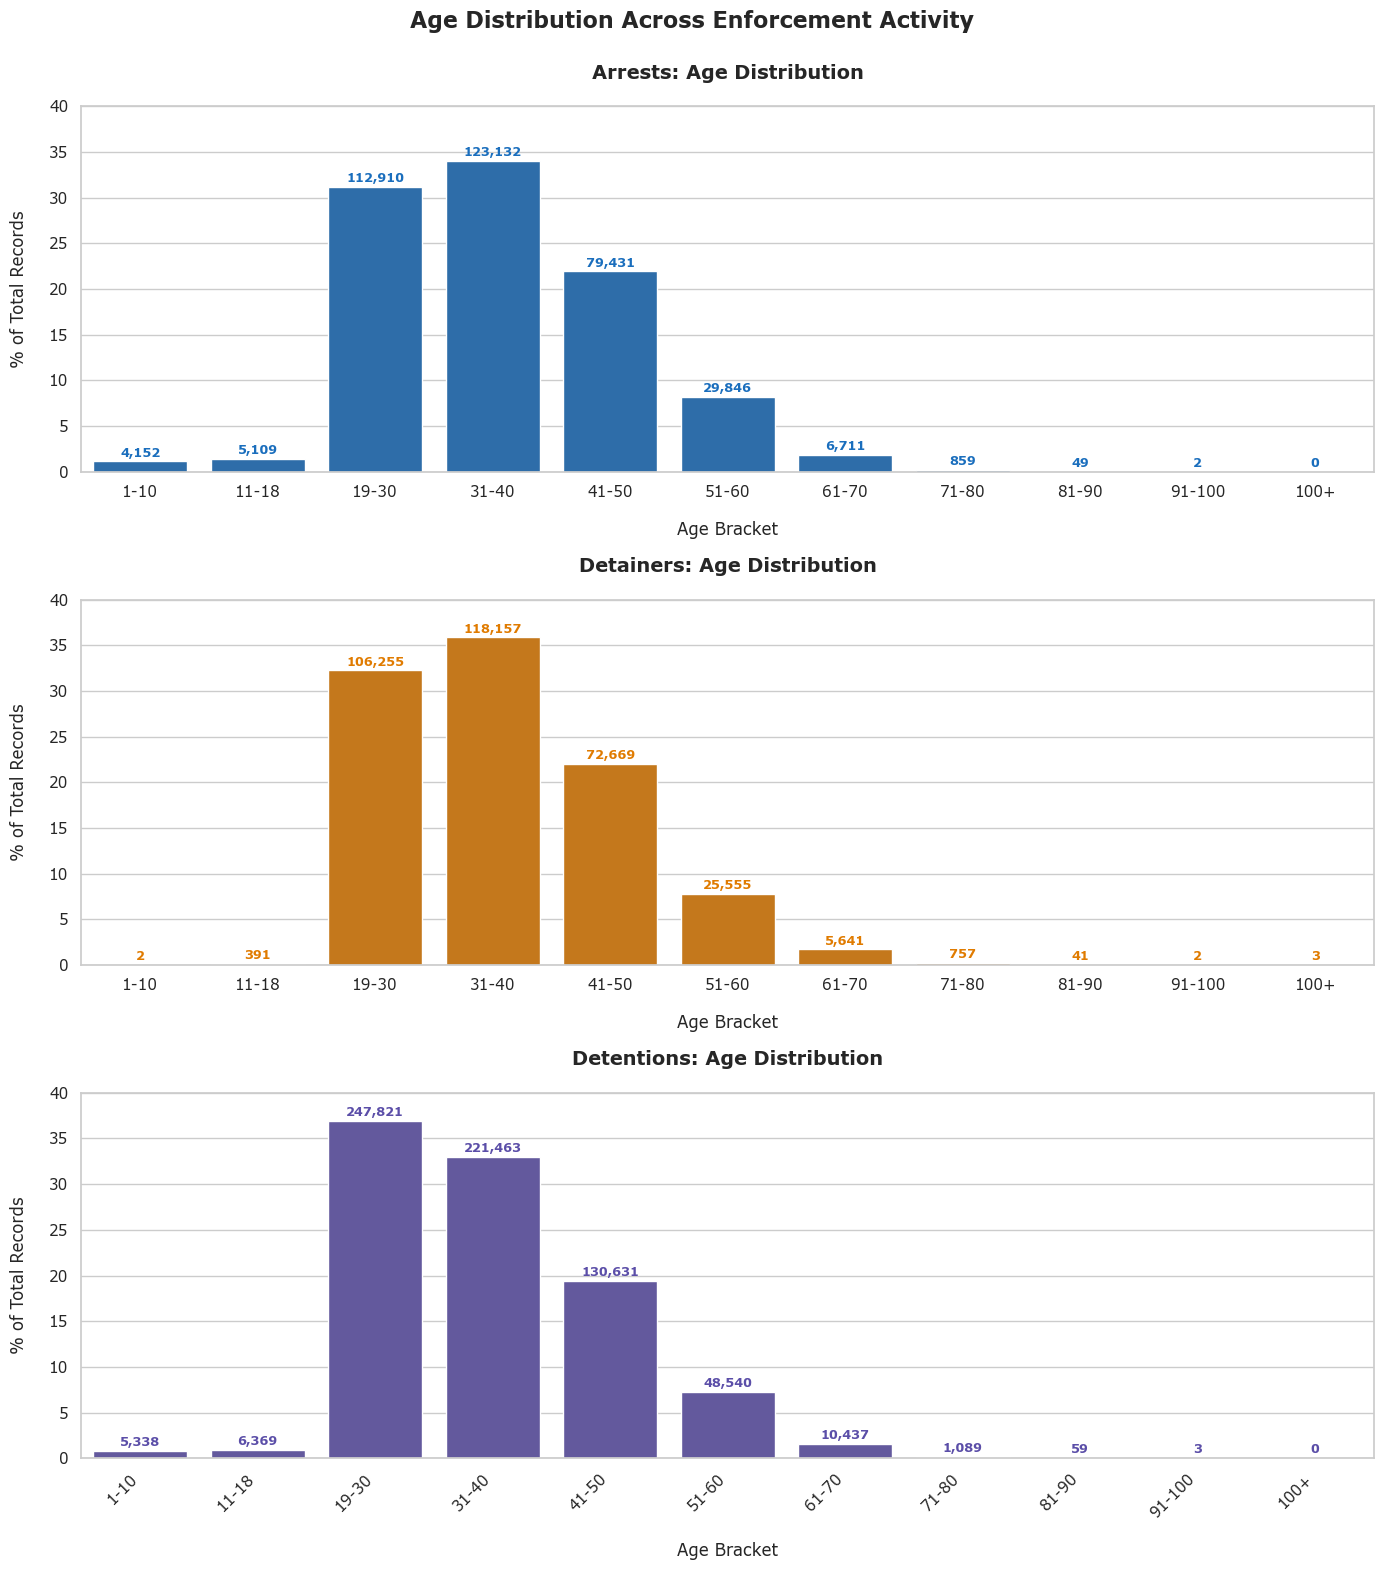

In [29]:
# creating a bar chart instead to better visualize the age distribution
age_bar_labels: list[str] = ['1-10', '11-18', '19-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100', '100+']

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 16))

# ARRESTS BAR CHART
sns.barplot(
    x=age_bar_labels,
    y=[
        age_pct_1_10, age_pct_11_18, age_pct_19_30,
        age_pct_31_40, age_pct_41_50, age_pct_51_60,
        age_pct_61_70, age_pct_71_80, age_pct_81_90,
        age_pct_91_100, age_pct_over_100
    ],
    color='#1A6EBD',
    ax=ax1
)

# count annotation above bars
age_arrests_heights: list[float] = [
    age_pct_1_10, age_pct_11_18, age_pct_19_30,
    age_pct_31_40, age_pct_41_50, age_pct_51_60,
    age_pct_61_70, age_pct_71_80, age_pct_81_90,
    age_pct_91_100, age_pct_over_100
]
age_arrests_counts: list[int] = [
    len(age_arrests_1_10), len(age_arrests_11_18), len(age_arrests_19_30),
    len(age_arrests_31_40), len(age_arrests_41_50), len(age_arrests_51_60),
    len(age_arrests_61_70), len(age_arrests_71_80), len(age_arrests_81_90),
    len(age_arrests_91_100), len(age_arrests_over_100)
]
for x, height, count in zip(range(11), age_arrests_heights, age_arrests_counts):
    ax1.text(x, height + 0.3, f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1A6EBD')

ax1.set_title('Arrests: Age Distribution', fontsize=14, fontweight='semibold', pad=20)
ax1.set_xlabel('Age Bracket', labelpad=15)
ax1.set_ylabel('% of Total Records', labelpad=15)
ax1.set_ylim(0, 40)
plt.xticks(rotation=45, ha='right')

# DETAINERS BAR CHART
sns.barplot(
    x=age_bar_labels,
    y=[
        age_pct_detainers_1_10, age_pct_detainers_11_18, age_pct_detainers_19_30,
        age_pct_detainers_31_40, age_pct_detainers_41_50, age_pct_detainers_51_60,
        age_pct_detainers_61_70, age_pct_detainers_71_80, age_pct_detainers_81_90,
        age_pct_detainers_91_100, age_pct_detainers_over_100
    ],
    color='#E07B00',
    ax=ax2
)

age_detainer_heights: list[float] = [
    age_pct_detainers_1_10, age_pct_detainers_11_18, age_pct_detainers_19_30,
    age_pct_detainers_31_40, age_pct_detainers_41_50, age_pct_detainers_51_60,
    age_pct_detainers_61_70, age_pct_detainers_71_80, age_pct_detainers_81_90,
    age_pct_detainers_91_100, age_pct_detainers_over_100
]
age_detainer_counts: list[int] = [
    len(age_detainers_1_10), len(age_detainers_11_18), len(age_detainers_19_30),
    len(age_detainers_31_40), len(age_detainers_41_50), len(age_detainers_51_60),
    len(age_detainers_61_70), len(age_detainers_71_80), len(age_detainers_81_90),
    len(age_detainers_91_100), len(age_detainers_over_100)
]
for x, height, count in zip(range(11), age_detainer_heights, age_detainer_counts):
    ax2.text(x, height + 0.3, f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#E07B00')

ax2.set_title('Detainers: Age Distribution', fontsize=14, fontweight='semibold', pad=20)
ax2.set_xlabel('Age Bracket', labelpad=15)
ax2.set_ylabel('% of Total Records', labelpad=15)
ax2.set_ylim(0, 40)
plt.xticks(rotation=45, ha='right')

# DETENTIONS BAR CHART
sns.barplot(
    x=age_bar_labels,
    y=[
        age_pct_detentions_1_10, age_pct_detentions_11_18, age_pct_detentions_19_30,
        age_pct_detentions_31_40, age_pct_detentions_41_50, age_pct_detentions_51_60,
        age_pct_detentions_61_70, age_pct_detentions_71_80, age_pct_detentions_81_90,
        age_pct_detentions_91_100, age_pct_detentions_over_100
    ],
    color='#5B4EA8',
    ax=ax3
)

age_detention_heights = [
    age_pct_detentions_1_10, age_pct_detentions_11_18, age_pct_detentions_19_30,
    age_pct_detentions_31_40, age_pct_detentions_41_50, age_pct_detentions_51_60,
    age_pct_detentions_61_70, age_pct_detentions_71_80, age_pct_detentions_81_90,
    age_pct_detentions_91_100, age_pct_detentions_over_100
]
age_detention_counts = [
    len(age_detentions_1_10), len(age_detentions_11_18), len(age_detentions_19_30),
    len(age_detentions_31_40), len(age_detentions_41_50), len(age_detentions_51_60),
    len(age_detentions_61_70), len(age_detentions_71_80), len(age_detentions_81_90),
    len(age_detentions_91_100), len(age_detentions_over_100)
]
for x, height, count in zip(range(11), age_detention_heights, age_detention_counts):
    ax3.text(x, height + 0.3, f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#5B4EA8')

ax3.set_title('Detentions: Age Distribution', fontsize=14, fontweight='semibold', pad=20)
ax3.set_xlabel('Age Bracket', labelpad=15)
ax3.set_ylabel('% of Total Records', labelpad=15)
ax3.set_ylim(0, 40)
plt.xticks(rotation=45, ha='right')

plt.suptitle('Age Distribution Across Enforcement Activity\n', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Age Distribution Pre-Post Trump Analysis

In [30]:
# looking to see if there are meaningful differences pre-post Trump
# arrests analysis
arrests_pre_transition: DataFrame = df_arrests[df_arrests['apprehension_date'] < transition_date]
arrests_post_transition: DataFrame = df_arrests[df_arrests['apprehension_date'] >= transition_date]

print(f'Arrests pre-transition: {len(arrests_pre_transition):,}')
print(f'Arrests post-transition: {len(arrests_post_transition):,}')

# Define age buckets as (label, min, max)
age_buckets: list[tuple] = [
    ('1-10', 1, 10),
    ('11-18', 11, 18),
    ('19-30', 19, 30),
    ('31-40', 31, 40),
    ('41-50', 41, 50),
    ('51-60', 51, 60),
    ('61-70', 61, 70),
    ('71-80', 71, 80),
    ('81-90', 81, 90),
    ('91-100', 91, 100),
    ('100+', 101, 999)
]

print('\n--- Pre-Transition ---')
for label, age_min, age_max in age_buckets:
    count: int = len(arrests_pre_transition[(arrests_pre_transition['age'] >= age_min) & (arrests_pre_transition['age'] <= age_max)])
    percent: float = count / len(arrests_pre_transition) * 100
    print(f'{label}: {count:,} ({percent:.2f}%)')

print('\n--- Post-Transition ---')
for label, age_min, age_max in age_buckets:
    count: int = len(arrests_post_transition[(arrests_post_transition['age'] >= age_min) & (arrests_post_transition['age'] <= age_max)])
    percent: float = count / len(arrests_post_transition) * 100
    print(f'{label}: {count:,} ({percent:.2f}%)')

Arrests pre-transition: 151,159
Arrests post-transition: 211,043

--- Pre-Transition ---
1-10: 3,124 (2.07%)
11-18: 3,530 (2.34%)
19-30: 43,163 (28.55%)
31-40: 52,221 (34.55%)
41-50: 33,787 (22.35%)
51-60: 12,148 (8.04%)
61-70: 2,741 (1.81%)
71-80: 416 (0.28%)
81-90: 28 (0.02%)
91-100: 1 (0.00%)
100+: 0 (0.00%)

--- Post-Transition ---
1-10: 1,028 (0.49%)
11-18: 1,579 (0.75%)
19-30: 69,747 (33.05%)
31-40: 70,911 (33.60%)
41-50: 45,644 (21.63%)
51-60: 17,698 (8.39%)
61-70: 3,970 (1.88%)
71-80: 443 (0.21%)
81-90: 21 (0.01%)
91-100: 1 (0.00%)
100+: 0 (0.00%)


In [31]:
# age distribution pre-post Trump
# detainers analysis

detainers_pre_transition: DataFrame = df_detainers[df_detainers['detainer_prepare_date'] < transition_date]
detainers_post_transition: DataFrame = df_detainers[df_detainers['detainer_prepare_date'] >= transition_date]

print(f'Detainers pre-transition: {len(detainers_pre_transition):,}')
print(f'Detainers post-transition: {len(detainers_post_transition):,}')

print('\n--- Pre-Transition ---')
for label, age_min, age_max in age_buckets:
    count: int = len(detainers_pre_transition[(detainers_pre_transition['age'] >= age_min) & (detainers_pre_transition['age'] <= age_max)])
    percent: float = count / len(detainers_pre_transition) * 100
    print(f'{label}: {count:,} ({percent:.2f}%)')

print('\n--- Post-Transition ---')
for label, age_min, age_max in age_buckets:
    count: int = len(detainers_post_transition[(detainers_post_transition['age'] >= age_min) & (detainers_post_transition['age'] <= age_max)])
    percent: float = count / len(detainers_post_transition) * 100
    print(f'{label}: {count:,} ({percent:.2f}%)')

Detainers pre-transition: 173,153
Detainers post-transition: 156,330

--- Pre-Transition ---
1-10: 1 (0.00%)
11-18: 60 (0.03%)
19-30: 51,415 (29.69%)
31-40: 63,217 (36.51%)
41-50: 40,511 (23.40%)
51-60: 14,340 (8.28%)
61-70: 3,133 (1.81%)
71-80: 445 (0.26%)
81-90: 23 (0.01%)
91-100: 1 (0.00%)
100+: 2 (0.00%)

--- Post-Transition ---
1-10: 1 (0.00%)
11-18: 331 (0.21%)
19-30: 54,840 (35.08%)
31-40: 54,940 (35.14%)
41-50: 32,158 (20.57%)
51-60: 11,215 (7.17%)
61-70: 2,508 (1.60%)
71-80: 312 (0.20%)
81-90: 18 (0.01%)
91-100: 1 (0.00%)
100+: 1 (0.00%)


In [32]:
# age distribution pre-post Trump
# detentions analysis

detentions_pre_transition: DataFrame = df_detentions[df_detentions['stay_book_in_date_time'] < transition_date]
detentions_post_transition: DataFrame = df_detentions[df_detentions['stay_book_in_date_time'] >= transition_date]

print(f'Detentions pre-transition: {len(detentions_pre_transition):,}')
print(f'Detentions post-transition: {len(detentions_post_transition):,}')

print('\n--- Pre-Transition ---')
for label, age_min, age_max in age_buckets:
    count: int = len(detentions_pre_transition[(detentions_pre_transition['age'] >= age_min) & (detentions_pre_transition['age'] <= age_max)])
    percent: float = count / len(detentions_pre_transition) * 100
    print(f'{label}: {count:,} ({percent:.2f}%)')

print('\n--- Post-Transition ---')
for label, age_min, age_max in age_buckets:
    count: int = len(detentions_post_transition[(detentions_post_transition['age'] >= age_min) & (detentions_post_transition['age'] <= age_max)])
    percent: float = count / len(detentions_post_transition) * 100
    print(f'{label}: {count:,} ({percent:.2f}%)')

Detentions pre-transition: 411,873
Detentions post-transition: 259,877

--- Pre-Transition ---
1-10: 3,482 (0.85%)
11-18: 4,396 (1.07%)
19-30: 159,724 (38.78%)
31-40: 135,021 (32.78%)
41-50: 75,693 (18.38%)
51-60: 27,321 (6.63%)
61-70: 5,662 (1.37%)
71-80: 548 (0.13%)
81-90: 25 (0.01%)
91-100: 1 (0.00%)
100+: 0 (0.00%)

--- Post-Transition ---
1-10: 1,856 (0.71%)
11-18: 1,973 (0.76%)
19-30: 88,097 (33.90%)
31-40: 86,442 (33.26%)
41-50: 54,938 (21.14%)
51-60: 21,219 (8.17%)
61-70: 4,775 (1.84%)
71-80: 541 (0.21%)
81-90: 34 (0.01%)
91-100: 2 (0.00%)
100+: 0 (0.00%)


#### GROUPED BAR CHART: Age Distribution Pre-Post Trump

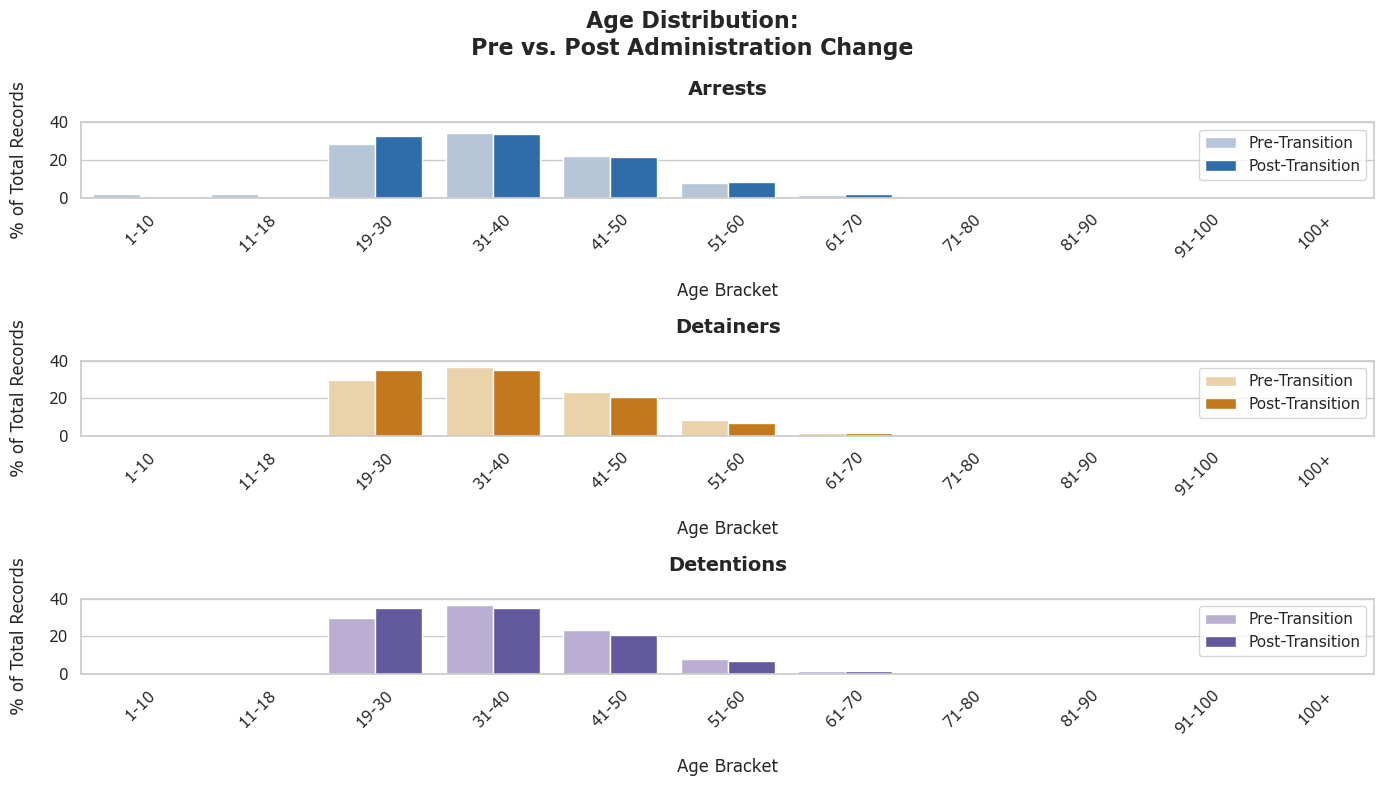

In [84]:
# combining findings and creating grouped bar charts

age_labels: list[str] = ['1-10', '11-18', '19-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100', '100+']

age_arrests_pre_pct: list[float] = []
age_arrests_post_pct: list[float] = []

for label, age_min, age_max in age_buckets:
    pre_count: int = len(arrests_pre_transition[(arrests_pre_transition['age'] >= age_min) & (arrests_pre_transition['age'] <= age_max)])
    post_count: int = len(arrests_post_transition[(arrests_post_transition['age'] >= age_min) & (arrests_post_transition['age'] <= age_max)])
    age_arrests_pre_pct.append(pre_count / len(arrests_pre_transition) * 100)
    age_arrests_post_pct.append(post_count / len(arrests_post_transition) * 100)

age_detainers_pre_pct: list[float] = []
age_detainers_post_pct: list[float] = []

for label, age_min, age_max in age_buckets:
    pre_count: int = len(detainers_pre_transition[(detainers_pre_transition['age'] >= age_min) & (detainers_pre_transition['age'] <= age_max)])
    post_count: int = len(detainers_post_transition[(detainers_post_transition['age'] >= age_min) & (detainers_post_transition['age'] <= age_max)])
    age_detainers_pre_pct.append(pre_count / len(detainers_pre_transition) * 100)
    age_detainers_post_pct.append(post_count / len(detainers_post_transition) * 100)

age_detentions_pre_pct: list[float] = []
age_detentions_post_pct: list[float] = []

for label, age_min, age_max in age_buckets:
    pre_count: int = len(detentions_pre_transition[(detentions_pre_transition['age'] >= age_min) & (detentions_pre_transition['age'] <= age_max)])
    post_count: int = len(detentions_post_transition[(detentions_post_transition['age'] >= age_min) & (detentions_post_transition['age'] <= age_max)])
    age_detentions_pre_pct.append(pre_count / len(detentions_pre_transition) * 100)
    age_detentions_post_pct.append(post_count / len(detentions_post_transition) * 100)

# Create DataFrames for use in charts

arrests_age_data: DataFrame = DataFrame({
    'Age Bracket' : age_labels * 2,
    'Period' : ['Pre-Transition'] * 11 + ['Post-Transition'] * 11,
    'Percentage' : age_arrests_pre_pct + age_arrests_post_pct
})

# # check dataframe
# print(arrests_age_data)

detainers_age_data: DataFrame = DataFrame({
    'Age Bracket' : age_labels * 2, # repeat the list for the pre-post columns
    'Period' : ['Pre-Transition'] * 11 + ['Post-Transition'] * 11, # copy 11 labels for each column
    'Percentage' : age_detainers_pre_pct + age_detainers_post_pct # put the two lists into one 22-item list
})

detentions_age_data: DataFrame = DataFrame({
    'Age Bracket' : age_labels * 2,
    'Period' : ['Pre-Transition'] * 11 + ['Post-Transition'] * 11,
    'Percentage' : age_detentions_pre_pct + age_detentions_post_pct
})

# create charts

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14,8))

# arrests
sns.barplot(
    data=arrests_age_data,
    x='Age Bracket',
    y='Percentage',
    hue='Period',
    palette=['#B0C4DE', '#1A6EBD'],
    ax=ax1
)

ax1.set_title('Arrests', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Age Bracket', labelpad=15)
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel('% of Total Records', labelpad=15)
ax1.set_ylim(0, 40)
ax1.legend()

# detainers
sns.barplot(
    data=detainers_age_data,
    x='Age Bracket',
    y='Percentage',
    hue='Period',
    palette=['#F5D5A0', '#E07B00'],
    ax=ax2
)

ax2.set_title('Detainers', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Age Bracket', labelpad=15)
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylabel('% of Total Records', labelpad=15)
ax2.set_ylim(0, 40)
ax2.legend()

# detentions
sns.barplot(
    data=detainers_age_data,
    x='Age Bracket',
    y='Percentage',
    hue='Period',
    palette=['#B8A9D9', '#5B4EA8'],
    ax=ax3
)

ax3.set_title('Detentions', fontsize=14, fontweight='bold', pad=20)
ax3.set_xlabel('Age Bracket', labelpad=15)
ax3.tick_params(axis='x', rotation=45)
ax3.set_ylabel('% of Total Records', labelpad=15)
ax3.set_ylim(0, 40)
ax3.legend()

plt.suptitle('Age Distribution:\nPre vs. Post Administration Change', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### --- SEX/GENDER ANALYSIS ---

#### Gender Breakdown Summary

In [34]:
# trying to simplify the dataframe creation by using loops
datasets: list[tuple] = [
    ('Arrests', df_arrests),
    ('Detainers', df_detainers),
    ('Detentions', df_detentions)
]

for name, df in datasets:
    total: int = len(df)
    gender_counts: DataFrame = df['gender'].value_counts()
    gender_pct: DataFrame = (df['gender'].value_counts(normalize=True) * 100).round(2) # get clarification on "normalize=True"
    # get clarification on print statements
    print(f'\n{'='*50}')
    print(f'  {name} - Gender Breakdown (n={total:,})')
    print(f'{'='*50}')

    for gender in ['MALE', 'FEMALE', 'UNKNOWN']:
        count: int = gender_counts.get(gender, 0)
        percent: float = gender_pct.get(gender, 0.0)
        print(f'  {gender:<10} {count:>10,}  ({percent:.2f}%)')



  Arrests - Gender Breakdown (n=362,202)
  MALE          316,212  (87.30%)
  FEMALE         44,601  (12.31%)
  UNKNOWN         1,389  (0.38%)

  Detainers - Gender Breakdown (n=329,483)
  MALE          295,197  (89.59%)
  FEMALE         26,589  (8.07%)
  UNKNOWN         7,697  (2.34%)

  Detentions - Gender Breakdown (n=671,750)
  MALE          568,099  (84.57%)
  FEMALE        103,457  (15.40%)
  UNKNOWN           194  (0.03%)


#### HORIZONTAL BAR CHART: Gender Distribution Across Tables

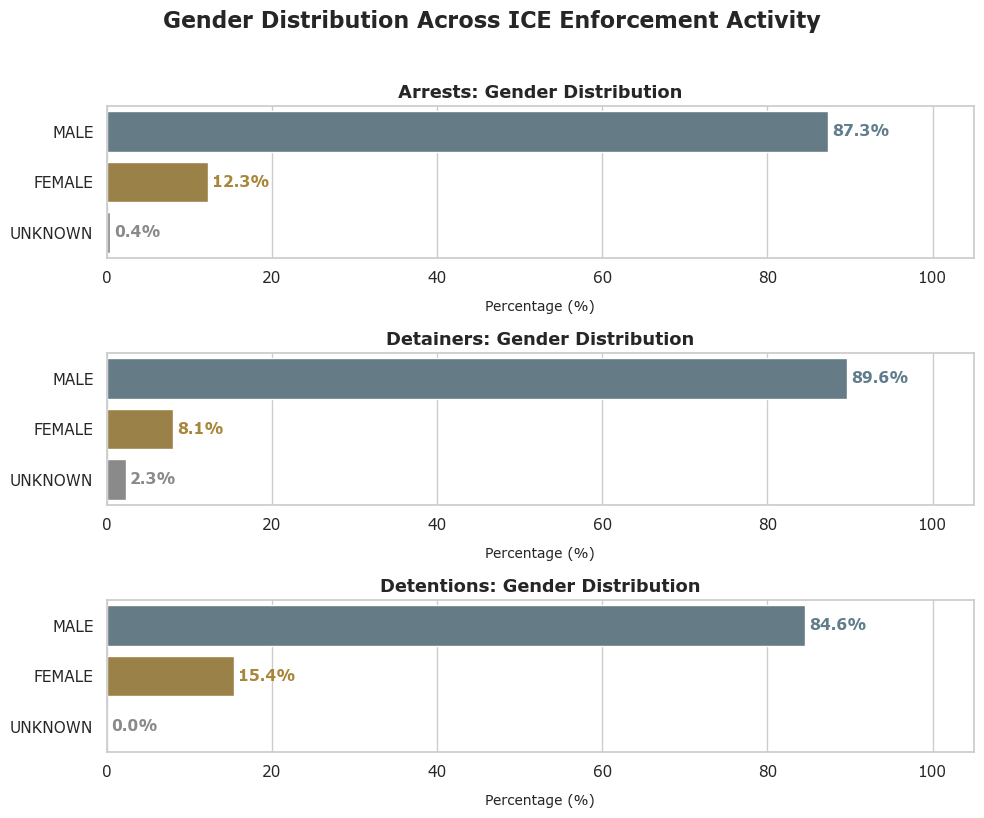

In [107]:
# gender distribution horizontal bar chart for all datasets

# create dictionary of colors to use in each subplot
gender_colors: dict[str, str] = {
    'MALE' : '#607D8B',
    'FEMALE' : '#A8863A',
    'UNKNOWN' : '#8A8A8A'
}

gender_order: list[str] = ['MALE', 'FEMALE', 'UNKNOWN']

# create percentage DataFrames for each dataset
gender_arrests_pct: DataFrame = (
    df_arrests['gender'].value_counts(normalize=True) * 100
).round(2).reset_index() # get clarification
gender_arrests_pct.columns = ['gender', 'percentage']

gender_detainers_pct: DataFrame = (
    df_detainers['gender'].value_counts(normalize=True) * 100
).round(2).reset_index()
gender_detainers_pct.columns = ['gender', 'percentage']

gender_detentions_pct: DataFrame = (
    df_detentions['gender'].value_counts(normalize=True) * 100
).round(2).reset_index()
gender_detentions_pct.columns = ['gender', 'percentage']

# create charts
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Gender Distribution Across ICE Enforcement Activity', fontsize=16, fontweight='bold', y=1.02)

# arrests
sns.barplot(
    data=gender_arrests_pct,
    x='percentage',
    y='gender',
    hue='gender',
    order=gender_order,
    palette=gender_colors,
    ax=ax1
)

ax1.set_title('Arrests: Gender Distribution', fontsize=13, fontweight='semibold')
ax1.set_xlabel('Percentage (%)', fontsize=10, labelpad=10)
ax1.set_ylabel('') # get clarification
ax1.set_xlim(0, 105) # get clarification

# annotate each bar with percentages
male_arrests_pct: float = gender_arrests_pct.loc[gender_arrests_pct['gender'] == 'MALE', 'percentage'].values[0]
female_arrests_pct: float = gender_arrests_pct.loc[gender_arrests_pct['gender'] == 'FEMALE', 'percentage'].values[0]
unknown_arrests_pct: float = gender_arrests_pct.loc[gender_arrests_pct['gender'] == 'UNKNOWN', 'percentage'].values[0]

ax1.text(male_arrests_pct + 0.5, 0, f'{male_arrests_pct:.1f}%', fontsize=11, fontweight='semibold', color='#607D8B', va='center', clip_on=False)
ax1.text(female_arrests_pct + 0.5, 1, f'{female_arrests_pct:.1f}%', fontsize=11, fontweight='semibold', color='#A8863A', va='center', clip_on=False)
ax1.text(unknown_arrests_pct + 0.5, 2, f'{unknown_arrests_pct:.1f}%', fontsize=11, fontweight='semibold', color='#8A8A8A', va='center', clip_on=False)

# detainers
sns.barplot(
    data=gender_detainers_pct,
    x='percentage',
    y='gender',
    hue='gender',
    order=gender_order,
    palette=gender_colors,
    ax=ax2
)

ax2.set_title('Detainers: Gender Distribution', fontsize=13, fontweight='semibold')
ax2.set_xlabel('Percentage (%)', fontsize=10, labelpad=10)
ax2.set_ylabel('')
ax2.set_xlim(0, 105)

male_detainers_pct: float = gender_detainers_pct.loc[gender_detainers_pct['gender'] == 'MALE', 'percentage'].values[0]
female_detainers_pct: float = gender_detainers_pct.loc[gender_detainers_pct['gender'] == 'FEMALE', 'percentage'].values[0]
unknown_detainers_pct: float = gender_detainers_pct.loc[gender_detainers_pct['gender'] == 'UNKNOWN', 'percentage'].values[0]

ax2.text(male_detainers_pct + 0.5, 0, f'{male_detainers_pct:.1f}%', fontsize=11, fontweight='semibold', color='#607D8B', va='center', clip_on=False)
ax2.text(female_detainers_pct + 0.5, 1, f'{female_detainers_pct:.1f}%', fontsize=11, fontweight='semibold', color='#A8863A', va='center', clip_on=False)
ax2.text(unknown_detainers_pct + 0.5, 2, f'{unknown_detainers_pct:.1f}%', fontsize=11, fontweight='semibold', color='#8A8A8A', va='center', clip_on=False)

# detentions
sns.barplot(
    data=gender_detentions_pct,
    x='percentage',
    y='gender',
    hue='gender',
    order=gender_order,
    palette=gender_colors,
    ax=ax3
)

ax3.set_title('Detentions: Gender Distribution', fontsize=13, fontweight='semibold')
ax3.set_xlabel('Percentage (%)', fontsize=10, labelpad=10)
ax3.set_ylabel('')
ax3.set_xlim(0, 105)

male_detentions_pct: float = gender_detentions_pct.loc[gender_detentions_pct['gender'] == 'MALE', 'percentage'].values[0]
female_detentions_pct: float = gender_detentions_pct.loc[gender_detentions_pct['gender'] == 'FEMALE', 'percentage'].values[0]
unknown_detentions_pct: float = gender_detentions_pct.loc[gender_detentions_pct['gender'] == 'UNKNOWN', 'percentage'].values[0]

ax3.text(male_detentions_pct + 0.5, 0, f'{male_detentions_pct:.1f}%', fontsize=11, fontweight='semibold', color='#607D8B', va='center', clip_on=False)
ax3.text(female_detentions_pct + 0.5, 1, f'{female_detentions_pct:.1f}%', fontsize=11, fontweight='semibold', color='#A8863A', va='center', clip_on=False)
ax3.text(unknown_detentions_pct + 0.5, 2, f'{unknown_detentions_pct:.1f}%', fontsize=11, fontweight='semibold', color='#8A8A8A', va='center', clip_on=False)

plt.tight_layout()
plt.show()


#### BAR CHART: Gender Distribution Pre-Post Trump

In [36]:
# build percentage data frames for each dataset
# arrests
gender_arrests_pre_pct: DataFrame = (
    arrests_pre_transition['gender'].value_counts(normalize=True) * 100
).round(2).reset_index()
gender_arrests_pre_pct.columns = ['Gender', 'Percentage']
gender_arrests_pre_pct['Period'] = 'Pre-Transition'

gender_arrests_post_pct: DataFrame = (
    arrests_post_transition['gender'].value_counts(normalize=True) * 100
).round(2).reset_index()
gender_arrests_post_pct.columns = ['Gender', 'Percentage']
gender_arrests_post_pct['Period'] = 'Post-Transition'

gender_arrests_data: DataFrame = pd.concat([gender_arrests_pre_pct, gender_arrests_post_pct])

# detainers
gender_detainers_pre_pct: DataFrame = (
    detainers_pre_transition['gender'].value_counts(normalize=True) * 100
).round(2).reset_index()
gender_detainers_pre_pct.columns = ['Gender', 'Percentage']
gender_detainers_pre_pct['Period'] = 'Pre-Transition'

gender_detainers_post_pct: DataFrame = (
    detainers_post_transition['gender'].value_counts(normalize=True) * 100
).round(2).reset_index()
gender_detainers_post_pct.columns = ['Gender', 'Percentage']
gender_detainers_post_pct['Period'] = 'Post-Transition'

gender_detainers_data: DataFrame = pd.concat([gender_detainers_pre_pct, gender_detainers_post_pct])

# detentions
gender_detentions_pre_pct: DataFrame = (
    detentions_pre_transition['gender'].value_counts(normalize=True) * 100
).round(2).reset_index()
gender_detentions_pre_pct.columns = ['Gender', 'Percentage']
gender_detentions_pre_pct['Period'] = 'Pre-Transition'

gender_detentions_post_pct: DataFrame = (
    detentions_post_transition['gender'].value_counts(normalize=True) * 100
).round(2).reset_index()
gender_detentions_post_pct.columns = ['Gender', 'Percentage']
gender_detentions_post_pct['Period'] = 'Post-Transition'

gender_detentions_data: DataFrame = pd.concat([gender_detentions_pre_pct, gender_detentions_post_pct])


In [37]:
# build summary tables with percentage change

# arrests
gender_arrests_summary: DataFrame = pd.DataFrame({
    'Gender' : ['MALE', 'FEMALE', 'UNKNOWN'],
    'Pre' : [gender_arrests_pre_pct.loc[gender_arrests_pre_pct['Gender'] == 'MALE', 'Percentage'].values[0],
             gender_arrests_pre_pct.loc[gender_arrests_pre_pct['Gender'] == 'FEMALE', 'Percentage'].values[0],
             gender_arrests_pre_pct.loc[gender_arrests_pre_pct['Gender'] == 'UNKNOWN', 'Percentage'].values[0]],
    'Post' : [gender_arrests_post_pct.loc[gender_arrests_post_pct['Gender'] == 'MALE', 'Percentage'].values[0],
              gender_arrests_post_pct.loc[gender_arrests_post_pct['Gender'] == 'FEMALE', 'Percentage'].values[0],
              gender_arrests_post_pct.loc[gender_arrests_post_pct['Gender'] == 'UNKNOWN', 'Percentage'].values[0]]
})

gender_arrests_summary['Change'] = round(((gender_arrests_summary['Post'] - gender_arrests_summary['Pre']) / gender_arrests_summary['Pre']) * 100, 1)

# detainers
gender_detainers_summary: DataFrame = pd.DataFrame({
    'Gender' : ['MALE', 'FEMALE', 'UNKNOWN'],
    'Pre' : [gender_detainers_pre_pct.loc[gender_detainers_pre_pct['Gender'] == 'MALE', 'Percentage'].values[0],
             gender_detainers_pre_pct.loc[gender_detainers_pre_pct['Gender'] == 'FEMALE', 'Percentage'].values[0],
             gender_detainers_pre_pct.loc[gender_detainers_pre_pct['Gender'] == 'FEMALE', 'Percentage'].values[0]],
    'Post' : [gender_detainers_post_pct.loc[gender_detainers_post_pct['Gender'] == 'MALE', 'Percentage'].values[0],
              gender_detainers_post_pct.loc[gender_detainers_post_pct['Gender'] == 'FEMALE', 'Percentage'].values[0],
              gender_detainers_post_pct.loc[gender_detainers_post_pct['Gender'] == 'UNKNOWN', 'Percentage'].values[0]]
})

gender_detainers_summary['Change'] = round(((gender_detainers_summary['Post'] - gender_detainers_summary['Pre']) / gender_detainers_summary['Pre']) * 100, 1)

# detentions
gender_detentions_summary: DataFrame = pd.DataFrame({
    'Gender' : ['MALE', 'FEMALE', 'UNKNOWN'],
    'Pre' : [gender_detentions_pre_pct.loc[gender_detentions_pre_pct['Gender'] == 'MALE', 'Percentage'].values[0],
             gender_detentions_pre_pct.loc[gender_detentions_pre_pct['Gender'] == 'FEMALE', 'Percentage'].values[0],
             gender_detentions_pre_pct.loc[gender_detentions_pre_pct['Gender'] == 'UNKNOWN', 'Percentage'].values[0]],
    'Post' : [gender_detentions_post_pct.loc[gender_detentions_post_pct['Gender'] == 'MALE', 'Percentage'].values[0],
              gender_detentions_post_pct.loc[gender_detentions_post_pct['Gender'] == 'FEMALE', 'Percentage'].values[0],
              gender_detentions_post_pct.loc[gender_detentions_post_pct['Gender'] == 'UNKNOWN', 'Percentage'].values[0]]
})

gender_detentions_summary['Change'] = round(((gender_detentions_summary['Post'] - gender_detentions_summary['Pre']) / gender_detentions_summary['Pre']) * 100, 1)

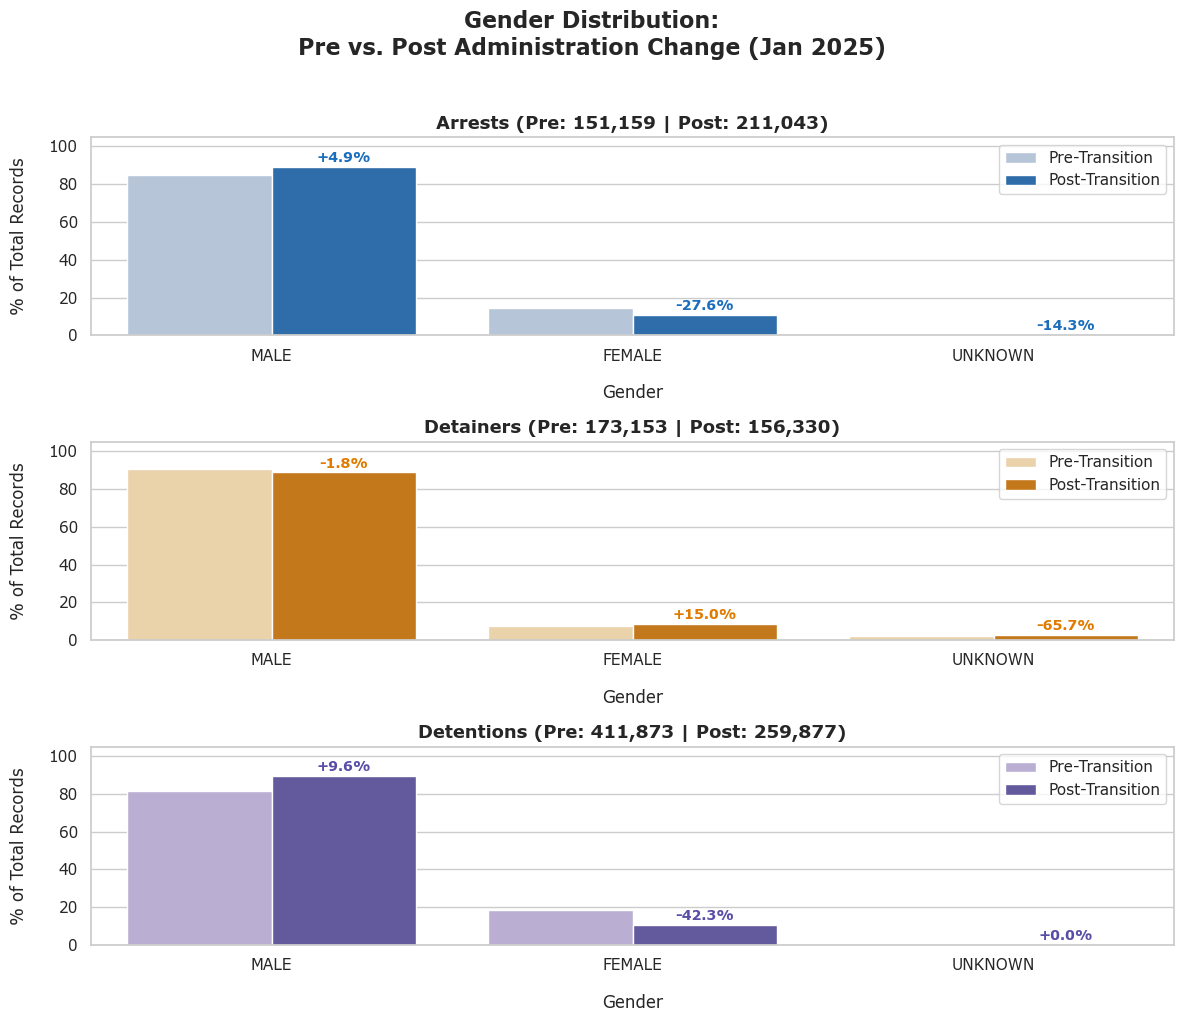

In [38]:
# create charts
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle('Gender Distribution:\nPre vs. Post Administration Change (Jan 2025)', fontsize=16, fontweight='bold', y=1.02)

# arrests
# annotate percentage change - arrests
gender_arrests_heights: list = gender_arrests_summary['Post'].tolist()
gender_arrests_changes: list = gender_arrests_summary['Change'].tolist()

sns.barplot(
    data=gender_arrests_data,
    x='Gender',
    y='Percentage',
    hue='Period',
    palette=['#B0C4DE', '#1A6EBD'],
    ax=ax1
)

ax1.set_title(f'Arrests (Pre: {len(arrests_pre_transition):,} | Post: {len(arrests_post_transition):,})', fontsize=13, fontweight='semibold')
ax1.set_xlabel('Gender', labelpad=15)
ax1.set_ylabel('% of Total Records', labelpad=15)
ax1.set_ylim(0, 105)
ax1.legend(loc='upper right')
ax1.text(0.2, gender_arrests_heights[0] + 1, f'{gender_arrests_changes[0]:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='semibold', color='#1A6EBD')
ax1.text(1.2, gender_arrests_heights[1] + 1, f'{gender_arrests_changes[1]:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='semibold', color='#1A6EBD')
ax1.text(2.2, gender_arrests_heights[2] + 1, f'{gender_arrests_changes[2]:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='semibold', color='#1A6EBD')

# detainers
# annotate percentage change - detainers
gender_detainers_heights: list = gender_detainers_summary['Post'].tolist()
gender_detainers_changes: list = gender_detainers_summary['Change'].tolist()

sns.barplot(
    data=gender_detainers_data,
    x='Gender',
    y='Percentage',
    hue='Period',
    palette=['#F5D5A0', '#E07B00'],
    ax=ax2
)

ax2.set_title(f'Detainers (Pre: {len(detainers_pre_transition):,} | Post: {len(detainers_post_transition):,})', fontsize=13, fontweight='semibold')
ax2.set_xlabel('Gender', labelpad=15)
ax2.set_ylabel('% of Total Records', labelpad=15)
ax2.set_ylim(0, 105)
ax2.legend(loc='upper right')
ax2.text(0.2, gender_detainers_heights[0] + 1, f'{gender_detainers_changes[0]:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='semibold', color='#E07B00')
ax2.text(1.2, gender_detainers_heights[1] + 1, f'{gender_detainers_changes[1]:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='semibold', color='#E07B00')
ax2.text(2.2, gender_detainers_heights[2] + 1, f'{gender_detainers_changes[2]:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='semibold', color='#E07B00')

# detentions
# annotate percentage change - detainers
gender_detentions_heights: list = gender_detentions_summary['Post'].tolist()
gender_detention_changes: list = gender_detentions_summary['Change'].tolist()

sns.barplot(
    data=gender_detentions_data,
    x='Gender',
    y='Percentage',
    hue='Period',
    palette=['#B8A9D9', '#5B4EA8'],
    ax=ax3
)

ax3.set_title(f'Detentions (Pre: {len(detentions_pre_transition):,} | Post: {len(detentions_post_transition):,})', fontsize=13, fontweight='semibold')
ax3.set_xlabel('Gender', labelpad=15)
ax3.set_ylabel('% of Total Records', labelpad=15)
ax3.set_ylim(0, 105)
ax3.legend(loc='upper right')
ax3.text(0.2, gender_detentions_heights[0] + 1, f'{gender_detention_changes[0]:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='semibold', color='#584EA8')
ax3.text(1.2, gender_detentions_heights[1] + 1, f'{gender_detention_changes[1]:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='semibold', color='#584EA8')
ax3.text(2.2, gender_detentions_heights[2] + 1, f'{gender_detention_changes[2]:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='semibold', color='#584EA8')

plt.tight_layout()
plt.show()

### --- DETENTION LENGTH ANALYSIS ---

#### Detention Stay Length Summary

In [39]:
# detention length distribution summary
total_detentions: int = len(df_detentions)
null_count: int = df_detentions['detention_length_days'].isna().sum()
valid_count: int = df_detentions['detention_length_days'].notna().sum()

print(f'{'='*50}')
print(f'  Detention Length Summary (Days)')
print(f'{'='*50}')
print(f'  Total Records:            {total_detentions:,}')
print(f'  Valid (has book-out):     {valid_count:,} ({null_count/total_detentions*100:.1f}%)')
print(f'  Null (still detained:)    {null_count:,} ({null_count/total_detentions*100:.1f}%)')
print(f'{'='*50}')
print(f'  Mean:                     {df_detentions['detention_length_days'].mean():.1f}')
print(f'  Median:                   {df_detentions['detention_length_days'].median():.1f}')
print(f'  Min:                      {df_detentions['detention_length_days'].min():.1f}')
print(f'  Max:                      {df_detentions['detention_length_days'].max():.1f}')
print(f'{'='*50}')
print(f'  25th Percentile:          {df_detentions['detention_length_days'].quantile(0.25):.1f}')
print(f'  75th Percentile:          {df_detentions['detention_length_days'].quantile(0.75):.1f}')
print(f'  90th Percentile:          {df_detentions['detention_length_days'].quantile(0.90):.1f}')
print(f'  99th Percentile:          {df_detentions['detention_length_days'].quantile(0.99):.1f}')
print(f'{'='*50}')

  Detention Length Summary (Days)
  Total Records:            671,750
  Valid (has book-out):     609,849 (9.2%)
  Null (still detained:)    61,901 (9.2%)
  Mean:                     47.6
  Median:                   27.0
  Min:                      0.0
  Max:                      7354.0
  25th Percentile:          8.0
  75th Percentile:          58.0
  90th Percentile:          112.0
  99th Percentile:          329.0


#### HISTOGRAM CHART: Detention Length Distribution

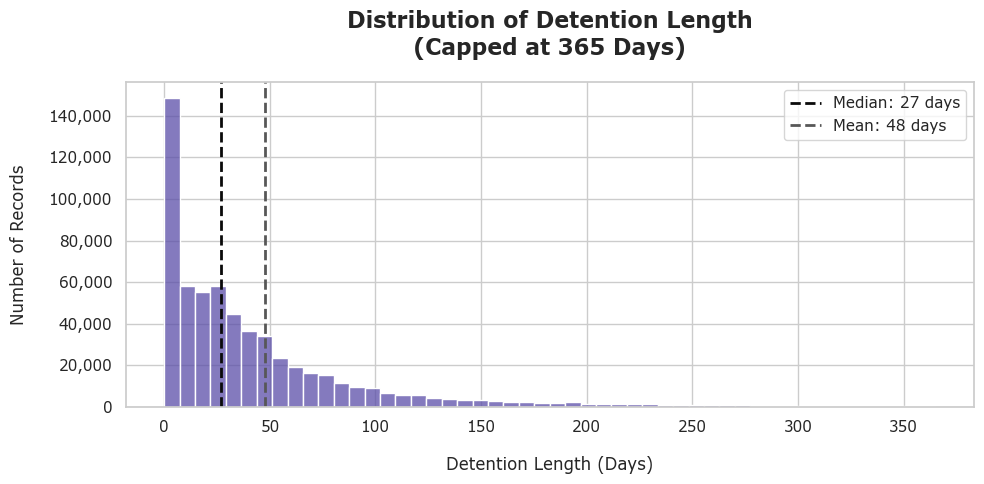


Records shown: 605,490 of 609,849 valid records (99.3%

Records excluded (>365 days): 4,359


In [40]:
# detention length distribution histogram
# filtering out nulls and setting 365-day limit to make it easier to read

detention_length_not_null: DataFrame = df_detentions[df_detentions['detention_length_days'].notna()]
detention_length_limit: DataFrame = detention_length_not_null[detention_length_not_null['detention_length_days'] <= 365]

# calculate median + mean for reference lines
detention_median: float = df_detentions['detention_length_days'].median()
detention_mean: float = df_detentions['detention_length_days'].mean()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=detention_length_limit,
    x='detention_length_days',
    bins=50,
    color='#5B4EA8',
    ax=ax
)

# add ref lines
ax.axvline(
    x=detention_median,
    color='#0a0a0a',
    linewidth=2,
    linestyle='--',
    label=f'Median: {detention_median:.0f} days'
)
ax.axvline(
    x=detention_mean,
    color='#575757',
    linewidth=2,
    linestyle='--',
    label=f'Mean: {detention_mean:.0f} days'
)

ax.set_title('Distribution of Detention Length\n(Capped at 365 Days)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Detention Length (Days)', labelpad=15)
ax.set_ylabel('Number of Records', labelpad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # noqa
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

print(f'\nRecords shown: {len(detention_length_limit):,} of {len(detention_length_not_null):,} valid records ({len(detention_length_limit)/len(detention_length_not_null)*100:.1f}%')
print(f'\nRecords excluded (>365 days): {len(detention_length_not_null) - len(detention_length_limit):,}')


#### HISTOGRAM CHART: Detention Length Distribution Pre-Post Trump

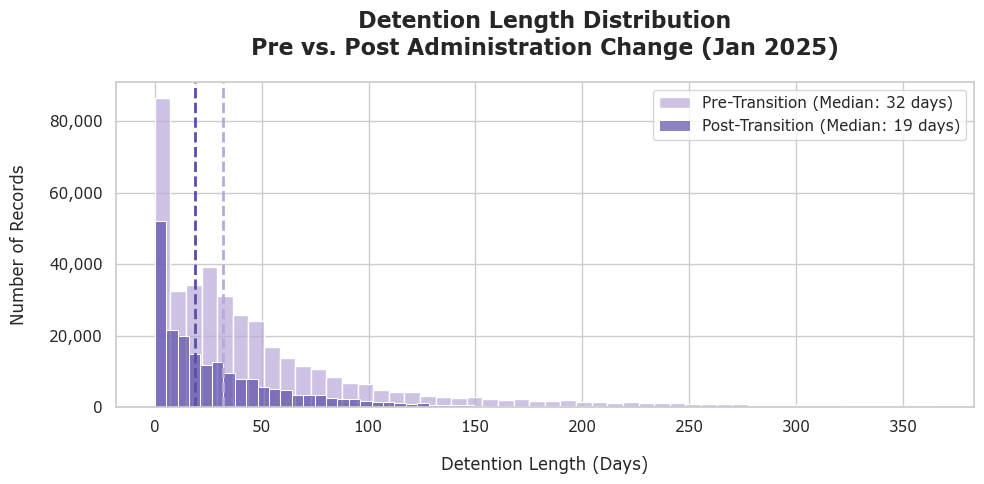


Pre-Transition: Median = 32 days | Records = 401,528

Post-Transition: Median = 19 days | Records = 203,962


In [41]:
# detention length pre-post transition comparisons
# filter out null records and set same 365-day limit for both pre-post periods
detentions_pre_not_null: DataFrame = detentions_pre_transition[
    (detentions_pre_transition['detention_length_days'].notna()) &
    (detentions_pre_transition['detention_length_days'] <= 365)
]

detentions_post_not_null: DataFrame = detentions_post_transition[
    (detentions_post_transition['detention_length_days'].notna()) &
    (detentions_post_transition['detention_length_days'] <= 365)
]

# calculate median for each period
pre_median: float = detentions_pre_transition['detention_length_days'].median()
post_median: float = detentions_post_transition['detention_length_days'].median()

# create hist plot
fig, ax = plt.subplots(figsize=(10,5))

sns.histplot(
    data=detentions_pre_not_null,
    x='detention_length_days',
    bins=50,
    color='#B8A9D9',
    label=f'Pre-Transition (Median: {pre_median:.0f} days)',
    alpha=0.7,
    ax=ax
)

sns.histplot(
    data=detentions_post_not_null,
    x='detention_length_days',
    bins=50,
    color='#5B4EA8',
    label=f'Post-Transition (Median: {post_median:.0f} days)',
    alpha=0.7,
    ax=ax
)

ax.axvline(
    x=pre_median,
    color='#B8A9D9',
    linewidth=2,
    linestyle='--'
)

ax.axvline(
    x=post_median,
    color='#584EA8',
    linewidth=2,
    linestyle='--'
)

ax.set_title('Detention Length Distribution\nPre vs. Post Administration Change (Jan 2025)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Detention Length (Days)', labelpad=15)
ax.set_ylabel('Number of Records', labelpad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # noqa
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

print(f'\nPre-Transition: Median = {pre_median:.0f} days | Records = {len(detentions_pre_not_null):,}')
print(f'\nPost-Transition: Median = {post_median:.0f} days | Records = {len(detentions_post_not_null):,}')

#### BOXPLOT CHART: Detention Length by Criminality Category

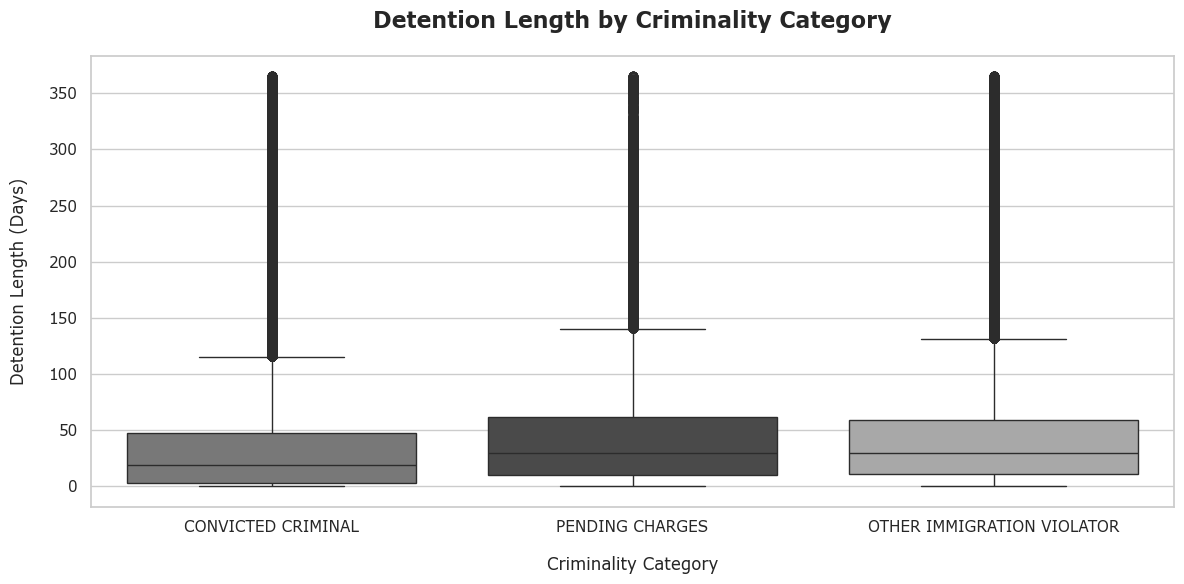

  CONVICTED CRIMINAL:          19 days
  PENDING CHARGES:             30 days
  OTHER IMMIGRATION VIOLATOR:  30 days


In [100]:
# detention length by criminality category
# filter for non-null detention length records, limit to 365 days
detention_by_crime: DataFrame = df_detentions[
    (df_detentions['detention_length_days'].notna()) &
    (df_detentions['detention_length_days'] <= 365) &
    (df_detentions['criminality_clean'].notna())
]

criminality_order: list[str] = ['CONVICTED CRIMINAL', 'PENDING CHARGES', 'OTHER IMMIGRATION VIOLATOR']

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=detention_by_crime,
    x='criminality_clean',
    y='detention_length_days',
    order=criminality_order,
    hue='criminality_clean',
    palette=['#4A4A4A', '#787878', '#A8A8A8'],
    ax=ax
)


ax.set_title('Detention Length by Criminality Category', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Criminality Category', labelpad=15)
ax.set_ylabel('Detention Length (Days)', labelpad=15)

plt.tight_layout()
plt.show()

convicted_median: float = detention_by_crime.loc[detention_by_crime['criminality_clean'] == 'CONVICTED CRIMINAL', 'detention_length_days'].median()
pending_median: float = detention_by_crime.loc[detention_by_crime['criminality_clean'] == 'PENDING CHARGES', 'detention_length_days'].median()
immigration_median: float = detention_by_crime.loc[detention_by_crime['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR', 'detention_length_days'].median()

print(f"  CONVICTED CRIMINAL:          {convicted_median:.0f} days")
print(f"  PENDING CHARGES:             {pending_median:.0f} days")
print(f"  OTHER IMMIGRATION VIOLATOR:  {immigration_median:.0f} days")
print(f"{'='*60}")

### --- CRIMINALITY ANALYSIS ---

#### BAR CHART: Criminality Distribution

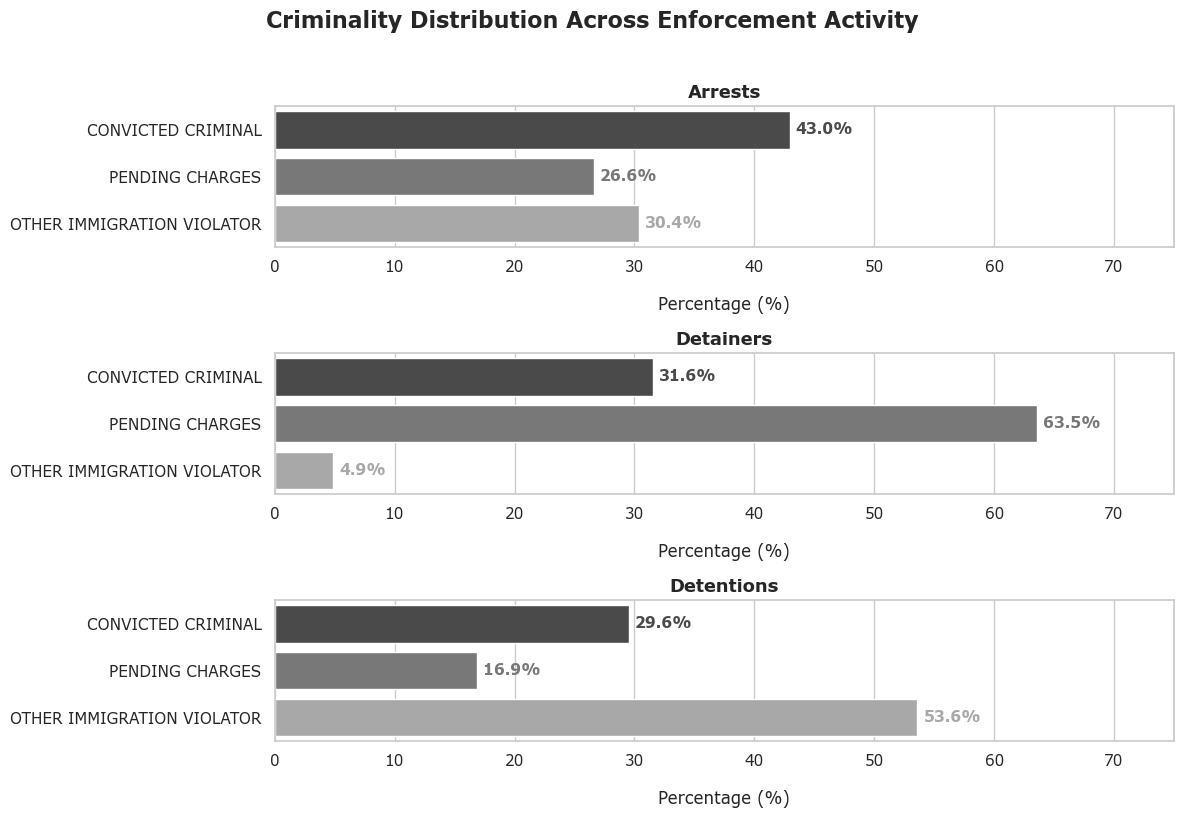

In [101]:
# create dictionary of colors for each criminal category
criminality_colors: dict[str, str] = {
    'CONVICTED CRIMINAL' : '#4A4A4A',
    'PENDING CHARGES' : '#787878',
    'OTHER IMMIGRATION VIOLATOR' : '#A8A8A8'
}

# create percentage dataframes for each of the datasets
# arrests
crime_arrests_pct: DataFrame = (
    df_arrests['criminality_clean'].value_counts(normalize=True) * 100
).round(2).reset_index()
crime_arrests_pct.columns = ['criminality', 'percentage']

# detainers
crime_detainers_pct: DataFrame = (
    df_detainers['criminality_clean'].value_counts(normalize=True) * 100
).round(2).reset_index()
crime_detainers_pct.columns = ['criminality', 'percentage']

# detentions
crime_detentions_pct: DataFrame = (
    df_detentions['criminality_clean'].value_counts(normalize=True) * 100
).round(2).reset_index()
crime_detentions_pct.columns = ['criminality', 'percentage']

# create charts
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,8))
fig.suptitle('Criminality Distribution Across Enforcement Activity', fontsize=16, fontweight='bold', y=1.02)

sns.barplot(
    data=crime_arrests_pct,
    x='percentage',
    y='criminality',
    hue='criminality',
    order=criminality_order,
    palette=criminality_colors,
    legend=False,
    ax=ax1
)

ax1.set_title('Arrests', fontsize=13, fontweight='semibold')
ax1.set_xlabel('Percentage (%)', labelpad=15)
ax1.set_ylabel('')
ax1.set_xlim(0, 75)

convicted_arrests_pct: float = crime_arrests_pct.loc[crime_arrests_pct['criminality'] == 'CONVICTED CRIMINAL', 'percentage'].values[0]
pending_arrests_pct: float = crime_arrests_pct.loc[crime_arrests_pct['criminality'] == 'PENDING CHARGES', 'percentage'].values[0]
immigration_arrests_pct: float = crime_arrests_pct.loc[crime_arrests_pct['criminality'] == 'OTHER IMMIGRATION VIOLATOR', 'percentage'].values[0]

ax1.text(convicted_arrests_pct + 0.5, 0, f'{convicted_arrests_pct:.1f}%', fontsize=11, fontweight='semibold', color='#4A4A4A', va='center')
ax1.text(pending_arrests_pct + 0.5, 1, f'{pending_arrests_pct:.1f}%', fontsize=11, fontweight='semibold', color='#787878', va='center')
ax1.text(immigration_arrests_pct + 0.5, 2, f'{immigration_arrests_pct:.1f}%', fontsize=11, fontweight='semibold', color='#A8A8A8', va='center')

# detainers
sns.barplot(
    data=crime_detainers_pct,
    x='percentage',
    y='criminality',
    hue='criminality',
    order=criminality_order,
    palette=criminality_colors,
    legend=False,
    ax=ax2
)

ax2.set_title('Detainers', fontsize=13, fontweight='semibold')
ax2.set_xlabel('Percentage (%)', labelpad=15)
ax2.set_ylabel('')
ax2.set_xlim(0, 75)

convicted_detainers_pct: float = crime_detainers_pct.loc[crime_detainers_pct['criminality'] == 'CONVICTED CRIMINAL', 'percentage'].values[0]
pending_detainers_pct: float = crime_detainers_pct.loc[crime_detainers_pct['criminality'] == 'PENDING CHARGES', 'percentage'].values[0]
immigration_detainers_pct: float = crime_detainers_pct.loc[crime_detainers_pct['criminality'] == 'OTHER IMMIGRATION VIOLATOR', 'percentage'].values[0]

ax2.text(convicted_detainers_pct + 0.5, 0, f'{convicted_detainers_pct:.1f}%', fontsize=11, fontweight='semibold', color='#4A4A4A', va='center')
ax2.text(pending_detainers_pct + 0.5, 1, f'{pending_detainers_pct:.1f}%', fontsize=11, fontweight='semibold', color='#787878', va='center')
ax2.text(immigration_detainers_pct + 0.5, 2, f'{immigration_detainers_pct:.1f}%', fontsize=11, fontweight='semibold', color='#A8A8A8', va='center')

# detentions
sns.barplot(
    data=crime_detentions_pct,
    x='percentage',
    y='criminality',
    hue='criminality',
    order=criminality_order,
    palette=criminality_colors,
    legend=False,
    ax=ax3
)

ax3.set_title('Detentions', fontsize=13, fontweight='semibold')
ax3.set_xlabel('Percentage (%)', labelpad=15)
ax3.set_ylabel('')
ax3.set_xlim(0, 75)

convicted_detentions_pct: float = crime_detentions_pct.loc[crime_detentions_pct['criminality'] == 'CONVICTED CRIMINAL', 'percentage'].values[0]
pending_detentions_pct: float = crime_detentions_pct.loc[crime_detentions_pct['criminality'] == 'PENDING CHARGES', 'percentage'].values[0]
immigration_detentions_pct: float = crime_detentions_pct.loc[crime_detentions_pct['criminality'] == 'OTHER IMMIGRATION VIOLATOR', 'percentage'].values[0]

ax3.text(convicted_detentions_pct + 0.5, 0, f'{convicted_detentions_pct:.1f}%', fontsize=11, fontweight='semibold', color='#4A4A4A', va='center')
ax3.text(pending_detentions_pct + 0.5, 1, f'{pending_detentions_pct:.1f}%', fontsize=11, fontweight='semibold', color='#787878', va='center')
ax3.text(immigration_detentions_pct + 0.5, 2, f'{immigration_detentions_pct:.1f}%', fontsize=11, fontweight='semibold', color='#A8A8A8', va='center')

plt.tight_layout()
plt.show()


#### BAR CHART: Criminality Distribution Pre-Post Trump

In [102]:
# criminality distribution pre-post Trump
# build percentage dataframes for reference in the chart

# ARRESTS
# pre
crime_arrests_pre_pct: DataFrame = arrests_pre_transition['criminality_clean'].value_counts(normalize=True).reset_index()
crime_arrests_pre_pct.columns = ['criminality_clean', 'percentage']
crime_arrests_pre_pct['percentage'] = crime_arrests_pre_pct['percentage'] * 100
crime_arrests_pre_pct['Period'] = 'Pre-Transition'
# post
crime_arrests_post_pct: DataFrame = arrests_post_transition['criminality_clean'].value_counts(normalize=True).reset_index()
crime_arrests_post_pct.columns = ['criminality_clean', 'percentage']
crime_arrests_post_pct['percentage'] = crime_arrests_post_pct['percentage'] * 100
crime_arrests_post_pct['Period'] = 'Post-Transition'

crime_arrests_data: DataFrame = pd.concat([crime_arrests_pre_pct[['criminality_clean', 'percentage', 'Period']],
                                           crime_arrests_post_pct[['criminality_clean', 'percentage', 'Period']]])

# DETAINERS
# pre
crime_detainers_pre_pct: DataFrame = detainers_pre_transition['criminality_clean'].value_counts(normalize=True).reset_index()
crime_detainers_pre_pct.columns = ['criminality_clean', 'percentage']
crime_detainers_pre_pct['percentage'] = crime_detainers_pre_pct['percentage'] * 100
crime_detainers_pre_pct['Period'] = 'Pre-Transition'
# post
crime_detainers_post_pct: DataFrame = detainers_post_transition['criminality_clean'].value_counts(normalize=True).reset_index()
crime_detainers_post_pct.columns = ['criminality_clean', 'percentage']
crime_detainers_post_pct['percentage'] = crime_detainers_post_pct['percentage'] * 100
crime_detainers_post_pct['Period'] = 'Post-Transition'

crime_detainers_data: DataFrame = pd.concat([crime_detainers_pre_pct[['criminality_clean', 'percentage', 'Period']],
                                             crime_detainers_post_pct[['criminality_clean', 'percentage', 'Period']]])

# DETENTIONS
# pre
crime_detentions_pre_pct: DataFrame = detentions_pre_transition['criminality_clean'].value_counts(normalize=True).reset_index()
crime_detentions_pre_pct.columns = ['criminality_clean', 'percentage']
crime_detentions_pre_pct['percentage'] = crime_detentions_pre_pct['percentage'] * 100
crime_detentions_pre_pct['Period'] = 'Pre-Transition'
# post
crime_detentions_post_pct: DataFrame = detentions_post_transition['criminality_clean'].value_counts(normalize=True).reset_index()
crime_detentions_post_pct.columns = ['criminality_clean', 'percentage']
crime_detentions_post_pct['percentage'] = crime_detentions_post_pct['percentage'] * 100
crime_detentions_post_pct['Period'] = 'Post-Transition'

crime_detentions_data: DataFrame = pd.concat([crime_detentions_pre_pct[['criminality_clean', 'percentage', 'Period']],
                                              crime_detentions_post_pct[['criminality_clean', 'percentage', 'Period']]])

# summary tables for percentage change annotations
# ARRESTS
convicted_arrests_pre: float = crime_arrests_pre_pct.loc[crime_arrests_pre_pct['criminality_clean'] == 'CONVICTED CRIMINAL', 'percentage'].values[0]
pending_arrests_pre: float = crime_arrests_pre_pct.loc[crime_arrests_pre_pct['criminality_clean'] == 'PENDING CHARGES', 'percentage'].values[0]
immigration_arrests_pre: float = crime_arrests_pre_pct.loc[crime_arrests_pre_pct['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR', 'percentage'].values[0]

convicted_arrests_post: float = crime_arrests_post_pct.loc[crime_arrests_post_pct['criminality_clean'] == 'CONVICTED CRIMINAL', 'percentage'].values[0]
pending_arrests_post: float = crime_arrests_post_pct.loc[crime_arrests_post_pct['criminality_clean'] == 'PENDING CHARGES', 'percentage'].values[0]
immigration_arrests_post: float = crime_arrests_post_pct.loc[crime_arrests_post_pct['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR', 'percentage'].values[0]

convicted_arrests_change: float = convicted_arrests_post - convicted_arrests_pre
pending_arrests_change: float = pending_arrests_post - pending_arrests_pre
immigration_arrests_change: float = immigration_arrests_post - immigration_arrests_pre

# DETAINERS
convicted_detainers_pre: float = crime_detainers_pre_pct.loc[crime_detainers_pre_pct['criminality_clean'] == 'CONVICTED CRIMINAL', 'percentage'].values[0]
pending_detainers_pre: float = crime_detainers_pre_pct.loc[crime_detainers_pre_pct['criminality_clean'] == 'PENDING CHARGES', 'percentage'].values[0]
immigration_detainers_pre: float = crime_detainers_pre_pct.loc[crime_detainers_pre_pct['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR', 'percentage'].values[0]

convicted_detainers_post: float = crime_detainers_post_pct.loc[crime_detainers_post_pct['criminality_clean'] == 'CONVICTED CRIMINAL', 'percentage'].values[0]
pending_detainers_post: float = crime_detainers_post_pct.loc[crime_detainers_post_pct['criminality_clean'] == 'PENDING CHARGES', 'percentage'].values[0]
immigration_detainers_post: float = crime_detainers_post_pct.loc[crime_detainers_post_pct['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR', 'percentage'].values[0]

convicted_detainers_change: float = convicted_detainers_post - convicted_detainers_pre
pending_detainers_change: float = pending_detainers_post - pending_detainers_pre
immigration_detainers_change: float = immigration_detainers_post - immigration_detainers_pre

# DETENTIONS
convicted_detentions_pre: float = crime_detentions_pre_pct.loc[crime_detentions_pre_pct['criminality_clean'] == 'CONVICTED CRIMINAL', 'percentage'].values[0]
pending_detentions_pre: float = crime_detentions_pre_pct.loc[crime_detentions_pre_pct['criminality_clean'] == 'PENDING CHARGES', 'percentage'].values[0]
immigration_detentions_pre: float = crime_detentions_pre_pct.loc[crime_detentions_pre_pct['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR', 'percentage'].values[0]

convicted_detentions_post: float = crime_detentions_post_pct.loc[crime_detentions_post_pct['criminality_clean'] == 'CONVICTED CRIMINAL', 'percentage'].values[0]
pending_detentions_post: float = crime_detentions_post_pct.loc[crime_detentions_post_pct['criminality_clean'] == 'PENDING CHARGES', 'percentage'].values[0]
immigration_detentions_post: float = crime_detentions_post_pct.loc[crime_detentions_post_pct['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR', 'percentage'].values[0]

convicted_detentions_change: float = convicted_detentions_post - convicted_detentions_pre
pending_detentions_change: float = pending_detentions_post - pending_detentions_pre
immigration_detentions_change: float = immigration_detentions_post - immigration_detentions_pre

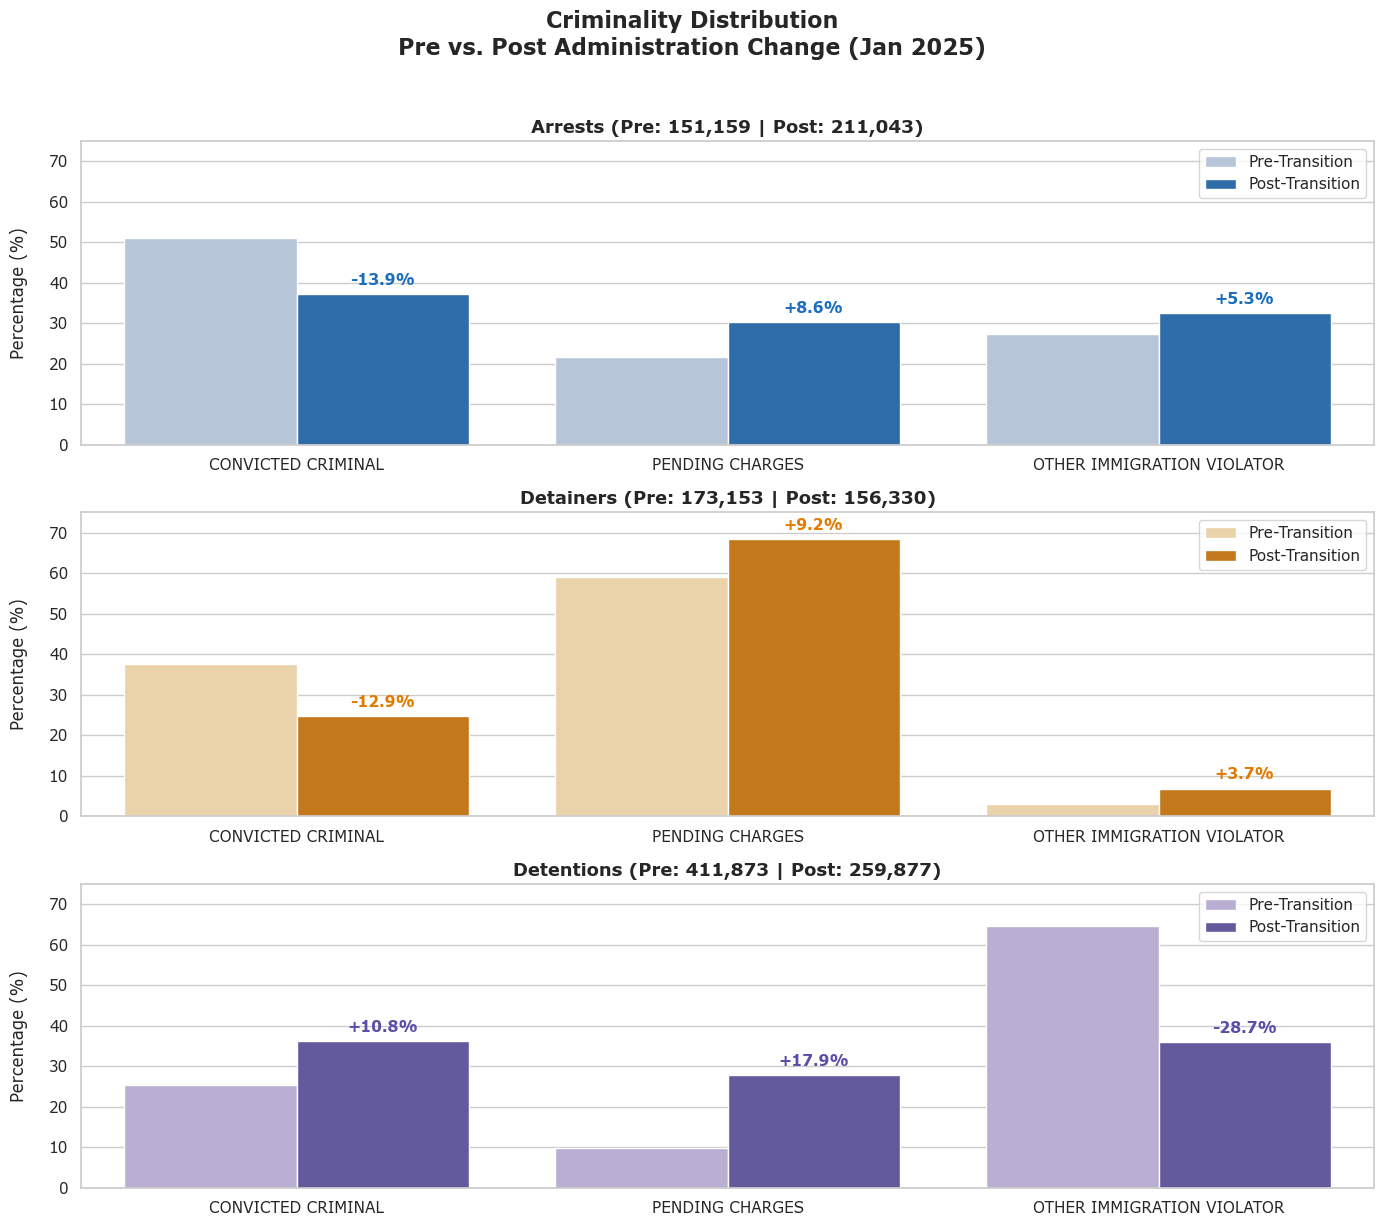

In [45]:
# criminality pre-post comparison chart

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Criminality Distribution\nPre vs. Post Administration Change (Jan 2025)', fontsize=16, fontweight='bold', y=1.02)

# ARRESTS
sns.barplot(
    data=crime_arrests_data,
    x='criminality_clean',
    y='percentage',
    hue='Period',
    hue_order=['Pre-Transition', 'Post-Transition'],
    order=criminality_order,
    palette=['#1b8f8f', '#1A6B6B'],
    ax=ax1
)

ax1.set_title(f'Arrests (Pre: {len(arrests_pre_transition):,} | Post: {len(arrests_post_transition):,})', fontsize=13, fontweight='semibold')
ax1.set_xlabel('')
ax1.set_ylabel('Percentage (%)', labelpad=15)
ax1.set_ylim(0, 75)
ax1.legend(title='')

ax1.text(0.2, convicted_arrests_post + 1.5, f'{convicted_arrests_change:+.1f}%', fontsize=11, fontweight='semibold', color='#1A6B6B', ha='center', va='bottom')
ax1.text(1.2, pending_arrests_post + 1.5, f'{pending_arrests_change:+.1f}%', fontsize=11, fontweight='semibold', color='#1A6B6B', ha='center', va='bottom')
ax1.text(2.2, immigration_arrests_post + 1.5, f'{immigration_arrests_change:+.1f}%', fontsize=11, fontweight='semibold', color='#1A6B6B', ha='center', va='bottom')

# DETAINERS
sns.barplot(
    data=crime_detainers_data,
    x='criminality_clean',
    y='percentage',
    hue='Period',
    hue_order=['Pre-Transition', 'Post-Transition'],
    order=criminality_order,
    palette=['#F5D5A0', '#E07B00'],
    ax=ax2
)

ax2.set_title(f'Detainers (Pre: {len(detainers_pre_transition):,} | Post: {len(detainers_post_transition):,})', fontsize=13, fontweight='semibold')
ax2.set_xlabel('')
ax2.set_ylabel('Percentage (%)', labelpad=15)
ax2.set_ylim(0, 75)
ax2.legend(title='')

ax2.text(0.2, convicted_detainers_post + 1.5, f'{convicted_detainers_change:+.1f}%', fontsize=11, fontweight='semibold', color='#E07B00', ha='center', va='bottom')
ax2.text(1.2, pending_detainers_post + 1.5, f'{pending_detainers_change:+.1f}%', fontsize=11, fontweight='semibold', color='#E07B00', ha='center', va='bottom')
ax2.text(2.2, immigration_detainers_post + 1.5, f'{immigration_detainers_change:+.1f}%', fontsize=11, fontweight='semibold', color='#E07B00', ha='center', va='bottom')

# DETENTIONS
sns.barplot(
    data=crime_detentions_data,
    x='criminality_clean',
    y='percentage',
    hue='Period',
    hue_order=['Pre-Transition', 'Post-Transition'],
    order=criminality_order,
    palette=['#B8A9D9', '#5B4EA8'],
    ax=ax3
)

ax3.set_title(f'Detentions (Pre: {len(detentions_pre_transition):,} | Post: {len(detentions_post_transition):,})', fontsize=13, fontweight='semibold')
ax3.set_xlabel('')
ax3.set_ylabel('Percentage (%)', labelpad=15)
ax3.set_ylim(0, 75)
ax3.legend(title='')

ax3.text(0.2, convicted_detentions_post + 1.5, f'{convicted_detentions_change:+.1f}%', fontsize=11, fontweight='semibold', color='#5B4EA8', ha='center', va='bottom')
ax3.text(1.2, pending_detentions_post + 1.5, f'{pending_detentions_change:+.1f}%', fontsize=11, fontweight='semibold', color='#5B4EA8', ha='center', va='bottom')
ax3.text(2.2, immigration_detentions_post + 1.5, f'{immigration_detentions_change:+.1f}%', fontsize=11, fontweight='semibold', color='#5B4EA8', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## DEEP DIVE ANALYSIS

### --- QUANTIFYING OUTLIERS ---

#### Detention Length Outliers

In [46]:
# calculate IQR and whisker threshold (like those found in a boxplot)
print('='*50)
print('IQR Calculations')
print('='*50)
q1: float = detention_length_not_null['detention_length_days'].quantile(0.25)
q3: float = detention_length_not_null['detention_length_days'].quantile(0.75)
iqr: float = q3 - q1
upper_whisker: float = q3 + 1.5 * iqr

print(f'Q1 (25th Percentile): {q1:.0f} days')
print(f'Q3 (75th Percentile): {q3:.0f} days')
print(f'IQR: {iqr:.0f} days')
print(f'Upper whisker threshold: {upper_whisker:.0f} days')
print()

# filter to outlier records
detention_outliers: DataFrame = detention_length_not_null[detention_length_not_null['detention_length_days'] > upper_whisker]

total_not_null: int = len(detention_length_not_null)
total_outliers: int = len(detention_outliers)

print(f'Total non-null records: {total_not_null:,}')
print(f'Outlier records (>{upper_whisker:.0f} days): {total_outliers:,} ({total_outliers / total_not_null * 100:.1f}%)')
print()

# outliers by criminality category
print('='*50)
print('Outliers by Criminal Category')
print('='*50)
convicted_total: int = len(detention_length_not_null[detention_length_not_null['criminality_clean'] == 'CONVICTED CRIMINAL'])
convicted_outliers: int = len(detention_outliers[detention_outliers['criminality_clean'] == 'CONVICTED CRIMINAL'])
print(f'CONVICTED CRIMINAL:    {convicted_outliers:,} of {convicted_total:,} ({convicted_outliers / convicted_total * 100:.1f}%)')

pending_total: int = len(detention_length_not_null[detention_length_not_null['criminality_clean'] == 'PENDING CHARGES'])
pending_outliers: int = len(detention_outliers[detention_outliers['criminality_clean'] == 'PENDING CHARGES'])
print(f'PENDING CHARGES:    {pending_outliers:,} of {pending_total:,} ({pending_outliers / pending_total * 100:.1f}%)')

immigration_total: int = len(detention_length_not_null[detention_length_not_null['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR'])
immigration_outliers: int = len(detention_outliers[detention_outliers['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR'])
print(f'OTHER IMMIGRATION VIOLATOR:    {immigration_outliers:,} of {immigration_total:,} ({immigration_outliers / immigration_total * 100:.1f}%)')

print('='*50)
print('Extreme Duration Thresholds')
print('='*50)
over_1yr: int = len(detention_length_not_null[detention_length_not_null['detention_length_days'] > 365])
over_2yr: int = len(detention_length_not_null[detention_length_not_null['detention_length_days'] > 730])
over_5yr: int = len(detention_length_not_null[detention_length_not_null['detention_length_days'] > 1825])

print(f'>1 Year (365 Days):    {over_1yr:,} ({over_1yr / total_not_null * 100:.1f}%)')
print(f'>2 Years (730 Days):    {over_2yr:,} ({over_2yr / total_not_null * 100:.1f}%)')
print(f'>5 Years (1,825 Days):    {over_5yr:,} ({over_5yr / total_not_null * 100:.1f}%)')

IQR Calculations
Q1 (25th Percentile): 8 days
Q3 (75th Percentile): 58 days
IQR: 50 days
Upper whisker threshold: 133 days

Total non-null records: 609,849
Outlier records (>133 days): 46,514 (7.6%)

Outliers by Criminal Category
CONVICTED CRIMINAL:    14,388 of 182,003 (7.9%)
PENDING CHARGES:    6,973 of 96,967 (7.2%)
OTHER IMMIGRATION VIOLATOR:    25,153 of 330,879 (7.6%)
Extreme Duration Thresholds
>1 Year (365 Days):    4,359 (0.7%)
>2 Years (730 Days):    375 (0.1%)
>5 Years (1,825 Days):    28 (0.0%)


In [47]:
# Profiling outlier demographics

# top 10 nationalities - outliers vs. overall
print('='*50)
print('Top 10 Nationalities: Outliers vs Overall')
print('='*50)
outlier_countries: DataFrame = detention_outliers['citizenship_country'].value_counts().head(10).reset_index()
outlier_countries.columns = ['citizenship_country', 'outlier_count']

overall_countries: DataFrame = detention_length_not_null['citizenship_country'].value_counts().head(10).reset_index()
overall_countries.columns = ['citizenship_country', 'overall_count']
print(f'{'Country':<25} {'Outliers':>10} {'% of Outliers':>15} {'Overall %:':>12}')
print('='*50)

outlier_total: int = len(detention_outliers)
overall_total: int = len(detention_length_not_null)

mexico_outliers: int = len(detention_outliers[detention_outliers['citizenship_country'] == 'MEXICO'])
mexico_overall: int = len(detention_length_not_null[detention_length_not_null['citizenship_country'] == 'MEXICO'])
print(f'{'MEXICO':<25} {mexico_outliers:>10,} {mexico_outliers / outlier_total * 100:>14.1f}% {mexico_overall / overall_total * 100:>11.1f}%')

guatemala_outliers: int = len(detention_outliers[detention_outliers['citizenship_country'] == 'GUATEMALA'])
guatemala_overall: int = len(detention_length_not_null[detention_length_not_null['citizenship_country'] == 'GUATEMALA'])
print(f'{"GUATEMALA":<25} {guatemala_outliers:>10,} {guatemala_outliers / outlier_total * 100:>14.1f}% {guatemala_overall / overall_total * 100:>11.1f}%')

honduras_outliers: int = len(detention_outliers[detention_outliers['citizenship_country'] == 'HONDURAS'])
honduras_overall: int = len(detention_length_not_null[detention_length_not_null['citizenship_country'] == 'HONDURAS'])
print(f'{"HONDURAS":<25} {honduras_outliers:>10,} {honduras_outliers / outlier_total * 100:>14.1f}% {honduras_overall / overall_total * 100:>11.1f}%')

el_salvador_outliers: int = len(detention_outliers[detention_outliers['citizenship_country'] == 'EL SALVADOR'])
el_salvador_overall: int = len(detention_length_not_null[detention_length_not_null['citizenship_country'] == 'EL SALVADOR'])
print(f'{"EL SALVADOR":<25} {el_salvador_outliers:>10,} {el_salvador_outliers / outlier_total * 100:>14.1f}% {el_salvador_overall / overall_total * 100:>11.1f}%')

cuba_outliers: int = len(detention_outliers[detention_outliers['citizenship_country'] == 'CUBA'])
cuba_overall: int = len(detention_length_not_null[detention_length_not_null['citizenship_country'] == 'CUBA'])
print(f'{"CUBA":<25} {cuba_outliers:>10,} {cuba_outliers / outlier_total * 100:>14.1f}% {cuba_overall / overall_total * 100:>11.1f}%')

india_outliers: int = len(detention_outliers[detention_outliers['citizenship_country'] == 'INDIA'])
india_overall: int = len(detention_length_not_null[detention_length_not_null['citizenship_country'] == 'INDIA'])
print(f'{"INDIA":<25} {india_outliers:>10,} {india_outliers / outlier_total * 100:>14.1f}% {india_overall / overall_total * 100:>11.1f}%')

colombia_outliers: int = len(detention_outliers[detention_outliers['citizenship_country'] == 'COLOMBIA'])
colombia_overall: int = len(detention_length_not_null[detention_length_not_null['citizenship_country'] == 'COLOMBIA'])
print(f'{"COLOMBIA":<25} {colombia_outliers:>10,} {colombia_outliers / outlier_total * 100:>14.1f}% {colombia_overall / overall_total * 100:>11.1f}%')

nicaragua_outliers: int = len(detention_outliers[detention_outliers['citizenship_country'] == 'NICARAGUA'])
nicaragua_overall: int = len(detention_length_not_null[detention_length_not_null['citizenship_country'] == 'NICARAGUA'])
print(f'{"NICARAGUA":<25} {nicaragua_outliers:>10,} {nicaragua_outliers / outlier_total * 100:>14.1f}% {nicaragua_overall / overall_total * 100:>11.1f}%')

ecuador_outliers: int = len(detention_outliers[detention_outliers['citizenship_country'] == 'ECUADOR'])
ecuador_overall: int = len(detention_length_not_null[detention_length_not_null['citizenship_country'] == 'ECUADOR'])
print(f'{"ECUADOR":<25} {ecuador_outliers:>10,} {ecuador_outliers / outlier_total * 100:>14.1f}% {ecuador_overall / overall_total * 100:>11.1f}%')

brazil_outliers: int = len(detention_outliers[detention_outliers['citizenship_country'] == 'BRAZIL'])
brazil_overall: int = len(detention_length_not_null[detention_length_not_null['citizenship_country'] == 'BRAZIL'])
print(f'{"BRAZIL":<25} {brazil_outliers:>10,} {brazil_outliers / outlier_total * 100:>14.1f}% {brazil_overall / overall_total * 100:>11.1f}%')
print()

print('='*50)
print('Gender Breakdown: Outliers vs Overall')
print('='*50)
male_outliers: int = len(detention_outliers[detention_outliers['gender'] == 'MALE'])
female_outliers: int = len(detention_outliers[detention_outliers['gender'] == 'FEMALE'])
unknown_outliers: int = len(detention_outliers[detention_outliers['gender'] == 'UNKNOWN'])

male_overall: int = len(detention_length_not_null[detention_length_not_null['gender'] == 'MALE'])
female_overall: int = len(detention_length_not_null[detention_length_not_null['gender'] == 'FEMALE'])
unknown_overall: int = len(detention_length_not_null[detention_length_not_null['gender'] == 'UNKNOWN'])

print(f'{'Gender':<15} {'% of Outliers':>15} {'% Overall':>12}')
print('='*50)
print(f'{'MALE':<15} {male_outliers / outlier_total * 100:>14.1f}% {male_overall / overall_total * 100:>11.1f}%')
print(f'{'FEMALE':<15} {female_outliers / outlier_total * 100:>14.1f}% {female_overall / overall_total * 100:>11.1f}%')
print(f'{'UNKNOWN':<15} {unknown_outliers / outlier_total * 100:>14.1f}% {unknown_overall / overall_total * 100:>11.1f}%')
print()

print('='*50)
print('Criminality Breakdown: Outliers vs Overall')
print('='*50)
convicted_out_pct: float = convicted_outliers / outlier_total * 100
pending_out_pct: float = pending_outliers / outlier_total * 100
immigration_out_pct: float = immigration_outliers / outlier_total * 100

convicted_all_pct: float = convicted_total / overall_total * 100
pending_all_pct: float = pending_total / overall_total * 100
immigration_all_pct: float = immigration_total / overall_total * 100
print(f'{'Criminality':<30} {'% of Outliers':>15} {'% Overall':>12}')
print('='*50)
print(f'{'CONVICTED CRIMINAL':<30} {convicted_out_pct:>14.1f}% {convicted_all_pct:>11.1f}%')
print(f'{'PENDING CHARGES':<30} {pending_out_pct:>14.1f}% {pending_all_pct:>11.1f}%')
print(f'{'OTHER IMMIGRATION VIOLATOR':<30} {immigration_out_pct:>14.1f}% {immigration_all_pct:>11.1f}%')


Top 10 Nationalities: Outliers vs Overall
Country                     Outliers   % of Outliers   Overall %:
MEXICO                         5,457           11.7%        30.0%
GUATEMALA                      2,536            5.5%        13.1%
HONDURAS                       3,167            6.8%        10.6%
EL SALVADOR                    2,261            4.9%         4.2%
CUBA                           1,242            2.7%         1.4%
INDIA                          2,230            4.8%         2.0%
COLOMBIA                       2,000            4.3%         5.8%
NICARAGUA                      2,056            4.4%         2.9%
ECUADOR                        1,266            2.7%         6.1%
BRAZIL                           664            1.4%         1.3%

Gender Breakdown: Outliers vs Overall
Gender            % of Outliers    % Overall
MALE                      88.1%        84.3%
FEMALE                    11.9%        15.7%
UNKNOWN                    0.0%         0.0%

Criminality 

#### HISTOGRAM CHART: Outlier Distribution

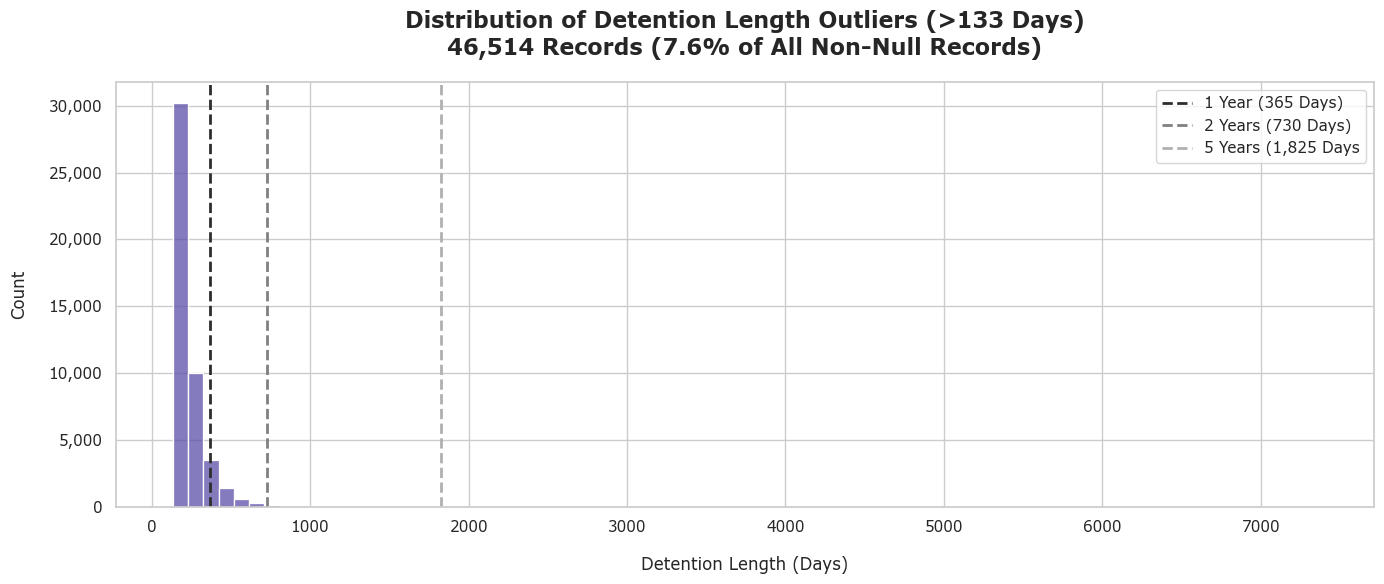

In [48]:
# outlier histogram

fig, ax = plt.subplots(figsize=(14, 6))

sns.histplot(
    data=detention_outliers,
    x='detention_length_days',
    bins=75,
    color='#5B4EA8',
    ax=ax
)

ax.axvline(x=365, color='#2D2D2D', linewidth=2, linestyle='--', label='1 Year (365 Days)')
ax.axvline(x=730, color='#808080', linewidth=2, linestyle='--', label='2 Years (730 Days)')
ax.axvline(x=1825, color='#B0B0B0', linewidth=2, linestyle='--', label='5 Years (1,825 Days')

ax.set_title(f'Distribution of Detention Length Outliers (>{upper_whisker:.0f} Days)\n{len(detention_outliers):,} Records ({len(detention_outliers) / len(detention_length_not_null) * 100:.1f}% of All Non-Null Records)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Detention Length (Days)', labelpad=15)
ax.set_ylabel('Count', labelpad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # noqa
ax.legend()

plt.tight_layout()
plt.show()


#### Extreme Values Analysis

In [49]:
# records over 1 year
over_1yr_records: DataFrame = detention_length_not_null[detention_length_not_null['detention_length_days'] > 365]
print('='*50)
print(f'Records Over 1 Year: {len(over_1yr_records):,}')

# top 20 longest stays
print('='*50)
print('Top 20 Longest Detention Stays')
print('='*50)
top_20: DataFrame = detention_length_not_null.nlargest(20, 'detention_length_days')[['detention_length_days', 'citizenship_country', 'gender', 'criminality_clean', 'age', 'stay_book_in_date_time']].reset_index(drop=True)
print(top_20.to_string())
print()

# nationality breakdown from >1 year records
print('='*50)
print('Nationality Breakdown: >1 Year Records')
print('='*50)
print(over_1yr_records['citizenship_country'].value_counts().head(10).to_string())
print()

# criminality breakdown for >1 year records
print('='*50)
print('Criminality Breakdown: >1 Year Records')
print('='*50)
print(over_1yr_records['criminality_clean'].value_counts().to_string())
print()

# gender breakdown for >1 year records
print('='*50)
print('Gender Breakdown for >1 Year Records')
print('='*50)
print(over_1yr_records['gender'].value_counts().to_string())


Records Over 1 Year: 4,359
Top 20 Longest Detention Stays
    detention_length_days         citizenship_country  gender           criminality_clean  age stay_book_in_date_time
0                  7354.0                      BRAZIL    MALE  OTHER IMMIGRATION VIOLATOR   52    2004-12-05 22:30:00
1                  4138.0                      MEXICO    MALE          CONVICTED CRIMINAL   41    2014-04-09 18:20:00
2                  4128.0                      MEXICO    MALE          CONVICTED CRIMINAL   39    2014-06-19 07:07:00
3                  4070.0                   GUATEMALA    MALE  OTHER IMMIGRATION VIOLATOR   37    2014-07-13 10:02:00
4                  4039.0                      MEXICO    MALE          CONVICTED CRIMINAL   37    2014-01-17 13:18:00
5                  3639.0                       INDIA    MALE  OTHER IMMIGRATION VIOLATOR   35    2014-02-25 19:43:00
6                  3065.0                      MEXICO    MALE          CONVICTED CRIMINAL   51    2016-10-18 13:41:0

In [50]:
# ── Equal-window pre-post split for deep-dive analysis (9 months each) ──

# pre: Apr 20, 2024 → Jan 20, 2025 (9 months)
# post: Jan 20, 2025 → Oct 20, 2025 (9 months)
deep_dive_pre_start: pd.Timestamp = pd.Timestamp('2024-04-20')
deep_dive_pre_end: pd.Timestamp = pd.Timestamp('2025-01-20')
deep_dive_post_end: pd.Timestamp = pd.Timestamp('2025-10-20')

# filter detention records with valid length to equal windows
dd_pre: DataFrame = detention_length_not_null[
    (detention_length_not_null['stay_book_in_date_time'] >= deep_dive_pre_start) &
    (detention_length_not_null['stay_book_in_date_time'] < deep_dive_pre_end)
]

dd_post: DataFrame = detention_length_not_null[
    (detention_length_not_null['stay_book_in_date_time'] >= deep_dive_pre_end) &
    (detention_length_not_null['stay_book_in_date_time'] < deep_dive_post_end)
]
print('='*50)
print('Deep-Dive Equal Windows (9 Months Each)')
print('='*50)
print(f'Pre-Transition:  {deep_dive_pre_start.strftime("%b %d, %Y")} → {deep_dive_pre_end.strftime("%b %d, %Y")} | {len(dd_pre):,} records')
print(f'Post-Transition: {deep_dive_pre_end.strftime("%b %d, %Y")} → {deep_dive_post_end.strftime("%b %d, %Y")} | {len(dd_post):,} records')

Deep-Dive Equal Windows (9 Months Each)
Pre-Transition:  Apr 20, 2024 → Jan 20, 2025 | 204,583 records
Post-Transition: Jan 20, 2025 → Oct 20, 2025 | 203,962 records


In [51]:
# Pre-post outlier rate comparison (equal 9-month windows)

# outliers within each equal window
dd_outliers_pre: DataFrame = dd_pre[dd_pre['detention_length_days'] > upper_whisker]
dd_outliers_post: DataFrame = dd_post[dd_post['detention_length_days'] > upper_whisker]

dd_pre_rate: float = len(dd_outliers_pre) / len(dd_pre) * 100
dd_post_rate: float = len(dd_outliers_post) / len(dd_post) * 100

print('='*50)
print('Outlier Rate: Pre vs Post (Equal 9-Month Windows)')
print('='*50)
print(f'Pre-Transition:  {len(dd_outliers_pre):,} outliers of {len(dd_pre):,} records ({dd_pre_rate:.1f}%)')
print(f'Post-Transition: {len(dd_outliers_post):,} outliers of {len(dd_post):,} records ({dd_post_rate:.1f}%)')
print(f'Change: {dd_post_rate - dd_pre_rate:+.1f} percentage points')
print()

# criminality breakdown
print('='*50)
print('Outlier Rate by Criminality: Pre vs Post (Equal Windows)')
print('='*50)
print(f'{"Category":<30} {"Pre Rate":>10} {"Post Rate":>11} {"Change":>10}')
print('=' * 50)

dd_conv_pre_total: int = len(dd_pre[dd_pre['criminality_clean'] == 'CONVICTED CRIMINAL'])
dd_conv_pre_out: int = len(dd_outliers_pre[dd_outliers_pre['criminality_clean'] == 'CONVICTED CRIMINAL'])
dd_conv_pre_rate: float = dd_conv_pre_out / dd_conv_pre_total * 100

dd_conv_post_total: int = len(dd_post[dd_post['criminality_clean'] == 'CONVICTED CRIMINAL'])
dd_conv_post_out: int = len(dd_outliers_post[dd_outliers_post['criminality_clean'] == 'CONVICTED CRIMINAL'])
dd_conv_post_rate: float = dd_conv_post_out / dd_conv_post_total * 100

print(f'{"CONVICTED CRIMINAL":<30} {dd_conv_pre_rate:>9.1f}% {dd_conv_post_rate:>10.1f}% {dd_conv_post_rate - dd_conv_pre_rate:>+9.1f}%')

dd_pend_pre_total: int = len(dd_pre[dd_pre['criminality_clean'] == 'PENDING CHARGES'])
dd_pend_pre_out: int = len(dd_outliers_pre[dd_outliers_pre['criminality_clean'] == 'PENDING CHARGES'])
dd_pend_pre_rate: float = dd_pend_pre_out / dd_pend_pre_total * 100

dd_pend_post_total: int = len(dd_post[dd_post['criminality_clean'] == 'PENDING CHARGES'])
dd_pend_post_out: int = len(dd_outliers_post[dd_outliers_post['criminality_clean'] == 'PENDING CHARGES'])
dd_pend_post_rate: float = dd_pend_post_out / dd_pend_post_total * 100

print(f'{"PENDING CHARGES":<30} {dd_pend_pre_rate:>9.1f}% {dd_pend_post_rate:>10.1f}% {dd_pend_post_rate - dd_pend_pre_rate:>+9.1f}%')

dd_imm_pre_total: int = len(dd_pre[dd_pre['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR'])
dd_imm_pre_out: int = len(dd_outliers_pre[dd_outliers_pre['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR'])
dd_imm_pre_rate: float = dd_imm_pre_out / dd_imm_pre_total * 100

dd_imm_post_total: int = len(dd_post[dd_post['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR'])
dd_imm_post_out: int = len(dd_outliers_post[dd_outliers_post['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR'])
dd_imm_post_rate: float = dd_imm_post_out / dd_imm_post_total * 100

print(f'{"OTHER IMMIGRATION VIOLATOR":<30} {dd_imm_pre_rate:>9.1f}% {dd_imm_post_rate:>10.1f}% {dd_imm_post_rate - dd_imm_pre_rate:>+9.1f}%')


Outlier Rate: Pre vs Post (Equal 9-Month Windows)
Pre-Transition:  18,015 outliers of 204,583 records (8.8%)
Post-Transition: 5,312 outliers of 203,962 records (2.6%)
Change: -6.2 percentage points

Outlier Rate by Criminality: Pre vs Post (Equal Windows)
Category                         Pre Rate   Post Rate     Change
CONVICTED CRIMINAL                   8.6%        2.4%      -6.2%
PENDING CHARGES                     11.2%        3.1%      -8.1%
OTHER IMMIGRATION VIOLATOR           8.4%        2.4%      -6.0%


### --- CRIMINALITY VS DETENTION LENGTH ---

#### Breakdown

In [52]:
# Criminality × Detention Length — detailed breakdown

# summary stats per criminality category (all non-null records)
print('=' * 50)
print('Detention Length by Criminality: Summary Statistics')
print('=' * 50)
print(f'{"Category":<30} {"Count":>8} {"Mean":>8} {"Median":>8} {"P25":>6} {"P75":>6} {"P90":>6} {"P99":>6}')


convicted_stays: DataFrame = detention_length_not_null[detention_length_not_null['criminality_clean'] == 'CONVICTED CRIMINAL']
print(f'{"CONVICTED CRIMINAL":<30} {len(convicted_stays):>8,} {convicted_stays["detention_length_days"].mean():>8.1f} {convicted_stays["detention_length_days"].median():>8.0f} {convicted_stays["detention_length_days"].quantile(0.25):>6.0f} {convicted_stays["detention_length_days"].quantile(0.75):>6.0f} {convicted_stays["detention_length_days"].quantile(0.90):>6.0f} {convicted_stays["detention_length_days"].quantile(0.99):>6.0f}')

pending_stays: DataFrame = detention_length_not_null[detention_length_not_null['criminality_clean'] == 'PENDING CHARGES']
print(f'{"PENDING CHARGES":<30} {len(pending_stays):>8,} {pending_stays["detention_length_days"].mean():>8.1f} {pending_stays["detention_length_days"].median():>8.0f} {pending_stays["detention_length_days"].quantile(0.25):>6.0f} {pending_stays["detention_length_days"].quantile(0.75):>6.0f} {pending_stays["detention_length_days"].quantile(0.90):>6.0f} {pending_stays["detention_length_days"].quantile(0.99):>6.0f}')

immigration_stays: DataFrame = detention_length_not_null[detention_length_not_null['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']
print(f'{"OTHER IMMIGRATION VIOLATOR":<30} {len(immigration_stays):>8,} {immigration_stays["detention_length_days"].mean():>8.1f} {immigration_stays["detention_length_days"].median():>8.0f} {immigration_stays["detention_length_days"].quantile(0.25):>6.0f} {immigration_stays["detention_length_days"].quantile(0.75):>6.0f} {immigration_stays["detention_length_days"].quantile(0.90):>6.0f} {immigration_stays["detention_length_days"].quantile(0.99):>6.0f}')

print()

# pre-post comparison per criminality (equal 9-month windows)
print('=' * 50)
print('Median Detention Length by Criminality: Pre vs Post (Equal Windows)')
print('=' * 50)
print(f'{"Category":<30} {"Pre Median":>12} {"Post Median":>13} {"Change":>10}')

convicted_pre_med: float = dd_pre[dd_pre['criminality_clean'] == 'CONVICTED CRIMINAL']['detention_length_days'].median()
convicted_post_med: float = dd_post[dd_post['criminality_clean'] == 'CONVICTED CRIMINAL']['detention_length_days'].median()
print(f'{"CONVICTED CRIMINAL":<30} {convicted_pre_med:>11.0f}d {convicted_post_med:>12.0f}d {convicted_post_med - convicted_pre_med:>+9.0f}d')

pending_pre_med: float = dd_pre[dd_pre['criminality_clean'] == 'PENDING CHARGES']['detention_length_days'].median()
pending_post_med: float = dd_post[dd_post['criminality_clean'] == 'PENDING CHARGES']['detention_length_days'].median()
print(f'{"PENDING CHARGES":<30} {pending_pre_med:>11.0f}d {pending_post_med:>12.0f}d {pending_post_med - pending_pre_med:>+9.0f}d')

immigration_pre_med: float = dd_pre[dd_pre['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']['detention_length_days'].median()
immigration_post_med: float = dd_post[dd_post['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']['detention_length_days'].median()
print(f'{"OTHER IMMIGRATION VIOLATOR":<30} {immigration_pre_med:>11.0f}d {immigration_post_med:>12.0f}d {immigration_post_med - immigration_pre_med:>+9.0f}d')


Detention Length by Criminality: Summary Statistics
Category                          Count     Mean   Median    P25    P75    P90    P99
CONVICTED CRIMINAL              182,003     44.7       19      3     50    112    383
PENDING CHARGES                  96,967     47.8       30     10     62    113    281
OTHER IMMIGRATION VIOLATOR      330,879     49.1       31     11     60    112    315

Median Detention Length by Criminality: Pre vs Post (Equal Windows)
Category                         Pre Median   Post Median     Change
CONVICTED CRIMINAL                      21d           13d        -8d
PENDING CHARGES                         34d           27d        -7d
OTHER IMMIGRATION VIOLATOR              30d           21d        -9d


### --- AGE VS DETENTION LENGTH ---

#### Breakdown

In [53]:
# Age vs. Detention Length — binned analysis

# median detention length by age bucket
print('Median Detention Length by Age Bucket')
print(f'{"Age Bucket":<15} {"Count":>10} {"Median":>10} {"Mean":>10}')
print('=' * 50)

bucket_1_10: DataFrame = detention_length_not_null[(detention_length_not_null['age'] >= 1) & (detention_length_not_null['age'] <= 10)]
print(f'{"1-10":<15} {len(bucket_1_10):>10,} {bucket_1_10["detention_length_days"].median():>10.0f} {bucket_1_10["detention_length_days"].mean():>10.1f}')

bucket_11_18: DataFrame = detention_length_not_null[(detention_length_not_null['age'] >= 11) & (detention_length_not_null['age'] <= 18)]
print(f'{"11-18":<15} {len(bucket_11_18):>10,} {bucket_11_18["detention_length_days"].median():>10.0f} {bucket_11_18["detention_length_days"].mean():>10.1f}')

bucket_19_30: DataFrame = detention_length_not_null[(detention_length_not_null['age'] >= 19) & (detention_length_not_null['age'] <= 30)]
print(f'{"19-30":<15} {len(bucket_19_30):>10,} {bucket_19_30["detention_length_days"].median():>10.0f} {bucket_19_30["detention_length_days"].mean():>10.1f}')

bucket_31_40: DataFrame = detention_length_not_null[(detention_length_not_null['age'] >= 31) & (detention_length_not_null['age'] <= 40)]
print(f'{"31-40":<15} {len(bucket_31_40):>10,} {bucket_31_40["detention_length_days"].median():>10.0f} {bucket_31_40["detention_length_days"].mean():>10.1f}')

bucket_41_50: DataFrame = detention_length_not_null[(detention_length_not_null['age'] >= 41) & (detention_length_not_null['age'] <= 50)]
print(f'{"41-50":<15} {len(bucket_41_50):>10,} {bucket_41_50["detention_length_days"].median():>10.0f} {bucket_41_50["detention_length_days"].mean():>10.1f}')

bucket_51_60: DataFrame = detention_length_not_null[(detention_length_not_null['age'] >= 51) & (detention_length_not_null['age'] <= 60)]
print(f'{"51-60":<15} {len(bucket_51_60):>10,} {bucket_51_60["detention_length_days"].median():>10.0f} {bucket_51_60["detention_length_days"].mean():>10.1f}')

bucket_61_70: DataFrame = detention_length_not_null[(detention_length_not_null['age'] >= 61) & (detention_length_not_null['age'] <= 70)]
print(f'{"61-70":<15} {len(bucket_61_70):>10,} {bucket_61_70["detention_length_days"].median():>10.0f} {bucket_61_70["detention_length_days"].mean():>10.1f}')

bucket_71_plus: DataFrame = detention_length_not_null[detention_length_not_null['age'] >= 71]
print(f'{"71+":<15} {len(bucket_71_plus):>10,} {bucket_71_plus["detention_length_days"].median():>10.0f} {bucket_71_plus["detention_length_days"].mean():>10.1f}')


Median Detention Length by Age Bucket
Age Bucket           Count     Median       Mean
1-10                 5,164          1        7.5
11-18                6,052          4       15.6
19-30              227,897         29       46.9
31-40              200,876         28       49.1
41-50              117,021         26       48.3
51-60               42,877         26       50.0
61-70                8,995         29       53.8
71+                    967         27       62.2


### --- AGE VS CRIMINALITY ---

#### Breakdown

In [54]:
# Age vs. Criminality — cross-tab
print('='*50)
print('Criminality Distribution by Age Bucket')
print(f'{"Age Bucket":<15} {"Convicted":>12} {"Pending":>12} {"Immigration":>14} {"Count":>10}')
print('=' * 50)

bucket_1_10_total: int = len(bucket_1_10[bucket_1_10['criminality_clean'].notna()])
bucket_1_10_conv: float = len(bucket_1_10[bucket_1_10['criminality_clean'] == 'CONVICTED CRIMINAL']) / bucket_1_10_total * 100 if bucket_1_10_total > 0 else 0
bucket_1_10_pend: float = len(bucket_1_10[bucket_1_10['criminality_clean'] == 'PENDING CHARGES']) / bucket_1_10_total * 100 if bucket_1_10_total > 0 else 0
bucket_1_10_imm: float = len(bucket_1_10[bucket_1_10['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / bucket_1_10_total * 100 if bucket_1_10_total > 0 else 0
print(f'{"1-10":<15} {bucket_1_10_conv:>11.1f}% {bucket_1_10_pend:>11.1f}% {bucket_1_10_imm:>13.1f}% {bucket_1_10_total:>10,}')

bucket_11_18_total: int = len(bucket_11_18[bucket_11_18['criminality_clean'].notna()])
bucket_11_18_conv: float = len(bucket_11_18[bucket_11_18['criminality_clean'] == 'CONVICTED CRIMINAL']) / bucket_11_18_total * 100 if bucket_11_18_total > 0 else 0
bucket_11_18_pend: float = len(bucket_11_18[bucket_11_18['criminality_clean'] == 'PENDING CHARGES']) / bucket_11_18_total * 100 if bucket_11_18_total > 0 else 0
bucket_11_18_imm: float = len(bucket_11_18[bucket_11_18['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / bucket_11_18_total * 100 if bucket_11_18_total > 0 else 0
print(f'{"11-18":<15} {bucket_11_18_conv:>11.1f}% {bucket_11_18_pend:>11.1f}% {bucket_11_18_imm:>13.1f}% {bucket_11_18_total:>10,}')

bucket_19_30_total: int = len(bucket_19_30[bucket_19_30['criminality_clean'].notna()])
bucket_19_30_conv: float = len(bucket_19_30[bucket_19_30['criminality_clean'] == 'CONVICTED CRIMINAL']) / bucket_19_30_total * 100 if bucket_19_30_total > 0 else 0
bucket_19_30_pend: float = len(bucket_19_30[bucket_19_30['criminality_clean'] == 'PENDING CHARGES']) / bucket_19_30_total * 100 if bucket_19_30_total > 0 else 0
bucket_19_30_imm: float = len(bucket_19_30[bucket_19_30['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / bucket_19_30_total * 100 if bucket_19_30_total > 0 else 0
print(f'{"19-30":<15} {bucket_19_30_conv:>11.1f}% {bucket_19_30_pend:>11.1f}% {bucket_19_30_imm:>13.1f}% {bucket_19_30_total:>10,}')

bucket_31_40_total: int = len(bucket_31_40[bucket_31_40['criminality_clean'].notna()])
bucket_31_40_conv: float = len(bucket_31_40[bucket_31_40['criminality_clean'] == 'CONVICTED CRIMINAL']) / bucket_31_40_total * 100 if bucket_31_40_total > 0 else 0
bucket_31_40_pend: float = len(bucket_31_40[bucket_31_40['criminality_clean'] == 'PENDING CHARGES']) / bucket_31_40_total * 100 if bucket_31_40_total > 0 else 0
bucket_31_40_imm: float = len(bucket_31_40[bucket_31_40['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / bucket_31_40_total * 100 if bucket_31_40_total > 0 else 0
print(f'{"31-40":<15} {bucket_31_40_conv:>11.1f}% {bucket_31_40_pend:>11.1f}% {bucket_31_40_imm:>13.1f}% {bucket_31_40_total:>10,}')

bucket_41_50_total: int = len(bucket_41_50[bucket_41_50['criminality_clean'].notna()])
bucket_41_50_conv: float = len(bucket_41_50[bucket_41_50['criminality_clean'] == 'CONVICTED CRIMINAL']) / bucket_41_50_total * 100 if bucket_41_50_total > 0 else 0
bucket_41_50_pend: float = len(bucket_41_50[bucket_41_50['criminality_clean'] == 'PENDING CHARGES']) / bucket_41_50_total * 100 if bucket_41_50_total > 0 else 0
bucket_41_50_imm: float = len(bucket_41_50[bucket_41_50['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / bucket_41_50_total * 100 if bucket_41_50_total > 0 else 0
print(f'{"41-50":<15} {bucket_41_50_conv:>11.1f}% {bucket_41_50_pend:>11.1f}% {bucket_41_50_imm:>13.1f}% {bucket_41_50_total:>10,}')

bucket_51_60_total: int = len(bucket_51_60[bucket_51_60['criminality_clean'].notna()])
bucket_51_60_conv: float = len(bucket_51_60[bucket_51_60['criminality_clean'] == 'CONVICTED CRIMINAL']) / bucket_51_60_total * 100 if bucket_51_60_total > 0 else 0
bucket_51_60_pend: float = len(bucket_51_60[bucket_51_60['criminality_clean'] == 'PENDING CHARGES']) / bucket_51_60_total * 100 if bucket_51_60_total > 0 else 0
bucket_51_60_imm: float = len(bucket_51_60[bucket_51_60['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / bucket_51_60_total * 100 if bucket_51_60_total > 0 else 0
print(f'{"51-60":<15} {bucket_51_60_conv:>11.1f}% {bucket_51_60_pend:>11.1f}% {bucket_51_60_imm:>13.1f}% {bucket_51_60_total:>10,}')

bucket_61_70_total: int = len(bucket_61_70[bucket_61_70['criminality_clean'].notna()])
bucket_61_70_conv: float = len(bucket_61_70[bucket_61_70['criminality_clean'] == 'CONVICTED CRIMINAL']) / bucket_61_70_total * 100 if bucket_61_70_total > 0 else 0
bucket_61_70_pend: float = len(bucket_61_70[bucket_61_70['criminality_clean'] == 'PENDING CHARGES']) / bucket_61_70_total * 100 if bucket_61_70_total > 0 else 0
bucket_61_70_imm: float = len(bucket_61_70[bucket_61_70['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / bucket_61_70_total * 100 if bucket_61_70_total > 0 else 0
print(f'{"61-70":<15} {bucket_61_70_conv:>11.1f}% {bucket_61_70_pend:>11.1f}% {bucket_61_70_imm:>13.1f}% {bucket_61_70_total:>10,}')

bucket_71_plus_total: int = len(bucket_71_plus[bucket_71_plus['criminality_clean'].notna()])
bucket_71_plus_conv: float = len(bucket_71_plus[bucket_71_plus['criminality_clean'] == 'CONVICTED CRIMINAL']) / bucket_71_plus_total * 100 if bucket_71_plus_total > 0 else 0
bucket_71_plus_pend: float = len(bucket_71_plus[bucket_71_plus['criminality_clean'] == 'PENDING CHARGES']) / bucket_71_plus_total * 100 if bucket_71_plus_total > 0 else 0
bucket_71_plus_imm: float = len(bucket_71_plus[bucket_71_plus['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / bucket_71_plus_total * 100 if bucket_71_plus_total > 0 else 0
print(f'{"71+":<15} {bucket_71_plus_conv:>11.1f}% {bucket_71_plus_pend:>11.1f}% {bucket_71_plus_imm:>13.1f}% {bucket_71_plus_total:>10,}')


Criminality Distribution by Age Bucket
Age Bucket         Convicted      Pending    Immigration      Count
1-10                    0.1%         0.1%          99.8%      5,164
11-18                   0.3%         1.0%          98.6%      6,052
19-30                  17.7%        18.1%          64.2%    227,897
31-40                  31.8%        17.0%          51.3%    200,876
41-50                  43.8%        13.7%          42.5%    117,021
51-60                  48.6%        11.1%          40.3%     42,877
61-70                  55.4%         8.8%          35.8%      8,995
71+                    71.6%         6.2%          22.2%        967


In [55]:
# Age × Detention Length Pre vs. Post (Equal Windows)

print('Median Detention Length by Age: Pre vs Post (Equal Windows)')
print(f'{"Age Bucket":<15} {"Pre Median":>12} {"Post Median":>13} {"Change":>10}')
print('=' * 55)

bucket_19_30_pre_med: float = dd_pre[(dd_pre['age'] >= 19) & (dd_pre['age'] <= 30)]['detention_length_days'].median()
bucket_19_30_post_med: float = dd_post[(dd_post['age'] >= 19) & (dd_post['age'] <= 30)]['detention_length_days'].median()
print(f'{"19-30":<15} {bucket_19_30_pre_med:>11.0f}d {bucket_19_30_post_med:>12.0f}d {bucket_19_30_post_med - bucket_19_30_pre_med:>+9.0f}d')

bucket_31_40_pre_med: float = dd_pre[(dd_pre['age'] >= 31) & (dd_pre['age'] <= 40)]['detention_length_days'].median()
bucket_31_40_post_med: float = dd_post[(dd_post['age'] >= 31) & (dd_post['age'] <= 40)]['detention_length_days'].median()
print(f'{"31-40":<15} {bucket_31_40_pre_med:>11.0f}d {bucket_31_40_post_med:>12.0f}d {bucket_31_40_post_med - bucket_31_40_pre_med:>+9.0f}d')

bucket_41_50_pre_med: float = dd_pre[(dd_pre['age'] >= 41) & (dd_pre['age'] <= 50)]['detention_length_days'].median()
bucket_41_50_post_med: float = dd_post[(dd_post['age'] >= 41) & (dd_post['age'] <= 50)]['detention_length_days'].median()
print(f'{"41-50":<15} {bucket_41_50_pre_med:>11.0f}d {bucket_41_50_post_med:>12.0f}d {bucket_41_50_post_med - bucket_41_50_pre_med:>+9.0f}d')

bucket_51_60_pre_med: float = dd_pre[(dd_pre['age'] >= 51) & (dd_pre['age'] <= 60)]['detention_length_days'].median()
bucket_51_60_post_med: float = dd_post[(dd_post['age'] >= 51) & (dd_post['age'] <= 60)]['detention_length_days'].median()
print(f'{"51-60":<15} {bucket_51_60_pre_med:>11.0f}d {bucket_51_60_post_med:>12.0f}d {bucket_51_60_post_med - bucket_51_60_pre_med:>+9.0f}d')

bucket_61_plus_pre_med: float = dd_pre[dd_pre['age'] >= 61]['detention_length_days'].median()
bucket_61_plus_post_med: float = dd_post[dd_post['age'] >= 61]['detention_length_days'].median()
print(f'{"61+":<15} {bucket_61_plus_pre_med:>11.0f}d {bucket_61_plus_post_med:>12.0f}d {bucket_61_plus_post_med - bucket_61_plus_pre_med:>+9.0f}d')


Median Detention Length by Age: Pre vs Post (Equal Windows)
Age Bucket        Pre Median   Post Median     Change
19-30                    30d           21d        -9d
31-40                    29d           20d        -9d
41-50                    27d           17d       -10d
51-60                    28d           17d       -11d
61+                      29d           21d        -8d


In [56]:
# Criminality Distribution by Age pre-post trump

# focusing on convicted criminal rate by age, pre vs. post
print('Convicted Criminal Rate by Age: Pre vs Post Transition')
print(f'{"Age Bucket":<15} {"Pre Conv%":>12} {"Post Conv%":>13} {"Change":>10}')
print('=' * 50)

age_19_30_pre: DataFrame = arrests_pre_transition[(arrests_pre_transition['age'] >= 19) & (arrests_pre_transition['age'] <= 30)]
age_19_30_pre_total: int = len(age_19_30_pre[age_19_30_pre['criminality_clean'].notna()])
age_19_30_pre_conv: float = len(age_19_30_pre[age_19_30_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / age_19_30_pre_total * 100
age_19_30_post: DataFrame = arrests_post_transition[(arrests_post_transition['age'] >= 19) & (arrests_post_transition['age'] <= 30)]
age_19_30_post_total: int = len(age_19_30_post[age_19_30_post['criminality_clean'].notna()])
age_19_30_post_conv: float = len(age_19_30_post[age_19_30_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / age_19_30_post_total * 100
print(f'{"19-30":<15} {age_19_30_pre_conv:>11.1f}% {age_19_30_post_conv:>12.1f}% {age_19_30_post_conv - age_19_30_pre_conv:>+9.1f}%')

age_31_40_pre: DataFrame = arrests_pre_transition[(arrests_pre_transition['age'] >= 31) & (arrests_pre_transition['age'] <= 40)]
age_31_40_pre_total: int = len(age_31_40_pre[age_31_40_pre['criminality_clean'].notna()])
age_31_40_pre_conv: float = len(age_31_40_pre[age_31_40_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / age_31_40_pre_total * 100
age_31_40_post: DataFrame = arrests_post_transition[(arrests_post_transition['age'] >= 31) & (arrests_post_transition['age'] <= 40)]
age_31_40_post_total: int = len(age_31_40_post[age_31_40_post['criminality_clean'].notna()])
age_31_40_post_conv: float = len(age_31_40_post[age_31_40_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / age_31_40_post_total * 100
print(f'{"31-40":<15} {age_31_40_pre_conv:>11.1f}% {age_31_40_post_conv:>12.1f}% {age_31_40_post_conv - age_31_40_pre_conv:>+9.1f}%')

age_41_50_pre: DataFrame = arrests_pre_transition[(arrests_pre_transition['age'] >= 41) & (arrests_pre_transition['age'] <= 50)]
age_41_50_pre_total: int = len(age_41_50_pre[age_41_50_pre['criminality_clean'].notna()])
age_41_50_pre_conv: float = len(age_41_50_pre[age_41_50_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / age_41_50_pre_total * 100
age_41_50_post: DataFrame = arrests_post_transition[(arrests_post_transition['age'] >= 41) & (arrests_post_transition['age'] <= 50)]
age_41_50_post_total: int = len(age_41_50_post[age_41_50_post['criminality_clean'].notna()])
age_41_50_post_conv: float = len(age_41_50_post[age_41_50_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / age_41_50_post_total * 100
print(f'{"41-50":<15} {age_41_50_pre_conv:>11.1f}% {age_41_50_post_conv:>12.1f}% {age_41_50_post_conv - age_41_50_pre_conv:>+9.1f}%')

age_51_60_pre: DataFrame = arrests_pre_transition[(arrests_pre_transition['age'] >= 51) & (arrests_pre_transition['age'] <= 60)]
age_51_60_pre_total: int = len(age_51_60_pre[age_51_60_pre['criminality_clean'].notna()])
age_51_60_pre_conv: float = len(age_51_60_pre[age_51_60_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / age_51_60_pre_total * 100
age_51_60_post: DataFrame = arrests_post_transition[(arrests_post_transition['age'] >= 51) & (arrests_post_transition['age'] <= 60)]
age_51_60_post_total: int = len(age_51_60_post[age_51_60_post['criminality_clean'].notna()])
age_51_60_post_conv: float = len(age_51_60_post[age_51_60_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / age_51_60_post_total * 100
print(f'{"51-60":<15} {age_51_60_pre_conv:>11.1f}% {age_51_60_post_conv:>12.1f}% {age_51_60_post_conv - age_51_60_pre_conv:>+9.1f}%')

age_61_plus_pre: DataFrame = arrests_pre_transition[arrests_pre_transition['age'] >= 61]
age_61_plus_pre_total: int = len(age_61_plus_pre[age_61_plus_pre['criminality_clean'].notna()])
age_61_plus_pre_conv: float = len(age_61_plus_pre[age_61_plus_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / age_61_plus_pre_total * 100
age_61_plus_post: DataFrame = arrests_post_transition[arrests_post_transition['age'] >= 61]
age_61_plus_post_total: int = len(age_61_plus_post[age_61_plus_post['criminality_clean'].notna()])
age_61_plus_post_conv: float = len(age_61_plus_post[age_61_plus_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / age_61_plus_post_total * 100
print(f'{"61+":<15} {age_61_plus_pre_conv:>11.1f}% {age_61_plus_post_conv:>12.1f}% {age_61_plus_post_conv - age_61_plus_pre_conv:>+9.1f}%')


Convicted Criminal Rate by Age: Pre vs Post Transition
Age Bucket         Pre Conv%    Post Conv%     Change
19-30                  36.1%         25.5%     -10.6%
31-40                  53.0%         38.3%     -14.7%
41-50                  66.4%         47.2%     -19.2%
51-60                  73.6%         53.0%     -20.6%
61+                    79.3%         58.8%     -20.5%


### --- CROSS-TABULATIONS ---

#### Nationality vs. Criminality

In [57]:
# Nationality vs. Criminality cross-tab

# top 10 countries by volume in detentions
top_10_countries: list[str] = detention_length_not_null['citizenship_country'].value_counts().head(10).index.tolist()
print('=' * 50)
print('Criminality Distribution by Top 10 Nationalities')
print(f'{"Country":<25} {"Convicted":>12} {"Pending":>12} {"Immigration":>14} {"Count":>10}')
print('=' * 50)

mexico_records: DataFrame = detention_length_not_null[detention_length_not_null['citizenship_country'] == 'MEXICO']
mexico_total: int = len(mexico_records[mexico_records['criminality_clean'].notna()])
mexico_conv: float = len(mexico_records[mexico_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / mexico_total * 100
mexico_pend: float = len(mexico_records[mexico_records['criminality_clean'] == 'PENDING CHARGES']) / mexico_total * 100
mexico_imm: float = len(mexico_records[mexico_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / mexico_total * 100
print(f'{"MEXICO":<25} {mexico_conv:>11.1f}% {mexico_pend:>11.1f}% {mexico_imm:>13.1f}% {mexico_total:>10,}')

guatemala_records: DataFrame = detention_length_not_null[detention_length_not_null['citizenship_country'] == 'GUATEMALA']
guatemala_total: int = len(guatemala_records[guatemala_records['criminality_clean'].notna()])
guatemala_conv: float = len(guatemala_records[guatemala_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / guatemala_total * 100
guatemala_pend: float = len(guatemala_records[guatemala_records['criminality_clean'] == 'PENDING CHARGES']) / guatemala_total * 100
guatemala_imm: float = len(guatemala_records[guatemala_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / guatemala_total * 100
print(f'{"GUATEMALA":<25} {guatemala_conv:>11.1f}% {guatemala_pend:>11.1f}% {guatemala_imm:>13.1f}% {guatemala_total:>10,}')

honduras_records: DataFrame = detention_length_not_null[detention_length_not_null['citizenship_country'] == 'HONDURAS']
honduras_total: int = len(honduras_records[honduras_records['criminality_clean'].notna()])
honduras_conv: float = len(honduras_records[honduras_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / honduras_total * 100
honduras_pend: float = len(honduras_records[honduras_records['criminality_clean'] == 'PENDING CHARGES']) / honduras_total * 100
honduras_imm: float = len(honduras_records[honduras_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / honduras_total * 100
print(f'{"HONDURAS":<25} {honduras_conv:>11.1f}% {honduras_pend:>11.1f}% {honduras_imm:>13.1f}% {honduras_total:>10,}')

el_salvador_records: DataFrame = detention_length_not_null[detention_length_not_null['citizenship_country'] == 'EL SALVADOR']
el_salvador_total: int = len(el_salvador_records[el_salvador_records['criminality_clean'].notna()])
el_salvador_conv: float = len(el_salvador_records[el_salvador_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / el_salvador_total * 100
el_salvador_pend: float = len(el_salvador_records[el_salvador_records['criminality_clean'] == 'PENDING CHARGES']) / el_salvador_total * 100
el_salvador_imm: float = len(el_salvador_records[el_salvador_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / el_salvador_total * 100
print(f'{"EL SALVADOR":<25} {el_salvador_conv:>11.1f}% {el_salvador_pend:>11.1f}% {el_salvador_imm:>13.1f}% {el_salvador_total:>10,}')

colombia_records: DataFrame = detention_length_not_null[detention_length_not_null['citizenship_country'] == 'COLOMBIA']
colombia_total: int = len(colombia_records[colombia_records['criminality_clean'].notna()])
colombia_conv: float = len(colombia_records[colombia_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / colombia_total * 100
colombia_pend: float = len(colombia_records[colombia_records['criminality_clean'] == 'PENDING CHARGES']) / colombia_total * 100
colombia_imm: float = len(colombia_records[colombia_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / colombia_total * 100
print(f'{"COLOMBIA":<25} {colombia_conv:>11.1f}% {colombia_pend:>11.1f}% {colombia_imm:>13.1f}% {colombia_total:>10,}')

ecuador_records: DataFrame = detention_length_not_null[detention_length_not_null['citizenship_country'] == 'ECUADOR']
ecuador_total: int = len(ecuador_records[ecuador_records['criminality_clean'].notna()])
ecuador_conv: float = len(ecuador_records[ecuador_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / ecuador_total * 100
ecuador_pend: float = len(ecuador_records[ecuador_records['criminality_clean'] == 'PENDING CHARGES']) / ecuador_total * 100
ecuador_imm: float = len(ecuador_records[ecuador_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / ecuador_total * 100
print(f'{"ECUADOR":<25} {ecuador_conv:>11.1f}% {ecuador_pend:>11.1f}% {ecuador_imm:>13.1f}% {ecuador_total:>10,}')

cuba_records: DataFrame = detention_length_not_null[detention_length_not_null['citizenship_country'] == 'CUBA']
cuba_total: int = len(cuba_records[cuba_records['criminality_clean'].notna()])
cuba_conv: float = len(cuba_records[cuba_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / cuba_total * 100
cuba_pend: float = len(cuba_records[cuba_records['criminality_clean'] == 'PENDING CHARGES']) / cuba_total * 100
cuba_imm: float = len(cuba_records[cuba_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / cuba_total * 100
print(f'{"CUBA":<25} {cuba_conv:>11.1f}% {cuba_pend:>11.1f}% {cuba_imm:>13.1f}% {cuba_total:>10,}')

nicaragua_records: DataFrame = detention_length_not_null[detention_length_not_null['citizenship_country'] == 'NICARAGUA']
nicaragua_total: int = len(nicaragua_records[nicaragua_records['criminality_clean'].notna()])
nicaragua_conv: float = len(nicaragua_records[nicaragua_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / nicaragua_total * 100
nicaragua_pend: float = len(nicaragua_records[nicaragua_records['criminality_clean'] == 'PENDING CHARGES']) / nicaragua_total * 100
nicaragua_imm: float = len(nicaragua_records[nicaragua_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / nicaragua_total * 100
print(f'{"NICARAGUA":<25} {nicaragua_conv:>11.1f}% {nicaragua_pend:>11.1f}% {nicaragua_imm:>13.1f}% {nicaragua_total:>10,}')

india_records: DataFrame = detention_length_not_null[detention_length_not_null['citizenship_country'] == 'INDIA']
india_total: int = len(india_records[india_records['criminality_clean'].notna()])
india_conv: float = len(india_records[india_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / india_total * 100
india_pend: float = len(india_records[india_records['criminality_clean'] == 'PENDING CHARGES']) / india_total * 100
india_imm: float = len(india_records[india_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / india_total * 100
print(f'{"INDIA":<25} {india_conv:>11.1f}% {india_pend:>11.1f}% {india_imm:>13.1f}% {india_total:>10,}')

brazil_records: DataFrame = detention_length_not_null[detention_length_not_null['citizenship_country'] == 'BRAZIL']
brazil_total: int = len(brazil_records[brazil_records['criminality_clean'].notna()])
brazil_conv: float = len(brazil_records[brazil_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / brazil_total * 100
brazil_pend: float = len(brazil_records[brazil_records['criminality_clean'] == 'PENDING CHARGES']) / brazil_total * 100
brazil_imm: float = len(brazil_records[brazil_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / brazil_total * 100
print(f'{"BRAZIL":<25} {brazil_conv:>11.1f}% {brazil_pend:>11.1f}% {brazil_imm:>13.1f}% {brazil_total:>10,}')


Criminality Distribution by Top 10 Nationalities
Country                      Convicted      Pending    Immigration      Count
MEXICO                           54.0%        18.8%          27.2%    182,964
GUATEMALA                        27.5%        19.5%          53.0%     79,764
HONDURAS                         32.7%        20.8%          46.5%     64,427
EL SALVADOR                      36.6%        16.4%          47.0%     25,315
COLOMBIA                          9.2%        10.6%          80.3%     35,570
ECUADOR                           6.8%         7.7%          85.5%     37,207
CUBA                             31.7%        17.1%          51.2%      8,345
NICARAGUA                        14.8%        21.3%          63.9%     17,737
INDIA                             3.7%         3.8%          92.5%     12,282
BRAZIL                           10.8%        18.8%          70.4%      7,930


In [58]:
# Nationality × Criminality Pre-Post

# convicted criminal rate by nationality, pre vs. post (using detentions pre-post)
print('Convicted Criminal Rate by Nationality: Pre vs Post Transition')
print(f'{"Country":<25} {"Pre Conv%":>12} {"Post Conv%":>13} {"Change":>10}')
print('=' * 50)

mex_pre: DataFrame = detentions_pre_transition[detentions_pre_transition['citizenship_country'] == 'MEXICO']
mex_pre_total: int = len(mex_pre[mex_pre['criminality_clean'].notna()])
mex_pre_conv: float = len(mex_pre[mex_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / mex_pre_total * 100
mex_post: DataFrame = detentions_post_transition[detentions_post_transition['citizenship_country'] == 'MEXICO']
mex_post_total: int = len(mex_post[mex_post['criminality_clean'].notna()])
mex_post_conv: float = len(mex_post[mex_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / mex_post_total * 100
print(f'{"MEXICO":<25} {mex_pre_conv:>11.1f}% {mex_post_conv:>12.1f}% {mex_post_conv - mex_pre_conv:>+9.1f}%')

guat_pre: DataFrame = detentions_pre_transition[detentions_pre_transition['citizenship_country'] == 'GUATEMALA']
guat_pre_total: int = len(guat_pre[guat_pre['criminality_clean'].notna()])
guat_pre_conv: float = len(guat_pre[guat_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / guat_pre_total * 100
guat_post: DataFrame = detentions_post_transition[detentions_post_transition['citizenship_country'] == 'GUATEMALA']
guat_post_total: int = len(guat_post[guat_post['criminality_clean'].notna()])
guat_post_conv: float = len(guat_post[guat_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / guat_post_total * 100
print(f'{"GUATEMALA":<25} {guat_pre_conv:>11.1f}% {guat_post_conv:>12.1f}% {guat_post_conv - guat_pre_conv:>+9.1f}%')

hond_pre: DataFrame = detentions_pre_transition[detentions_pre_transition['citizenship_country'] == 'HONDURAS']
hond_pre_total: int = len(hond_pre[hond_pre['criminality_clean'].notna()])
hond_pre_conv: float = len(hond_pre[hond_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / hond_pre_total * 100
hond_post: DataFrame = detentions_post_transition[detentions_post_transition['citizenship_country'] == 'HONDURAS']
hond_post_total: int = len(hond_post[hond_post['criminality_clean'].notna()])
hond_post_conv: float = len(hond_post[hond_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / hond_post_total * 100
print(f'{"HONDURAS":<25} {hond_pre_conv:>11.1f}% {hond_post_conv:>12.1f}% {hond_post_conv - hond_pre_conv:>+9.1f}%')

els_pre: DataFrame = detentions_pre_transition[detentions_pre_transition['citizenship_country'] == 'EL SALVADOR']
els_pre_total: int = len(els_pre[els_pre['criminality_clean'].notna()])
els_pre_conv: float = len(els_pre[els_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / els_pre_total * 100
els_post: DataFrame = detentions_post_transition[detentions_post_transition['citizenship_country'] == 'EL SALVADOR']
els_post_total: int = len(els_post[els_post['criminality_clean'].notna()])
els_post_conv: float = len(els_post[els_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / els_post_total * 100
print(f'{"EL SALVADOR":<25} {els_pre_conv:>11.1f}% {els_post_conv:>12.1f}% {els_post_conv - els_pre_conv:>+9.1f}%')

col_pre: DataFrame = detentions_pre_transition[detentions_pre_transition['citizenship_country'] == 'COLOMBIA']
col_pre_total: int = len(col_pre[col_pre['criminality_clean'].notna()])
col_pre_conv: float = len(col_pre[col_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / col_pre_total * 100
col_post: DataFrame = detentions_post_transition[detentions_post_transition['citizenship_country'] == 'COLOMBIA']
col_post_total: int = len(col_post[col_post['criminality_clean'].notna()])
col_post_conv: float = len(col_post[col_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / col_post_total * 100
print(f'{"COLOMBIA":<25} {col_pre_conv:>11.1f}% {col_post_conv:>12.1f}% {col_post_conv - col_pre_conv:>+9.1f}%')

ecu_pre: DataFrame = detentions_pre_transition[detentions_pre_transition['citizenship_country'] == 'ECUADOR']
ecu_pre_total: int = len(ecu_pre[ecu_pre['criminality_clean'].notna()])
ecu_pre_conv: float = len(ecu_pre[ecu_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / ecu_pre_total * 100
ecu_post: DataFrame = detentions_post_transition[detentions_post_transition['citizenship_country'] == 'ECUADOR']
ecu_post_total: int = len(ecu_post[ecu_post['criminality_clean'].notna()])
ecu_post_conv: float = len(ecu_post[ecu_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / ecu_post_total * 100
print(f'{"ECUADOR":<25} {ecu_pre_conv:>11.1f}% {ecu_post_conv:>12.1f}% {ecu_post_conv - ecu_pre_conv:>+9.1f}%')

cuba_pre: DataFrame = detentions_pre_transition[detentions_pre_transition['citizenship_country'] == 'CUBA']
cuba_pre_total: int = len(cuba_pre[cuba_pre['criminality_clean'].notna()])
cuba_pre_conv: float = len(cuba_pre[cuba_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / cuba_pre_total * 100
cuba_post: DataFrame = detentions_post_transition[detentions_post_transition['citizenship_country'] == 'CUBA']
cuba_post_total: int = len(cuba_post[cuba_post['criminality_clean'].notna()])
cuba_post_conv: float = len(cuba_post[cuba_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / cuba_post_total * 100
print(f'{"CUBA":<25} {cuba_pre_conv:>11.1f}% {cuba_post_conv:>12.1f}% {cuba_post_conv - cuba_pre_conv:>+9.1f}%')

nic_pre: DataFrame = detentions_pre_transition[detentions_pre_transition['citizenship_country'] == 'NICARAGUA']
nic_pre_total: int = len(nic_pre[nic_pre['criminality_clean'].notna()])
nic_pre_conv: float = len(nic_pre[nic_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / nic_pre_total * 100
nic_post: DataFrame = detentions_post_transition[detentions_post_transition['citizenship_country'] == 'NICARAGUA']
nic_post_total: int = len(nic_post[nic_post['criminality_clean'].notna()])
nic_post_conv: float = len(nic_post[nic_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / nic_post_total * 100
print(f'{"NICARAGUA":<25} {nic_pre_conv:>11.1f}% {nic_post_conv:>12.1f}% {nic_post_conv - nic_pre_conv:>+9.1f}%')

ind_pre: DataFrame = detentions_pre_transition[detentions_pre_transition['citizenship_country'] == 'INDIA']
ind_pre_total: int = len(ind_pre[ind_pre['criminality_clean'].notna()])
ind_pre_conv: float = len(ind_pre[ind_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / ind_pre_total * 100
ind_post: DataFrame = detentions_post_transition[detentions_post_transition['citizenship_country'] == 'INDIA']
ind_post_total: int = len(ind_post[ind_post['criminality_clean'].notna()])
ind_post_conv: float = len(ind_post[ind_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / ind_post_total * 100
print(f'{"INDIA":<25} {ind_pre_conv:>11.1f}% {ind_post_conv:>12.1f}% {ind_post_conv - ind_pre_conv:>+9.1f}%')

bra_pre: DataFrame = detentions_pre_transition[detentions_pre_transition['citizenship_country'] == 'BRAZIL']
bra_pre_total: int = len(bra_pre[bra_pre['criminality_clean'].notna()])
bra_pre_conv: float = len(bra_pre[bra_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / bra_pre_total * 100
bra_post: DataFrame = detentions_post_transition[detentions_post_transition['citizenship_country'] == 'BRAZIL']
bra_post_total: int = len(bra_post[bra_post['criminality_clean'].notna()])
bra_post_conv: float = len(bra_post[bra_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / bra_post_total * 100
print(f'{"BRAZIL":<25} {bra_pre_conv:>11.1f}% {bra_post_conv:>12.1f}% {bra_post_conv - bra_pre_conv:>+9.1f}%')


Convicted Criminal Rate by Nationality: Pre vs Post Transition
Country                      Pre Conv%    Post Conv%     Change
MEXICO                           56.3%         49.8%      -6.6%
GUATEMALA                        23.1%         32.7%      +9.6%
HONDURAS                         31.1%         34.0%      +2.9%
EL SALVADOR                      34.1%         40.5%      +6.4%
COLOMBIA                          7.2%         17.0%      +9.8%
ECUADOR                           4.9%         17.2%     +12.3%
CUBA                             22.7%         40.8%     +18.1%
NICARAGUA                        13.5%         17.3%      +3.8%
INDIA                             2.7%         13.3%     +10.7%
BRAZIL                            9.4%         13.7%      +4.3%


#### Gender vs Detention Length

In [59]:
# Gender vs Detention Length

print('Detention Length by Gender: Summary Statistics')
print(f'{"Gender":<15} {"Count":>10} {"Median":>10} {"Mean":>10} {"P25":>8} {"P75":>8} {"P90":>8}')
print('=' * 50)

male_stays: DataFrame = detention_length_not_null[detention_length_not_null['gender'] == 'MALE']
print(f'{"MALE":<15} {len(male_stays):>10,} {male_stays["detention_length_days"].median():>10.0f} {male_stays["detention_length_days"].mean():>10.1f} {male_stays["detention_length_days"].quantile(0.25):>8.0f} {male_stays["detention_length_days"].quantile(0.75):>8.0f} {male_stays["detention_length_days"].quantile(0.90):>8.0f}')

female_stays: DataFrame = detention_length_not_null[detention_length_not_null['gender'] == 'FEMALE']
print(f'{"FEMALE":<15} {len(female_stays):>10,} {female_stays["detention_length_days"].median():>10.0f} {female_stays["detention_length_days"].mean():>10.1f} {female_stays["detention_length_days"].quantile(0.25):>8.0f} {female_stays["detention_length_days"].quantile(0.75):>8.0f} {female_stays["detention_length_days"].quantile(0.90):>8.0f}')

print()

# pre-post comparison by gender (equal windows)
print('Median Detention Length by Gender: Pre vs Post (Equal Windows)')
print(f'{"Gender":<15} {"Pre Median":>12} {"Post Median":>13} {"Change":>10}')
print('=' * 55)

male_pre_med: float = dd_pre[dd_pre['gender'] == 'MALE']['detention_length_days'].median()
male_post_med: float = dd_post[dd_post['gender'] == 'MALE']['detention_length_days'].median()
print(f'{"MALE":<15} {male_pre_med:>11.0f}d {male_post_med:>12.0f}d {male_post_med - male_pre_med:>+9.0f}d')

female_pre_med: float = dd_pre[dd_pre['gender'] == 'FEMALE']['detention_length_days'].median()
female_post_med: float = dd_post[dd_post['gender'] == 'FEMALE']['detention_length_days'].median()
print(f'{"FEMALE":<15} {female_pre_med:>11.0f}d {female_post_med:>12.0f}d {female_post_med - female_pre_med:>+9.0f}d')


Detention Length by Gender: Summary Statistics
Gender               Count     Median       Mean      P25      P75      P90
MALE               513,798         27       48.5        8       59      115
FEMALE              95,896         27       42.5        7       54       97

Median Detention Length by Gender: Pre vs Post (Equal Windows)
Gender            Pre Median   Post Median     Change
MALE                     29d           19d       -10d
FEMALE                   27d           20d        -7d


#### Nationality vs. Detention Length

In [60]:
# Nationality vs. Detention Length

print('Detention Length by Top 10 Nationalities')
print(f'{"Country":<25} {"Count":>10} {"Median":>10} {"Mean":>10} {"P75":>8} {"P90":>8}')
print('=' * 78)

print(f'{"MEXICO":<25} {len(mexico_records):>10,} {mexico_records["detention_length_days"].median():>10.0f} {mexico_records["detention_length_days"].mean():>10.1f} {mexico_records["detention_length_days"].quantile(0.75):>8.0f} {mexico_records["detention_length_days"].quantile(0.90):>8.0f}')

print(f'{"GUATEMALA":<25} {len(guatemala_records):>10,} {guatemala_records["detention_length_days"].median():>10.0f} {guatemala_records["detention_length_days"].mean():>10.1f} {guatemala_records["detention_length_days"].quantile(0.75):>8.0f} {guatemala_records["detention_length_days"].quantile(0.90):>8.0f}')

print(f'{"HONDURAS":<25} {len(honduras_records):>10,} {honduras_records["detention_length_days"].median():>10.0f} {honduras_records["detention_length_days"].mean():>10.1f} {honduras_records["detention_length_days"].quantile(0.75):>8.0f} {honduras_records["detention_length_days"].quantile(0.90):>8.0f}')

print(f'{"EL SALVADOR":<25} {len(el_salvador_records):>10,} {el_salvador_records["detention_length_days"].median():>10.0f} {el_salvador_records["detention_length_days"].mean():>10.1f} {el_salvador_records["detention_length_days"].quantile(0.75):>8.0f} {el_salvador_records["detention_length_days"].quantile(0.90):>8.0f}')

print(f'{"COLOMBIA":<25} {len(colombia_records):>10,} {colombia_records["detention_length_days"].median():>10.0f} {colombia_records["detention_length_days"].mean():>10.1f} {colombia_records["detention_length_days"].quantile(0.75):>8.0f} {colombia_records["detention_length_days"].quantile(0.90):>8.0f}')

print(f'{"ECUADOR":<25} {len(ecuador_records):>10,} {ecuador_records["detention_length_days"].median():>10.0f} {ecuador_records["detention_length_days"].mean():>10.1f} {ecuador_records["detention_length_days"].quantile(0.75):>8.0f} {ecuador_records["detention_length_days"].quantile(0.90):>8.0f}')

print(f'{"CUBA":<25} {len(cuba_records):>10,} {cuba_records["detention_length_days"].median():>10.0f} {cuba_records["detention_length_days"].mean():>10.1f} {cuba_records["detention_length_days"].quantile(0.75):>8.0f} {cuba_records["detention_length_days"].quantile(0.90):>8.0f}')

print(f'{"NICARAGUA":<25} {len(nicaragua_records):>10,} {nicaragua_records["detention_length_days"].median():>10.0f} {nicaragua_records["detention_length_days"].mean():>10.1f} {nicaragua_records["detention_length_days"].quantile(0.75):>8.0f} {nicaragua_records["detention_length_days"].quantile(0.90):>8.0f}')

print(f'{"INDIA":<25} {len(india_records):>10,} {india_records["detention_length_days"].median():>10.0f} {india_records["detention_length_days"].mean():>10.1f} {india_records["detention_length_days"].quantile(0.75):>8.0f} {india_records["detention_length_days"].quantile(0.90):>8.0f}')

print(f'{"BRAZIL":<25} {len(brazil_records):>10,} {brazil_records["detention_length_days"].median():>10.0f} {brazil_records["detention_length_days"].mean():>10.1f} {brazil_records["detention_length_days"].quantile(0.75):>8.0f} {brazil_records["detention_length_days"].quantile(0.90):>8.0f}')


Detention Length by Top 10 Nationalities
Country                        Count     Median       Mean      P75      P90
MEXICO                       182,964          8       25.3       31       64
GUATEMALA                     79,764         20       33.7       43       77
HONDURAS                      64,427         26       41.2       52       92
EL SALVADOR                   25,315         31       57.6       62      124
COLOMBIA                      35,570         34       47.2       59       99
ECUADOR                       37,207         32       40.9       52       85
CUBA                           8,345         49       71.9       96      169
NICARAGUA                     17,737         49       67.6       88      142
INDIA                         12,282         54       82.2      101      209
BRAZIL                         7,930         43       60.0       74      123


In [61]:
# Nationality × Detention Length Pre-Post

print('Median Detention Length by Nationality: Pre vs Post (Equal Windows)')
print(f'{"Country":<25} {"Pre Median":>12} {"Post Median":>13} {"Change":>10}')
print('=' * 50)

mex_pre_med: float = dd_pre[dd_pre['citizenship_country'] == 'MEXICO']['detention_length_days'].median()
mex_post_med: float = dd_post[dd_post['citizenship_country'] == 'MEXICO']['detention_length_days'].median()
print(f'{"MEXICO":<25} {mex_pre_med:>11.0f}d {mex_post_med:>12.0f}d {mex_post_med - mex_pre_med:>+9.0f}d')

guat_pre_med: float = dd_pre[dd_pre['citizenship_country'] == 'GUATEMALA']['detention_length_days'].median()
guat_post_med: float = dd_post[dd_post['citizenship_country'] == 'GUATEMALA']['detention_length_days'].median()
print(f'{"GUATEMALA":<25} {guat_pre_med:>11.0f}d {guat_post_med:>12.0f}d {guat_post_med - guat_pre_med:>+9.0f}d')

hond_pre_med: float = dd_pre[dd_pre['citizenship_country'] == 'HONDURAS']['detention_length_days'].median()
hond_post_med: float = dd_post[dd_post['citizenship_country'] == 'HONDURAS']['detention_length_days'].median()
print(f'{"HONDURAS":<25} {hond_pre_med:>11.0f}d {hond_post_med:>12.0f}d {hond_post_med - hond_pre_med:>+9.0f}d')

els_pre_med: float = dd_pre[dd_pre['citizenship_country'] == 'EL SALVADOR']['detention_length_days'].median()
els_post_med: float = dd_post[dd_post['citizenship_country'] == 'EL SALVADOR']['detention_length_days'].median()
print(f'{"EL SALVADOR":<25} {els_pre_med:>11.0f}d {els_post_med:>12.0f}d {els_post_med - els_pre_med:>+9.0f}d')

col_pre_med: float = dd_pre[dd_pre['citizenship_country'] == 'COLOMBIA']['detention_length_days'].median()
col_post_med: float = dd_post[dd_post['citizenship_country'] == 'COLOMBIA']['detention_length_days'].median()
print(f'{"COLOMBIA":<25} {col_pre_med:>11.0f}d {col_post_med:>12.0f}d {col_post_med - col_pre_med:>+9.0f}d')

ecu_pre_med: float = dd_pre[dd_pre['citizenship_country'] == 'ECUADOR']['detention_length_days'].median()
ecu_post_med: float = dd_post[dd_post['citizenship_country'] == 'ECUADOR']['detention_length_days'].median()
print(f'{"ECUADOR":<25} {ecu_pre_med:>11.0f}d {ecu_post_med:>12.0f}d {ecu_post_med - ecu_pre_med:>+9.0f}d')

cuba_pre_med: float = dd_pre[dd_pre['citizenship_country'] == 'CUBA']['detention_length_days'].median()
cuba_post_med: float = dd_post[dd_post['citizenship_country'] == 'CUBA']['detention_length_days'].median()
print(f'{"CUBA":<25} {cuba_pre_med:>11.0f}d {cuba_post_med:>12.0f}d {cuba_post_med - cuba_pre_med:>+9.0f}d')

nic_pre_med: float = dd_pre[dd_pre['citizenship_country'] == 'NICARAGUA']['detention_length_days'].median()
nic_post_med: float = dd_post[dd_post['citizenship_country'] == 'NICARAGUA']['detention_length_days'].median()
print(f'{"NICARAGUA":<25} {nic_pre_med:>11.0f}d {nic_post_med:>12.0f}d {nic_post_med - nic_pre_med:>+9.0f}d')

ind_pre_med: float = dd_pre[dd_pre['citizenship_country'] == 'INDIA']['detention_length_days'].median()
ind_post_med: float = dd_post[dd_post['citizenship_country'] == 'INDIA']['detention_length_days'].median()
print(f'{"INDIA":<25} {ind_pre_med:>11.0f}d {ind_post_med:>12.0f}d {ind_post_med - ind_pre_med:>+9.0f}d')

bra_pre_med: float = dd_pre[dd_pre['citizenship_country'] == 'BRAZIL']['detention_length_days'].median()
bra_post_med: float = dd_post[dd_post['citizenship_country'] == 'BRAZIL']['detention_length_days'].median()
print(f'{"BRAZIL":<25} {bra_pre_med:>11.0f}d {bra_post_med:>12.0f}d {bra_post_med - bra_pre_med:>+9.0f}d')


Median Detention Length by Nationality: Pre vs Post (Equal Windows)
Country                     Pre Median   Post Median     Change
MEXICO                              6d            8d        +2d
GUATEMALA                          19d           17d        -2d
HONDURAS                           24d           20d        -4d
EL SALVADOR                        30d           22d        -8d
COLOMBIA                           30d           39d        +9d
ECUADOR                            31d           33d        +2d
CUBA                               44d           62d       +18d
NICARAGUA                          53d           43d       -10d
INDIA                              56d           47d        -9d
BRAZIL                             42d           38d        -4d


#### State vs. Criminality

In [62]:
# check actual top 15 arrest states
print(df_arrests['apprehension_state'].value_counts().head(15))

apprehension_state
TEXAS            76431
FLORIDA          29708
CALIFORNIA       24811
NEW YORK         13749
GEORGIA          10918
NEW JERSEY        9268
TENNESSEE         8665
VIRGINIA          8577
ARIZONA           8372
LOUISIANA         6766
PENNSYLVANIA      6444
MASSACHUSETTS     6311
ALABAMA           5647
OKLAHOMA          5460
ILLINOIS          5317
Name: count, dtype: int64


In [63]:
# State vs. Criminality (Arrests — top 12 states)

print('Criminality Distribution by Top Arrest States')
print(f'{"State":<20} {"Convicted":>12} {"Pending":>12} {"Immigration":>14} {"Count":>10}')
print('=' * 50)

tx_records: DataFrame = df_arrests[df_arrests['apprehension_state'] == 'TEXAS']
tx_total: int = len(tx_records[tx_records['criminality_clean'].notna()])
tx_conv: float = len(tx_records[tx_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / tx_total * 100
tx_pend: float = len(tx_records[tx_records['criminality_clean'] == 'PENDING CHARGES']) / tx_total * 100
tx_imm: float = len(tx_records[tx_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / tx_total * 100
print(f'{"TEXAS":<20} {tx_conv:>11.1f}% {tx_pend:>11.1f}% {tx_imm:>13.1f}% {tx_total:>10,}')

fl_records: DataFrame = df_arrests[df_arrests['apprehension_state'] == 'FLORIDA']
fl_total: int = len(fl_records[fl_records['criminality_clean'].notna()])
fl_conv: float = len(fl_records[fl_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / fl_total * 100
fl_pend: float = len(fl_records[fl_records['criminality_clean'] == 'PENDING CHARGES']) / fl_total * 100
fl_imm: float = len(fl_records[fl_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / fl_total * 100
print(f'{"FLORIDA":<20} {fl_conv:>11.1f}% {fl_pend:>11.1f}% {fl_imm:>13.1f}% {fl_total:>10,}')

ca_records: DataFrame = df_arrests[df_arrests['apprehension_state'] == 'CALIFORNIA']
ca_total: int = len(ca_records[ca_records['criminality_clean'].notna()])
ca_conv: float = len(ca_records[ca_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / ca_total * 100
ca_pend: float = len(ca_records[ca_records['criminality_clean'] == 'PENDING CHARGES']) / ca_total * 100
ca_imm: float = len(ca_records[ca_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / ca_total * 100
print(f'{"CALIFORNIA":<20} {ca_conv:>11.1f}% {ca_pend:>11.1f}% {ca_imm:>13.1f}% {ca_total:>10,}')

ny_records: DataFrame = df_arrests[df_arrests['apprehension_state'] == 'NEW YORK']
ny_total: int = len(ny_records[ny_records['criminality_clean'].notna()])
ny_conv: float = len(ny_records[ny_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / ny_total * 100
ny_pend: float = len(ny_records[ny_records['criminality_clean'] == 'PENDING CHARGES']) / ny_total * 100
ny_imm: float = len(ny_records[ny_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / ny_total * 100
print(f'{"NEW YORK":<20} {ny_conv:>11.1f}% {ny_pend:>11.1f}% {ny_imm:>13.1f}% {ny_total:>10,}')

ga_records: DataFrame = df_arrests[df_arrests['apprehension_state'] == 'GEORGIA']
ga_total: int = len(ga_records[ga_records['criminality_clean'].notna()])
ga_conv: float = len(ga_records[ga_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / ga_total * 100
ga_pend: float = len(ga_records[ga_records['criminality_clean'] == 'PENDING CHARGES']) / ga_total * 100
ga_imm: float = len(ga_records[ga_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / ga_total * 100
print(f'{"GEORGIA":<20} {ga_conv:>11.1f}% {ga_pend:>11.1f}% {ga_imm:>13.1f}% {ga_total:>10,}')

nj_records: DataFrame = df_arrests[df_arrests['apprehension_state'] == 'NEW JERSEY']
nj_total: int = len(nj_records[nj_records['criminality_clean'].notna()])
nj_conv: float = len(nj_records[nj_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / nj_total * 100
nj_pend: float = len(nj_records[nj_records['criminality_clean'] == 'PENDING CHARGES']) / nj_total * 100
nj_imm: float = len(nj_records[nj_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / nj_total * 100
print(f'{"NEW JERSEY":<20} {nj_conv:>11.1f}% {nj_pend:>11.1f}% {nj_imm:>13.1f}% {nj_total:>10,}')

tn_records: DataFrame = df_arrests[df_arrests['apprehension_state'] == 'TENNESSEE']
tn_total: int = len(tn_records[tn_records['criminality_clean'].notna()])
tn_conv: float = len(tn_records[tn_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / tn_total * 100
tn_pend: float = len(tn_records[tn_records['criminality_clean'] == 'PENDING CHARGES']) / tn_total * 100
tn_imm: float = len(tn_records[tn_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / tn_total * 100
print(f'{"TENNESSEE":<20} {tn_conv:>11.1f}% {tn_pend:>11.1f}% {tn_imm:>13.1f}% {tn_total:>10,}')

va_records: DataFrame = df_arrests[df_arrests['apprehension_state'] == 'VIRGINIA']
va_total: int = len(va_records[va_records['criminality_clean'].notna()])
va_conv: float = len(va_records[va_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / va_total * 100
va_pend: float = len(va_records[va_records['criminality_clean'] == 'PENDING CHARGES']) / va_total * 100
va_imm: float = len(va_records[va_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / va_total * 100
print(f'{"VIRGINIA":<20} {va_conv:>11.1f}% {va_pend:>11.1f}% {va_imm:>13.1f}% {va_total:>10,}')

az_records: DataFrame = df_arrests[df_arrests['apprehension_state'] == 'ARIZONA']
az_total: int = len(az_records[az_records['criminality_clean'].notna()])
az_conv: float = len(az_records[az_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / az_total * 100
az_pend: float = len(az_records[az_records['criminality_clean'] == 'PENDING CHARGES']) / az_total * 100
az_imm: float = len(az_records[az_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / az_total * 100
print(f'{"ARIZONA":<20} {az_conv:>11.1f}% {az_pend:>11.1f}% {az_imm:>13.1f}% {az_total:>10,}')

la_records: DataFrame = df_arrests[df_arrests['apprehension_state'] == 'LOUISIANA']
la_total: int = len(la_records[la_records['criminality_clean'].notna()])
la_conv: float = len(la_records[la_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / la_total * 100
la_pend: float = len(la_records[la_records['criminality_clean'] == 'PENDING CHARGES']) / la_total * 100
la_imm: float = len(la_records[la_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / la_total * 100
print(f'{"LOUISIANA":<20} {la_conv:>11.1f}% {la_pend:>11.1f}% {la_imm:>13.1f}% {la_total:>10,}')

pa_records: DataFrame = df_arrests[df_arrests['apprehension_state'] == 'PENNSYLVANIA']
pa_total: int = len(pa_records[pa_records['criminality_clean'].notna()])
pa_conv: float = len(pa_records[pa_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / pa_total * 100
pa_pend: float = len(pa_records[pa_records['criminality_clean'] == 'PENDING CHARGES']) / pa_total * 100
pa_imm: float = len(pa_records[pa_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / pa_total * 100
print(f'{"PENNSYLVANIA":<20} {pa_conv:>11.1f}% {pa_pend:>11.1f}% {pa_imm:>13.1f}% {pa_total:>10,}')

ma_records: DataFrame = df_arrests[df_arrests['apprehension_state'] == 'MASSACHUSETTS']
ma_total: int = len(ma_records[ma_records['criminality_clean'].notna()])
ma_conv: float = len(ma_records[ma_records['criminality_clean'] == 'CONVICTED CRIMINAL']) / ma_total * 100
ma_pend: float = len(ma_records[ma_records['criminality_clean'] == 'PENDING CHARGES']) / ma_total * 100
ma_imm: float = len(ma_records[ma_records['criminality_clean'] == 'OTHER IMMIGRATION VIOLATOR']) / ma_total * 100
print(f'{"MASSACHUSETTS":<20} {ma_conv:>11.1f}% {ma_pend:>11.1f}% {ma_imm:>13.1f}% {ma_total:>10,}')


Criminality Distribution by Top Arrest States
State                   Convicted      Pending    Immigration      Count
TEXAS                       47.6%        25.2%          27.2%     76,431
FLORIDA                     36.3%        38.4%          25.2%     29,708
CALIFORNIA                  53.2%        10.3%          36.4%     24,811
NEW YORK                    23.2%        10.5%          66.3%     13,749
GEORGIA                     41.1%        34.4%          24.5%     10,918
NEW JERSEY                  28.8%        32.6%          38.6%      9,268
TENNESSEE                   46.6%        33.0%          20.4%      8,665
VIRGINIA                    34.9%        17.1%          48.0%      8,577
ARIZONA                     47.7%        29.8%          22.4%      8,372
LOUISIANA                   45.2%        33.7%          21.1%      6,766
PENNSYLVANIA                39.7%        22.7%          37.7%      6,444
MASSACHUSETTS               23.2%        37.3%          39.5%      6,311


In [64]:
# State × Criminality Pre-Post Comparison

print('Convicted Criminal Rate by State: Pre vs Post Transition')
print(f'{"State":<20} {"Pre Conv%":>12} {"Post Conv%":>13} {"Change":>10}')
print('=' * 50)

tx_pre: DataFrame = arrests_pre_transition[arrests_pre_transition['apprehension_state'] == 'TEXAS']
tx_pre_total: int = len(tx_pre[tx_pre['criminality_clean'].notna()])
tx_pre_conv: float = len(tx_pre[tx_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / tx_pre_total * 100
tx_post: DataFrame = arrests_post_transition[arrests_post_transition['apprehension_state'] == 'TEXAS']
tx_post_total: int = len(tx_post[tx_post['criminality_clean'].notna()])
tx_post_conv: float = len(tx_post[tx_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / tx_post_total * 100
print(f'{"TEXAS":<20} {tx_pre_conv:>11.1f}% {tx_post_conv:>12.1f}% {tx_post_conv - tx_pre_conv:>+9.1f}%')

fl_pre: DataFrame = arrests_pre_transition[arrests_pre_transition['apprehension_state'] == 'FLORIDA']
fl_pre_total: int = len(fl_pre[fl_pre['criminality_clean'].notna()])
fl_pre_conv: float = len(fl_pre[fl_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / fl_pre_total * 100
fl_post: DataFrame = arrests_post_transition[arrests_post_transition['apprehension_state'] == 'FLORIDA']
fl_post_total: int = len(fl_post[fl_post['criminality_clean'].notna()])
fl_post_conv: float = len(fl_post[fl_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / fl_post_total * 100
print(f'{"FLORIDA":<20} {fl_pre_conv:>11.1f}% {fl_post_conv:>12.1f}% {fl_post_conv - fl_pre_conv:>+9.1f}%')

ca_pre: DataFrame = arrests_pre_transition[arrests_pre_transition['apprehension_state'] == 'CALIFORNIA']
ca_pre_total: int = len(ca_pre[ca_pre['criminality_clean'].notna()])
ca_pre_conv: float = len(ca_pre[ca_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / ca_pre_total * 100
ca_post: DataFrame = arrests_post_transition[arrests_post_transition['apprehension_state'] == 'CALIFORNIA']
ca_post_total: int = len(ca_post[ca_post['criminality_clean'].notna()])
ca_post_conv: float = len(ca_post[ca_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / ca_post_total * 100
print(f'{"CALIFORNIA":<20} {ca_pre_conv:>11.1f}% {ca_post_conv:>12.1f}% {ca_post_conv - ca_pre_conv:>+9.1f}%')

ny_pre: DataFrame = arrests_pre_transition[arrests_pre_transition['apprehension_state'] == 'NEW YORK']
ny_pre_total: int = len(ny_pre[ny_pre['criminality_clean'].notna()])
ny_pre_conv: float = len(ny_pre[ny_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / ny_pre_total * 100
ny_post: DataFrame = arrests_post_transition[arrests_post_transition['apprehension_state'] == 'NEW YORK']
ny_post_total: int = len(ny_post[ny_post['criminality_clean'].notna()])
ny_post_conv: float = len(ny_post[ny_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / ny_post_total * 100
print(f'{"NEW YORK":<20} {ny_pre_conv:>11.1f}% {ny_post_conv:>12.1f}% {ny_post_conv - ny_pre_conv:>+9.1f}%')

ga_pre: DataFrame = arrests_pre_transition[arrests_pre_transition['apprehension_state'] == 'GEORGIA']
ga_pre_total: int = len(ga_pre[ga_pre['criminality_clean'].notna()])
ga_pre_conv: float = len(ga_pre[ga_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / ga_pre_total * 100
ga_post: DataFrame = arrests_post_transition[arrests_post_transition['apprehension_state'] == 'GEORGIA']
ga_post_total: int = len(ga_post[ga_post['criminality_clean'].notna()])
ga_post_conv: float = len(ga_post[ga_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / ga_post_total * 100
print(f'{"GEORGIA":<20} {ga_pre_conv:>11.1f}% {ga_post_conv:>12.1f}% {ga_post_conv - ga_pre_conv:>+9.1f}%')

nj_pre: DataFrame = arrests_pre_transition[arrests_pre_transition['apprehension_state'] == 'NEW JERSEY']
nj_pre_total: int = len(nj_pre[nj_pre['criminality_clean'].notna()])
nj_pre_conv: float = len(nj_pre[nj_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / nj_pre_total * 100
nj_post: DataFrame = arrests_post_transition[arrests_post_transition['apprehension_state'] == 'NEW JERSEY']
nj_post_total: int = len(nj_post[nj_post['criminality_clean'].notna()])
nj_post_conv: float = len(nj_post[nj_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / nj_post_total * 100
print(f'{"NEW JERSEY":<20} {nj_pre_conv:>11.1f}% {nj_post_conv:>12.1f}% {nj_post_conv - nj_pre_conv:>+9.1f}%')

tn_pre: DataFrame = arrests_pre_transition[arrests_pre_transition['apprehension_state'] == 'TENNESSEE']
tn_pre_total: int = len(tn_pre[tn_pre['criminality_clean'].notna()])
tn_pre_conv: float = len(tn_pre[tn_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / tn_pre_total * 100
tn_post: DataFrame = arrests_post_transition[arrests_post_transition['apprehension_state'] == 'TENNESSEE']
tn_post_total: int = len(tn_post[tn_post['criminality_clean'].notna()])
tn_post_conv: float = len(tn_post[tn_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / tn_post_total * 100
print(f'{"TENNESSEE":<20} {tn_pre_conv:>11.1f}% {tn_post_conv:>12.1f}% {tn_post_conv - tn_pre_conv:>+9.1f}%')

va_pre: DataFrame = arrests_pre_transition[arrests_pre_transition['apprehension_state'] == 'VIRGINIA']
va_pre_total: int = len(va_pre[va_pre['criminality_clean'].notna()])
va_pre_conv: float = len(va_pre[va_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / va_pre_total * 100
va_post: DataFrame = arrests_post_transition[arrests_post_transition['apprehension_state'] == 'VIRGINIA']
va_post_total: int = len(va_post[va_post['criminality_clean'].notna()])
va_post_conv: float = len(va_post[va_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / va_post_total * 100
print(f'{"VIRGINIA":<20} {va_pre_conv:>11.1f}% {va_post_conv:>12.1f}% {va_post_conv - va_pre_conv:>+9.1f}%')

az_pre: DataFrame = arrests_pre_transition[arrests_pre_transition['apprehension_state'] == 'ARIZONA']
az_pre_total: int = len(az_pre[az_pre['criminality_clean'].notna()])
az_pre_conv: float = len(az_pre[az_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / az_pre_total * 100
az_post: DataFrame = arrests_post_transition[arrests_post_transition['apprehension_state'] == 'ARIZONA']
az_post_total: int = len(az_post[az_post['criminality_clean'].notna()])
az_post_conv: float = len(az_post[az_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / az_post_total * 100
print(f'{"ARIZONA":<20} {az_pre_conv:>11.1f}% {az_post_conv:>12.1f}% {az_post_conv - az_pre_conv:>+9.1f}%')

la_pre: DataFrame = arrests_pre_transition[arrests_pre_transition['apprehension_state'] == 'LOUISIANA']
la_pre_total: int = len(la_pre[la_pre['criminality_clean'].notna()])
la_pre_conv: float = len(la_pre[la_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / la_pre_total * 100
la_post: DataFrame = arrests_post_transition[arrests_post_transition['apprehension_state'] == 'LOUISIANA']
la_post_total: int = len(la_post[la_post['criminality_clean'].notna()])
la_post_conv: float = len(la_post[la_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / la_post_total * 100
print(f'{"LOUISIANA":<20} {la_pre_conv:>11.1f}% {la_post_conv:>12.1f}% {la_post_conv - la_pre_conv:>+9.1f}%')

pa_pre: DataFrame = arrests_pre_transition[arrests_pre_transition['apprehension_state'] == 'PENNSYLVANIA']
pa_pre_total: int = len(pa_pre[pa_pre['criminality_clean'].notna()])
pa_pre_conv: float = len(pa_pre[pa_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / pa_pre_total * 100
pa_post: DataFrame = arrests_post_transition[arrests_post_transition['apprehension_state'] == 'PENNSYLVANIA']
pa_post_total: int = len(pa_post[pa_post['criminality_clean'].notna()])
pa_post_conv: float = len(pa_post[pa_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / pa_post_total * 100
print(f'{"PENNSYLVANIA":<20} {pa_pre_conv:>11.1f}% {pa_post_conv:>12.1f}% {pa_post_conv - pa_pre_conv:>+9.1f}%')

ma_pre: DataFrame = arrests_pre_transition[arrests_pre_transition['apprehension_state'] == 'MASSACHUSETTS']
ma_pre_total: int = len(ma_pre[ma_pre['criminality_clean'].notna()])
ma_pre_conv: float = len(ma_pre[ma_pre['criminality_clean'] == 'CONVICTED CRIMINAL']) / ma_pre_total * 100
ma_post: DataFrame = arrests_post_transition[arrests_post_transition['apprehension_state'] == 'MASSACHUSETTS']
ma_post_total: int = len(ma_post[ma_post['criminality_clean'].notna()])
ma_post_conv: float = len(ma_post[ma_post['criminality_clean'] == 'CONVICTED CRIMINAL']) / ma_post_total * 100
print(f'{"MASSACHUSETTS":<20} {ma_pre_conv:>11.1f}% {ma_post_conv:>12.1f}% {ma_post_conv - ma_pre_conv:>+9.1f}%')


Convicted Criminal Rate by State: Pre vs Post Transition
State                   Pre Conv%    Post Conv%     Change
TEXAS                       58.6%         40.3%     -18.4%
FLORIDA                     45.5%         31.9%     -13.5%
CALIFORNIA                  78.3%         42.5%     -35.8%
NEW YORK                    21.0%         25.2%      +4.2%
GEORGIA                     62.7%         32.4%     -30.2%
NEW JERSEY                  32.2%         26.2%      -6.0%
TENNESSEE                   57.5%         40.6%     -16.9%
VIRGINIA                    61.8%         26.3%     -35.6%
ARIZONA                     54.3%         44.9%      -9.4%
LOUISIANA                   57.7%         34.1%     -23.6%
PENNSYLVANIA                61.8%         31.0%     -30.8%
MASSACHUSETTS               34.6%         18.8%     -15.8%


### --- CHARTS ---

#### BAR CHART: NATIONALITY VS MEDIAN DETENTION LENGTH

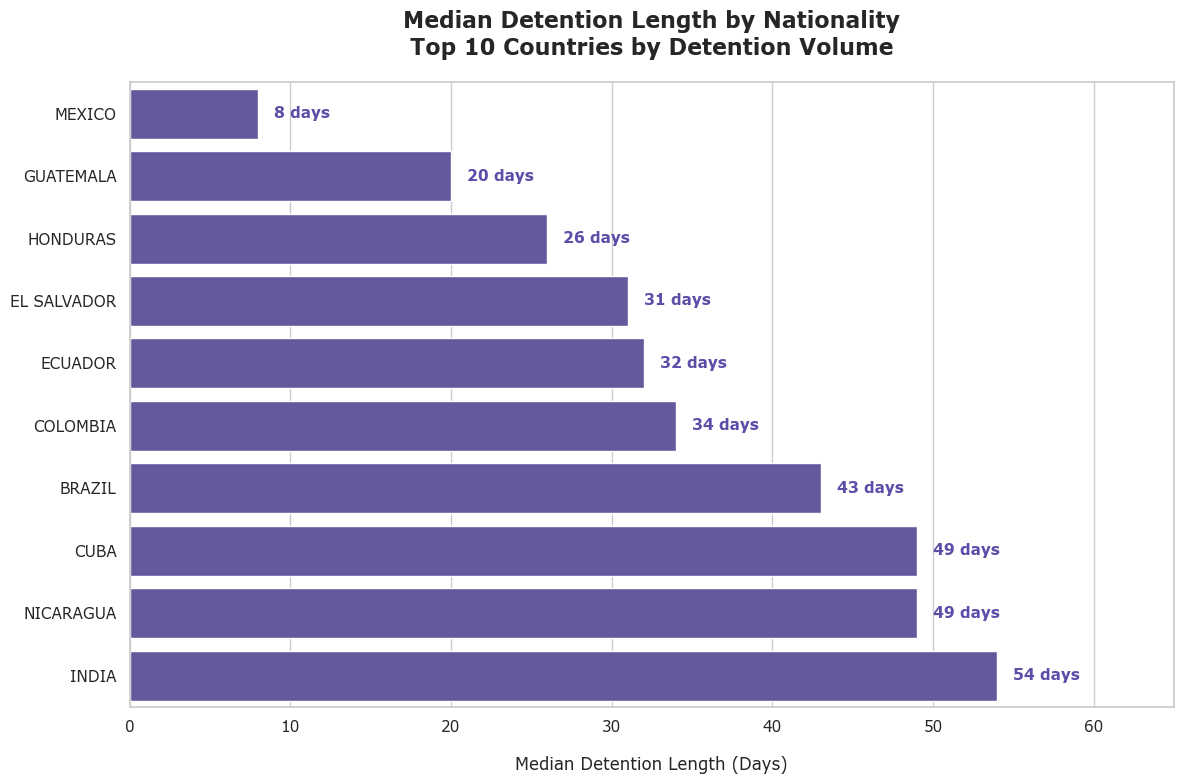

In [65]:
# Median Detention Length by Nationality

# build DataFrame for plotting
country_names: list[str] = ['MEXICO', 'GUATEMALA', 'HONDURAS', 'EL SALVADOR', 'COLOMBIA',
                             'ECUADOR', 'CUBA', 'NICARAGUA', 'INDIA', 'BRAZIL']

country_medians: list[float] = [
    mexico_records['detention_length_days'].median(),
    guatemala_records['detention_length_days'].median(),
    honduras_records['detention_length_days'].median(),
    el_salvador_records['detention_length_days'].median(),
    colombia_records['detention_length_days'].median(),
    ecuador_records['detention_length_days'].median(),
    cuba_records['detention_length_days'].median(),
    nicaragua_records['detention_length_days'].median(),
    india_records['detention_length_days'].median(),
    brazil_records['detention_length_days'].median(),
]

country_detention_df: DataFrame = pd.DataFrame({
    'country': country_names,
    'median_days': country_medians
}).sort_values('median_days', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=country_detention_df,
    x='median_days',
    y='country',
    color='#5B4EA8',
    legend=False,
    ax=ax
)

ax.set_title('Median Detention Length by Nationality\nTop 10 Countries by Detention Volume',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Median Detention Length (Days)', labelpad=15)
ax.set_ylabel('', labelpad=15)
ax.set_xlim(0, 65)

# annotations
mexico_med: float = country_detention_df.loc[country_detention_df['country'] == 'MEXICO', 'median_days'].values[0]
guatemala_med: float = country_detention_df.loc[country_detention_df['country'] == 'GUATEMALA', 'median_days'].values[0]
honduras_med: float = country_detention_df.loc[country_detention_df['country'] == 'HONDURAS', 'median_days'].values[0]
el_salvador_med: float = country_detention_df.loc[country_detention_df['country'] == 'EL SALVADOR', 'median_days'].values[0]
colombia_med: float = country_detention_df.loc[country_detention_df['country'] == 'COLOMBIA', 'median_days'].values[0]
ecuador_med: float = country_detention_df.loc[country_detention_df['country'] == 'ECUADOR', 'median_days'].values[0]
cuba_med: float = country_detention_df.loc[country_detention_df['country'] == 'CUBA', 'median_days'].values[0]
nicaragua_med: float = country_detention_df.loc[country_detention_df['country'] == 'NICARAGUA', 'median_days'].values[0]
india_med: float = country_detention_df.loc[country_detention_df['country'] == 'INDIA', 'median_days'].values[0]
brazil_med: float = country_detention_df.loc[country_detention_df['country'] == 'BRAZIL', 'median_days'].values[0]

# sorted ascending, so position 0 = shortest, position 9 = longest
# we need to find each country's y-position in the sorted order
sorted_countries: list[str] = country_detention_df['country'].tolist()

ax.text(mexico_med + 1, sorted_countries.index('MEXICO'), f'{mexico_med:.0f} days',
        fontsize=11, fontweight='semibold', color='#5B4EA8', va='center')
ax.text(guatemala_med + 1, sorted_countries.index('GUATEMALA'), f'{guatemala_med:.0f} days',
        fontsize=11, fontweight='semibold', color='#5B4EA8', va='center')
ax.text(honduras_med + 1, sorted_countries.index('HONDURAS'), f'{honduras_med:.0f} days',
        fontsize=11, fontweight='semibold', color='#5B4EA8', va='center')
ax.text(el_salvador_med + 1, sorted_countries.index('EL SALVADOR'), f'{el_salvador_med:.0f} days',
        fontsize=11, fontweight='semibold', color='#5B4EA8', va='center')
ax.text(colombia_med + 1, sorted_countries.index('COLOMBIA'), f'{colombia_med:.0f} days',
        fontsize=11, fontweight='semibold', color='#5B4EA8', va='center')
ax.text(ecuador_med + 1, sorted_countries.index('ECUADOR'), f'{ecuador_med:.0f} days',
        fontsize=11, fontweight='semibold', color='#5B4EA8', va='center')
ax.text(cuba_med + 1, sorted_countries.index('CUBA'), f'{cuba_med:.0f} days',
        fontsize=11, fontweight='semibold', color='#5B4EA8', va='center')
ax.text(nicaragua_med + 1, sorted_countries.index('NICARAGUA'), f'{nicaragua_med:.0f} days',
        fontsize=11, fontweight='semibold', color='#5B4EA8', va='center')
ax.text(india_med + 1, sorted_countries.index('INDIA'), f'{india_med:.0f} days',
        fontsize=11, fontweight='semibold', color='#5B4EA8', va='center')
ax.text(brazil_med + 1, sorted_countries.index('BRAZIL'), f'{brazil_med:.0f} days',
        fontsize=11, fontweight='semibold', color='#5B4EA8', va='center')

plt.tight_layout()
plt.show()


#### BAR CHART: CRIMINALITY DISTRIBUTION BY AGE

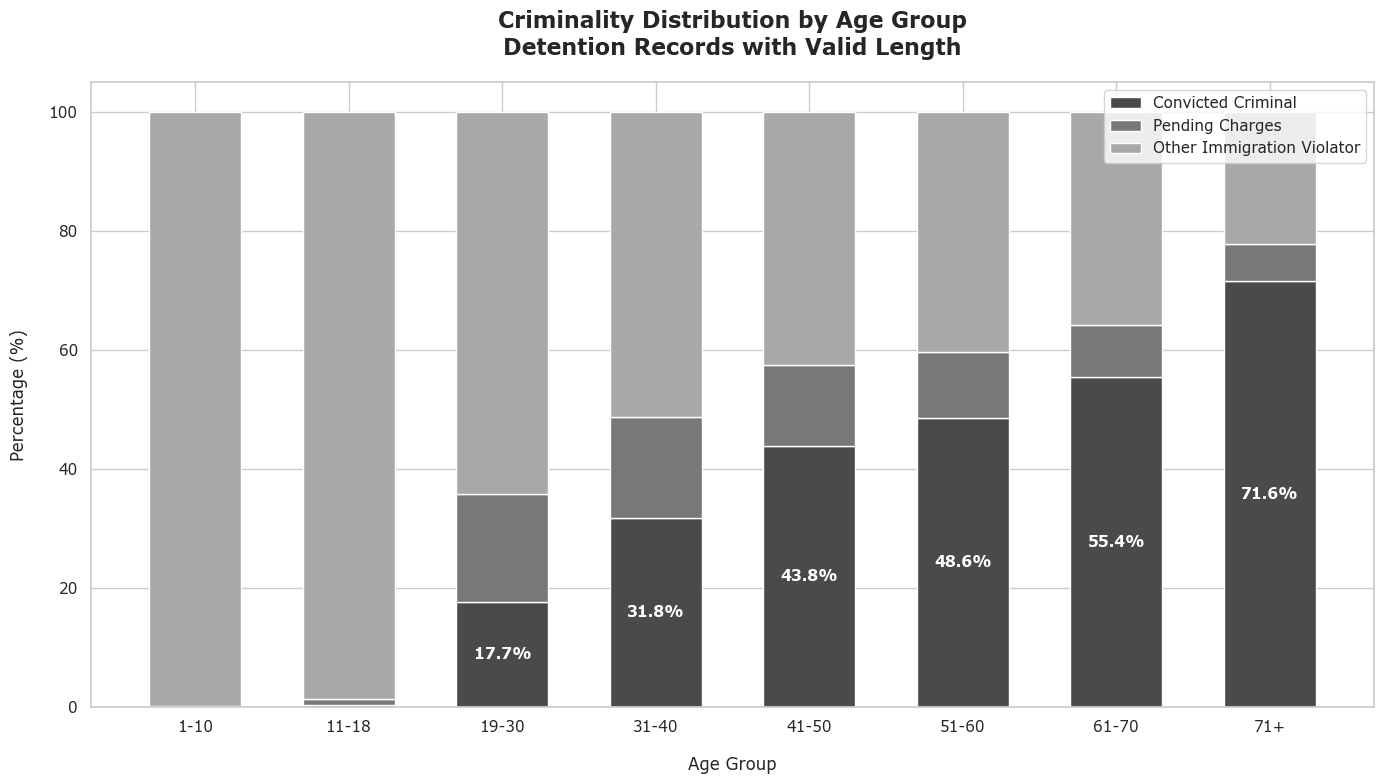

In [103]:
# Criminality Distribution by Age

age_bucket_labels: list[str] = ['1-10', '11-18', '19-30', '31-40', '41-50', '51-60', '61-70', '71+']

convicted_pcts: list[float] = [bucket_1_10_conv, bucket_11_18_conv, bucket_19_30_conv, bucket_31_40_conv,
                                bucket_41_50_conv, bucket_51_60_conv, bucket_61_70_conv, bucket_71_plus_conv]

pending_pcts: list[float] = [bucket_1_10_pend, bucket_11_18_pend, bucket_19_30_pend, bucket_31_40_pend,
                              bucket_41_50_pend, bucket_51_60_pend, bucket_61_70_pend, bucket_71_plus_pend]

immigration_pcts: list[float] = [bucket_1_10_imm, bucket_11_18_imm, bucket_19_30_imm, bucket_31_40_imm,
                                  bucket_41_50_imm, bucket_51_60_imm, bucket_61_70_imm, bucket_71_plus_imm]

fig, ax = plt.subplots(figsize=(14, 8))

x_positions: list[int] = list(range(len(age_bucket_labels)))
bar_width: float = 0.6

# stacked bars — bottom parameter stacks each layer on top of the previous
bars_convicted = ax.bar(x_positions, convicted_pcts, bar_width, label='Convicted Criminal', color='#4A4A4A')
bars_pending = ax.bar(x_positions, pending_pcts, bar_width, bottom=convicted_pcts, label='Pending Charges', color='#787878')

# immigration bottom = convicted + pending
immigration_bottoms: list[float] = [convicted_pcts[i] + pending_pcts[i] for i in range(len(age_bucket_labels))]
bars_immigration = ax.bar(x_positions, immigration_pcts, bar_width, bottom=immigration_bottoms, label='Other Immigration Violator', color='#A8A8A8')

ax.set_title('Criminality Distribution by Age Group\nDetention Records with Valid Length',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Age Group', labelpad=15)
ax.set_ylabel('Percentage (%)', labelpad=15)
ax.set_xticks(x_positions)
ax.set_xticklabels(age_bucket_labels)
ax.set_ylim(0, 105)
ax.legend(loc='upper right')

# convicted % annotation on each bar
ax.text(2, bucket_19_30_conv / 2, f'{bucket_19_30_conv:.1f}%', ha='center', va='center', fontsize=11, fontweight='semibold', color='white')
ax.text(3, bucket_31_40_conv / 2, f'{bucket_31_40_conv:.1f}%', ha='center', va='center', fontsize=11, fontweight='semibold', color='white')
ax.text(4, bucket_41_50_conv / 2, f'{bucket_41_50_conv:.1f}%', ha='center', va='center', fontsize=11, fontweight='semibold', color='white')
ax.text(5, bucket_51_60_conv / 2, f'{bucket_51_60_conv:.1f}%', ha='center', va='center', fontsize=11, fontweight='semibold', color='white')
ax.text(6, bucket_61_70_conv / 2, f'{bucket_61_70_conv:.1f}%', ha='center', va='center', fontsize=11, fontweight='semibold', color='white')
ax.text(7, bucket_71_plus_conv / 2, f'{bucket_71_plus_conv:.1f}%', ha='center', va='center', fontsize=11, fontweight='semibold', color='white')

plt.tight_layout()
plt.show()


#### BAR CHART: STATE VS CRIMINALITY PRE-POST ADMINISTRATION CHANGE

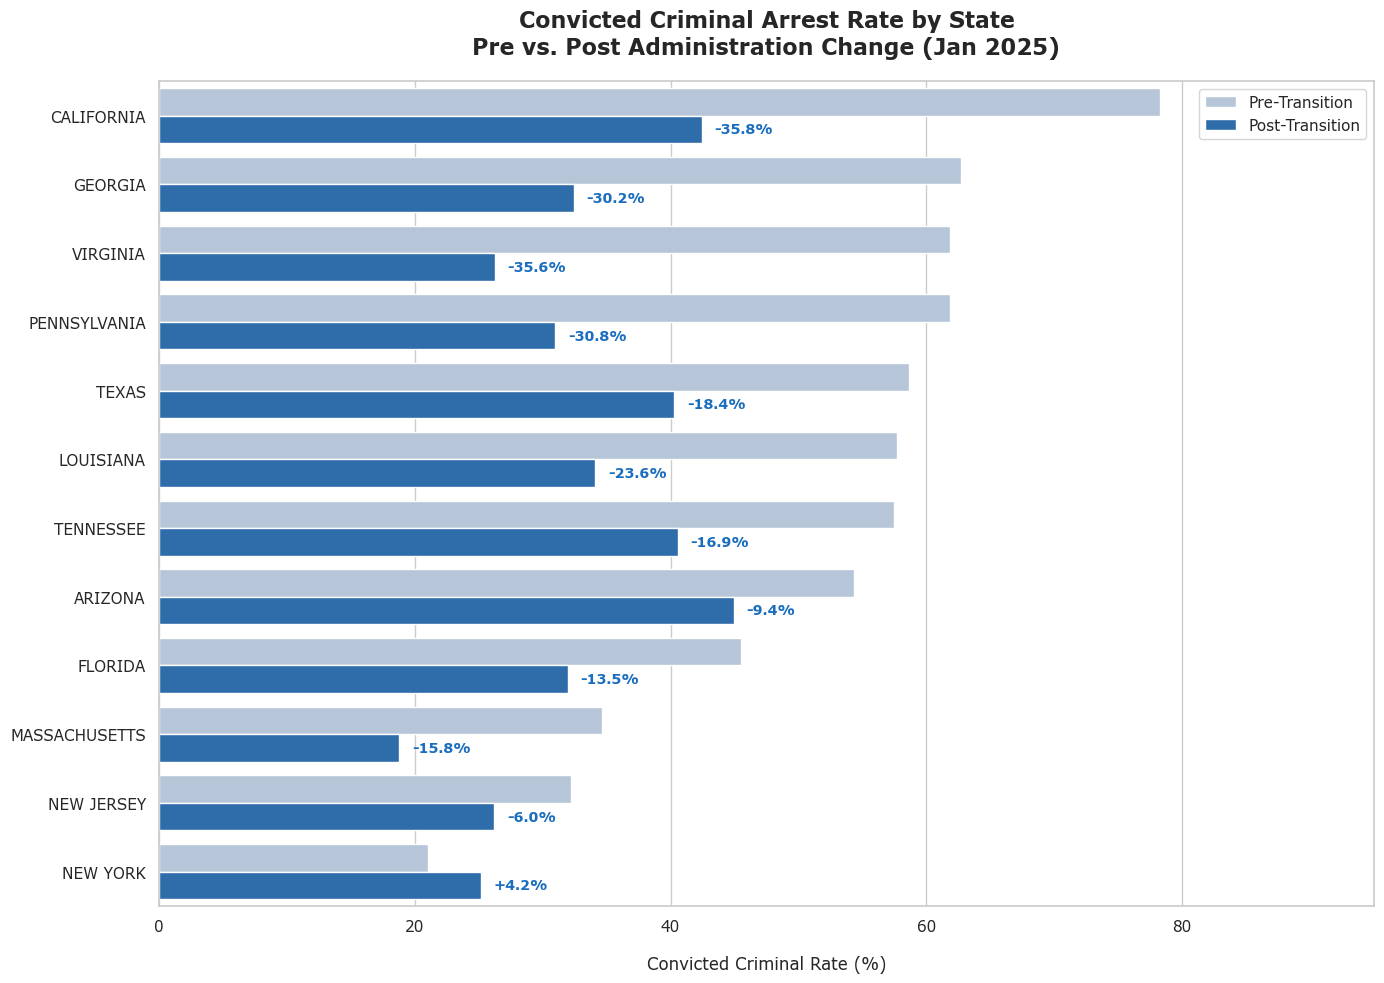

In [98]:
# Convicted Criminal Rate by State — Pre-Post

state_names: list[str] = ['TEXAS', 'FLORIDA', 'CALIFORNIA', 'NEW YORK', 'GEORGIA',
                           'NEW JERSEY', 'TENNESSEE', 'VIRGINIA', 'ARIZONA',
                           'LOUISIANA', 'PENNSYLVANIA', 'MASSACHUSETTS']

state_pre_rates: list[float] = [tx_pre_conv, fl_pre_conv, ca_pre_conv, ny_pre_conv, ga_pre_conv,
                                 nj_pre_conv, tn_pre_conv, va_pre_conv, az_pre_conv,
                                 la_pre_conv, pa_pre_conv, ma_pre_conv]

state_post_rates: list[float] = [tx_post_conv, fl_post_conv, ca_post_conv, ny_post_conv, ga_post_conv,
                                  nj_post_conv, tn_post_conv, va_post_conv, az_post_conv,
                                  la_post_conv, pa_post_conv, ma_post_conv]

state_changes: list[float] = [state_post_rates[i] - state_pre_rates[i] for i in range(len(state_names))]

# build DataFrame for grouped bar chart
state_pre_df: DataFrame = pd.DataFrame({
    'state': state_names,
    'convicted_rate': state_pre_rates,
    'Period': 'Pre-Transition'
})

state_post_df: DataFrame = pd.DataFrame({
    'state': state_names,
    'convicted_rate': state_post_rates,
    'Period': 'Post-Transition'
})

state_chart_data: DataFrame = pd.concat([state_pre_df, state_post_df])

# sort by pre-transition rate descending for visual impact
state_sort_order: list[str] = [x for _, x in sorted(zip(state_pre_rates, state_names), reverse=True)]

fig, ax = plt.subplots(figsize=(14, 10))

sns.barplot(
    data=state_chart_data,
    x='convicted_rate',
    y='state',
    hue='Period',
    hue_order=['Pre-Transition', 'Post-Transition'],
    order=state_sort_order,
    palette=['#B0C4DE', '#1A6EBD'],
    ax=ax
)

ax.set_title('Convicted Criminal Arrest Rate by State\nPre vs. Post Administration Change (Jan 2025)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Convicted Criminal Rate (%)', labelpad=15)
ax.set_ylabel('', labelpad=15)
ax.set_xlim(0, 95)
ax.legend(title='')

# percentage change annotations — position at the end of post-transition bar
ax.text(ca_post_conv + 1, state_sort_order.index('CALIFORNIA') + 0.2, f'{ca_post_conv - ca_pre_conv:+.1f}%',
        fontsize=10, fontweight='semibold', color='#1A6EBD', va='center')
ax.text(ga_post_conv + 1, state_sort_order.index('GEORGIA') + 0.2, f'{ga_post_conv - ga_pre_conv:+.1f}%',
        fontsize=10, fontweight='semibold', color='#1A6EBD', va='center')
ax.text(va_post_conv + 1, state_sort_order.index('VIRGINIA') + 0.2, f'{va_post_conv - va_pre_conv:+.1f}%',
        fontsize=10, fontweight='semibold', color='#1A6EBD', va='center')
ax.text(pa_post_conv + 1, state_sort_order.index('PENNSYLVANIA') + 0.2, f'{pa_post_conv - pa_pre_conv:+.1f}%',
        fontsize=10, fontweight='semibold', color='#1A6EBD', va='center')
ax.text(tx_post_conv + 1, state_sort_order.index('TEXAS') + 0.2, f'{tx_post_conv - tx_pre_conv:+.1f}%',
        fontsize=10, fontweight='semibold', color='#1A6EBD', va='center')
ax.text(tn_post_conv + 1, state_sort_order.index('TENNESSEE') + 0.2, f'{tn_post_conv - tn_pre_conv:+.1f}%',
        fontsize=10, fontweight='semibold', color='#1A6EBD', va='center')
ax.text(la_post_conv + 1, state_sort_order.index('LOUISIANA') + 0.2, f'{la_post_conv - la_pre_conv:+.1f}%',
        fontsize=10, fontweight='semibold', color='#1A6EBD', va='center')
ax.text(az_post_conv + 1, state_sort_order.index('ARIZONA') + 0.2, f'{az_post_conv - az_pre_conv:+.1f}%',
        fontsize=10, fontweight='semibold', color='#1A6EBD', va='center')
ax.text(fl_post_conv + 1, state_sort_order.index('FLORIDA') + 0.2, f'{fl_post_conv - fl_pre_conv:+.1f}%',
        fontsize=10, fontweight='semibold', color='#1A6EBD', va='center')
ax.text(ma_post_conv + 1, state_sort_order.index('MASSACHUSETTS') + 0.2, f'{ma_post_conv - ma_pre_conv:+.1f}%',
        fontsize=10, fontweight='semibold', color='#1A6EBD', va='center')
ax.text(nj_post_conv + 1, state_sort_order.index('NEW JERSEY') + 0.2, f'{nj_post_conv - nj_pre_conv:+.1f}%',
        fontsize=10, fontweight='semibold', color='#1A6EBD', va='center')
ax.text(ny_post_conv + 1, state_sort_order.index('NEW YORK') + 0.2, f'{ny_post_conv - ny_pre_conv:+.1f}%',
        fontsize=10, fontweight='semibold', color='#1A6EBD', va='center')

plt.tight_layout()
plt.show()
